In [1]:
# CELL 0 — Setup (paths, imports, global rules)
# You said:
# - BASE_DIR = D:\base
# - CSV and JSON are inside BASE_DIR
# - Images are in BASE_DIR\Data and CSV LINK looks like "Data\NAME.jpeg"
# - Images are 256x256
# - Start new notebook from cell 0

from pathlib import Path
import os
import re
import json
import math
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Base paths (DO NOT CHANGE unless your local layout changes) ---
BASE_DIR = Path(r"D:\base")
CSV_PATH = BASE_DIR / "dmsa_dataset.csv"
JSON_PATH = BASE_DIR / "dmsa.json"

# --- Image constants ---
IMG_SIZE = 256

# ROI mask (your margin-30 rule): keep center area, zero outside.
ROI_X0, ROI_Y0 = 30, 30
ROI_X1, ROI_Y1 = 226, 226  # end-exclusive

# Locked tick-only ruler ROI (kept here for later; NOT used yet in this preprocessing cell)
RULER_X0, RULER_X1 = 240, 253
RULER_Y0, RULER_Y1 = 106, 152

print("BASE_DIR:", BASE_DIR)
print("CSV_PATH:", CSV_PATH)
print("JSON_PATH:", JSON_PATH)
print("IMG_SIZE:", IMG_SIZE)


BASE_DIR: D:\base
CSV_PATH: D:\base\dmsa_dataset.csv
JSON_PATH: D:\base\dmsa.json
IMG_SIZE: 256


In [2]:
# CELL 1 — Robust column resolver + load CSV (NO column-name guessing)
def _norm_colname(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).strip().lower())

def require_col(df: pd.DataFrame, wanted: str) -> str:
    """
    Find an exact column by normalized name.
    Example: wanted="LINK" matches "LINK" / "Link" / " link " etc.
    """
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    # If not found, print columns for you and raise a clear error
    print("ERROR: Required column not found:", wanted)
    print("Available columns:")
    for c in df.columns:
        print(" -", repr(c))
    raise KeyError(f"Required column '{wanted}' not found. Fix the CSV header or update wanted='{wanted}'.")

# Load CSV
df = pd.read_csv(CSV_PATH)

COL_LINK = require_col(df, "LINK")
# VIEW is useful for later; still resolve now to avoid assumptions.
COL_VIEW = require_col(df, "VIEW")

print("Loaded CSV:", df.shape)
print("Resolved columns:")
print("  COL_LINK =", repr(COL_LINK))
print("  COL_VIEW =", repr(COL_VIEW))

# Show first few rows of LINK/VIEW
df[[COL_LINK, COL_VIEW]].head(10)


Loaded CSV: (2294, 23)
Resolved columns:
  COL_LINK = 'LINK'
  COL_VIEW = 'VIEW'


,LINK,VIEW
0,Data\A_RAHMAN_6_MONTHS.jpeg,P
1,Data\A_RAHMAN_6_MONTHS_1.jpeg,LPO
2,Data\A_RAHMAN_6_MONTHS_2.jpeg,RPO
3,Data\ABDUL_ALIM_1_MONTHS.jpeg,P
4,Data\ABDUL_ALIM_1_MONTHS_1.jpeg,LPO
5,Data\ABDUL_ALIM_1_MONTHS_2.jpeg,RPO
6,Data\ABDUL_BATIN_63_YRS.jpeg,P
7,Data\ABDUL_BATIN_63_YRS_1.jpeg,LPO
8,Data\ABDUL_BATIN_63_YRS_2.jpeg,RPO
9,Data\ABDUL_MOTALIB_7_YRS.jpeg,P


In [3]:
# CELL 2 — Build absolute image paths + quick file existence proof (with progress bar)
def rel_to_abs_path(rel_path: str, base_dir: Path) -> Path:
    # Handle either slash style safely
    rel_path = str(rel_path)
    rel_path = rel_path.replace("/", os.sep).replace("\\", os.sep)
    return base_dir / rel_path

# Create absolute path column (no mutation of original LINK)
abs_paths = []
missing = 0

for p in tqdm(df[COL_LINK].astype(str).tolist(), desc="Resolving paths"):
    ap = rel_to_abs_path(p, BASE_DIR)
    abs_paths.append(ap)
    if not ap.exists():
        missing += 1

df["__ABS_PATH__"] = abs_paths

print("Total rows:", len(df))
print("Missing files:", missing)
print("Example absolute paths:")
for i in range(5):
    print(" ", df["__ABS_PATH__"].iloc[i])

# If there are missing files, show a few examples
if missing > 0:
    print("\nSome missing examples:")
    shown = 0
    for i in range(len(df)):
        if not df["__ABS_PATH__"].iloc[i].exists():
            print(" ", df[COL_LINK].iloc[i], "->", df["__ABS_PATH__"].iloc[i])
            shown += 1
            if shown >= 8:
                break


Resolving paths:   0%|          | 0/2294 [00:00<?, ?it/s]

Total rows: 2294
Missing files: 0
Example absolute paths:
  D:\base\Data\A_RAHMAN_6_MONTHS.jpeg
  D:\base\Data\A_RAHMAN_6_MONTHS_1.jpeg
  D:\base\Data\A_RAHMAN_6_MONTHS_2.jpeg
  D:\base\Data\ABDUL_ALIM_1_MONTHS.jpeg
  D:\base\Data\ABDUL_ALIM_1_MONTHS_1.jpeg


In [4]:
# CELL 3 — Patient group key from filename (your rule: strip trailing _1/_2/_3... only)
# Examples:
#   ABDULLAH_2YRS.jpeg        -> base = ABDULLAH_2YRS
#   ABDULLAH_2YRS_1.jpeg      -> base = ABDULLAH_2YRS
#   ABDULLAH_4_YRS_05_MONTHS.jpeg   -> base = ABDULLAH_4_YRS_05_MONTHS
#   ABDULLAH_4_YRS_5_MONTHS.jpeg    -> base = ABDULLAH_4_YRS_5_MONTHS  (DIFFERENT case)

def patient_base_from_link(link_value: str) -> str:
    # take filename only, without folders
    fname = os.path.basename(str(link_value).replace("/", os.sep).replace("\\", os.sep))
    # remove extension
    stem, _ext = os.path.splitext(fname)

    # strip ONLY a trailing "_<digits>" if present
    m = re.match(r"^(.*?)(?:_(\d+))?$", stem)
    if not m:
        return stem
    core = m.group(1)
    idx = m.group(2)
    if idx is None:
        return stem
    return core

df["__PATIENT_BASE__"] = [patient_base_from_link(x) for x in df[COL_LINK].astype(str).tolist()]

print("Patient-base examples:")
for i in range(12):
    print(df[COL_LINK].iloc[i], "->", df["__PATIENT_BASE__"].iloc[i])

print("\nUnique patient-base count:", df["__PATIENT_BASE__"].nunique())

# Show distribution of number of views per patient-base (quick sanity)
counts = df["__PATIENT_BASE__"].value_counts()
print("\nViews per patient-base (top 10 most):")
counts.head(10)


Patient-base examples:
Data\A_RAHMAN_6_MONTHS.jpeg -> A_RAHMAN_6_MONTHS
Data\A_RAHMAN_6_MONTHS_1.jpeg -> A_RAHMAN_6_MONTHS
Data\A_RAHMAN_6_MONTHS_2.jpeg -> A_RAHMAN_6_MONTHS
Data\ABDUL_ALIM_1_MONTHS.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_ALIM_1_MONTHS_1.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_ALIM_1_MONTHS_2.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_BATIN_63_YRS.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_BATIN_63_YRS_1.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_BATIN_63_YRS_2.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_MOTALIB_7_YRS.jpeg -> ABDUL_MOTALIB_7_YRS
Data\ABDUL_MOTALIB_7_YRS_1.jpeg -> ABDUL_MOTALIB_7_YRS
Data\ABDUL_MOTALIB_7_YRS_2.jpeg -> ABDUL_MOTALIB_7_YRS

Unique patient-base count: 759

Views per patient-base (top 10 most):


__PATIENT_BASE__
TAWHID_2_YRS              6
SIAM_11_YRS               6
SADD_4_YRS                5
SABID_8_YRS               4
SAMIA_TASNIM_SAFA_5YRS    4
ABDUR_RAHMAN_1YRS         4
RAHAT_6_YRS               4
SIAM_17_YRS               4
JISHAN_33_MONTHS          4
ABDUR_RAHMAN_42_MONTHS    4
Name: count, dtype: int64

In [5]:
# CELL 4 — Load VIA-style JSON masks (dmsa.json) + mask rasterizer (NO assumptions)
# Your dmsa.json is VIA format:
# top-level dict keyed by filename (e.g., "SARIBA_8YRS.jpeg")
# each entry contains "regions" dict, each region has:
#   shape_attributes: polygon with all_points_x/all_points_y
#   region_attributes: {label: "left"/"right"}

from PIL import Image, ImageDraw

with open(JSON_PATH, "r", encoding="utf-8") as f:
    via = json.load(f)

print("Loaded dmsa.json entries:", len(via))

def _poly_to_mask(all_points_x, all_points_y, h=IMG_SIZE, w=IMG_SIZE):
    # Convert float coords to int pixel coords safely
    pts = []
    for x, y in zip(all_points_x, all_points_y):
        xi = int(round(float(x)))
        yi = int(round(float(y)))
        xi = max(0, min(w - 1, xi))
        yi = max(0, min(h - 1, yi))
        pts.append((xi, yi))

    m = Image.new("L", (w, h), 0)
    if len(pts) >= 3:
        ImageDraw.Draw(m).polygon(pts, outline=1, fill=1)
    return np.array(m, dtype=np.uint8)

def load_masks_for_link(link_value: str):
    """
    Returns ML, MR uint8 masks in {0,1} with shape [256,256].
    Matching uses basename of LINK, because VIA keys are basenames.
    """
    fname = os.path.basename(str(link_value).replace("/", os.sep).replace("\\", os.sep))
    if fname not in via:
        # No mask found
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8), np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    entry = via[fname]
    regions = entry.get("regions", {})
    # VIA sometimes stores regions as dict; handle both.
    if isinstance(regions, list):
        region_iter = regions
    elif isinstance(regions, dict):
        region_iter = regions.values()
    else:
        region_iter = []

    ML = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    MR = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    for reg in region_iter:
        sa = reg.get("shape_attributes", {})
        ra = reg.get("region_attributes", {})
        label = str(ra.get("label", "")).strip().lower()

        if sa.get("name", "").lower() != "polygon":
            continue
        xs = sa.get("all_points_x", None)
        ys = sa.get("all_points_y", None)
        if xs is None or ys is None or len(xs) != len(ys):
            continue

        m = _poly_to_mask(xs, ys, h=IMG_SIZE, w=IMG_SIZE)
        if label == "left":
            ML = np.maximum(ML, m)
        elif label == "right":
            MR = np.maximum(MR, m)

    return ML, MR

# Quick proof on 5 random rows: show if mask exists and ranges of coords (via entry-level check)
sample_idxs = random.sample(range(len(df)), k=5)
for i in sample_idxs:
    link = df[COL_LINK].iloc[i]
    fname = os.path.basename(str(link).replace("/", os.sep).replace("\\", os.sep))
    ML, MR = load_masks_for_link(link)
    print(f"[{i}] {fname} | ML_sum={ML.sum()} MR_sum={MR.sum()} | has_json={fname in via}")


Loaded dmsa.json entries: 2294
[1689] SADMAN_2_MONTH.jpeg | ML_sum=609 MR_sum=527 | has_json=True
[2106] TAREK_12_YRS_1.jpeg | ML_sum=0 MR_sum=422 | has_json=True
[487] AZMIR_HOSSAIN_6_YRS_1.jpeg | ML_sum=656 MR_sum=618 | has_json=True
[781] HUMAIRA_30_MONTH_1.jpeg | ML_sum=445 MR_sum=289 | has_json=True
[498] BABY_ARAFAT_2_MONTHS.jpeg | ML_sum=500 MR_sum=0 | has_json=True


In [6]:
# CELL 5 — Preprocessing functions (ROI mask + intensity clipping + gentle denoise + CLAHE)
# NOTE:
# - We keep RAW image untouched (for ruler later).
# - MODEL image is processed.
# - Intensity clipping is NOT spatial cropping.

# Optional CLAHE backends (no crash):
_HAS_CV2 = False
_HAS_SKIMAGE = False

try:
    import cv2
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False

try:
    from skimage import exposure
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

print("CLAHE backend available -> cv2:", _HAS_CV2, "| skimage:", _HAS_SKIMAGE)

ROI_U8 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
ROI_U8[ROI_Y0:ROI_Y1, ROI_X0:ROI_X1] = 1
ROI_F = ROI_U8.astype(np.float32)

def load_gray_256(path: Path) -> np.ndarray:
    # Load as grayscale float32 in [0,1], ensure 256x256.
    img = Image.open(path).convert("L")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def intensity_clip_norm(I: np.ndarray, mask: np.ndarray = None, p_lo=1.0, p_hi=99.0) -> np.ndarray:
    """
    Clip to percentiles then rescale to [0,1].
    mask: optional boolean/0-1 mask defining where percentiles are computed.
    """
    X = I
    if mask is not None:
        m = mask.astype(bool)
        vals = X[m]
        if vals.size < 32:
            vals = X.reshape(-1)
    else:
        vals = X.reshape(-1)

    lo = np.percentile(vals, p_lo)
    hi = np.percentile(vals, p_hi)
    if hi <= lo + 1e-6:
        return np.clip(X, 0.0, 1.0)

    Y = np.clip(X, lo, hi)
    Y = (Y - lo) / (hi - lo)
    return np.clip(Y, 0.0, 1.0)

def gentle_denoise(I: np.ndarray) -> np.ndarray:
    """
    Very mild denoise to avoid destroying scar patterns.
    Uses cv2 if available, else a tiny manual blur.
    """
    if _HAS_CV2:
        # GaussianBlur expects float32 OK
        return cv2.GaussianBlur(I.astype(np.float32), (3, 3), sigmaX=0.5)
    # fallback: tiny 3x3 average blur
    K = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32) / 9.0
    P = np.pad(I, ((1,1),(1,1)), mode="edge")
    out = np.zeros_like(I, dtype=np.float32)
    for y in range(IMG_SIZE):
        for x in range(IMG_SIZE):
            out[y,x] = np.sum(P[y:y+3, x:x+3] * K)
    return out

def apply_clahe(I: np.ndarray, clip_limit=2.0, tile_grid_size=(8,8)) -> np.ndarray:
    """
    Apply CLAHE to a normalized [0,1] image.
    """
    if _HAS_CV2:
        u8 = (np.clip(I, 0, 1) * 255.0).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=float(clip_limit), tileGridSize=tile_grid_size)
        out = clahe.apply(u8).astype(np.float32) / 255.0
        return np.clip(out, 0.0, 1.0)

    if _HAS_SKIMAGE:
        out = exposure.equalize_adapthist(np.clip(I,0,1), clip_limit=0.01)  # skimage uses different scaling
        return np.clip(out.astype(np.float32), 0.0, 1.0)

    # final fallback: no CLAHE (still runs)
    return I.astype(np.float32)

def preprocess_for_model(I_raw: np.ndarray, ML: np.ndarray = None, MR: np.ndarray = None,
                         p_lo=1.0, p_hi=99.0, do_clahe=True):
    """
    Returns:
      I_roi: ROI-masked raw
      I_clip: clipped+normalized
      I_dnz: denoised
      I_clahe: CLAHE-applied
      I_L, I_R: masked left/right (using CLAHE image)
    """
    # ROI mask (spatial)
    I_roi = I_raw * ROI_F

    # For percentile stats, use ROI mask OR ROI∩(ML|MR) if masks exist.
    if ML is not None and MR is not None:
        mk = ((ML > 0) | (MR > 0)).astype(np.uint8)
        stat_mask = (mk * ROI_U8).astype(bool)
        if stat_mask.sum() < 32:
            stat_mask = ROI_U8.astype(bool)
    else:
        stat_mask = ROI_U8.astype(bool)

    I_clip = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)
    I_dnz  = gentle_denoise(I_clip)

    I_clahe = apply_clahe(I_dnz) if do_clahe else I_dnz
    I_clahe = np.clip(I_clahe, 0.0, 1.0).astype(np.float32)

    # masked side images
    if ML is None:
        ML = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if MR is None:
        MR = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    I_L = I_clahe * (ML.astype(np.float32))
    I_R = I_clahe * (MR.astype(np.float32))

    return I_roi, I_clip, I_dnz, I_clahe, I_L, I_R


CLAHE backend available -> cv2: True | skimage: True


Visualization picks: [67, 214, 151]


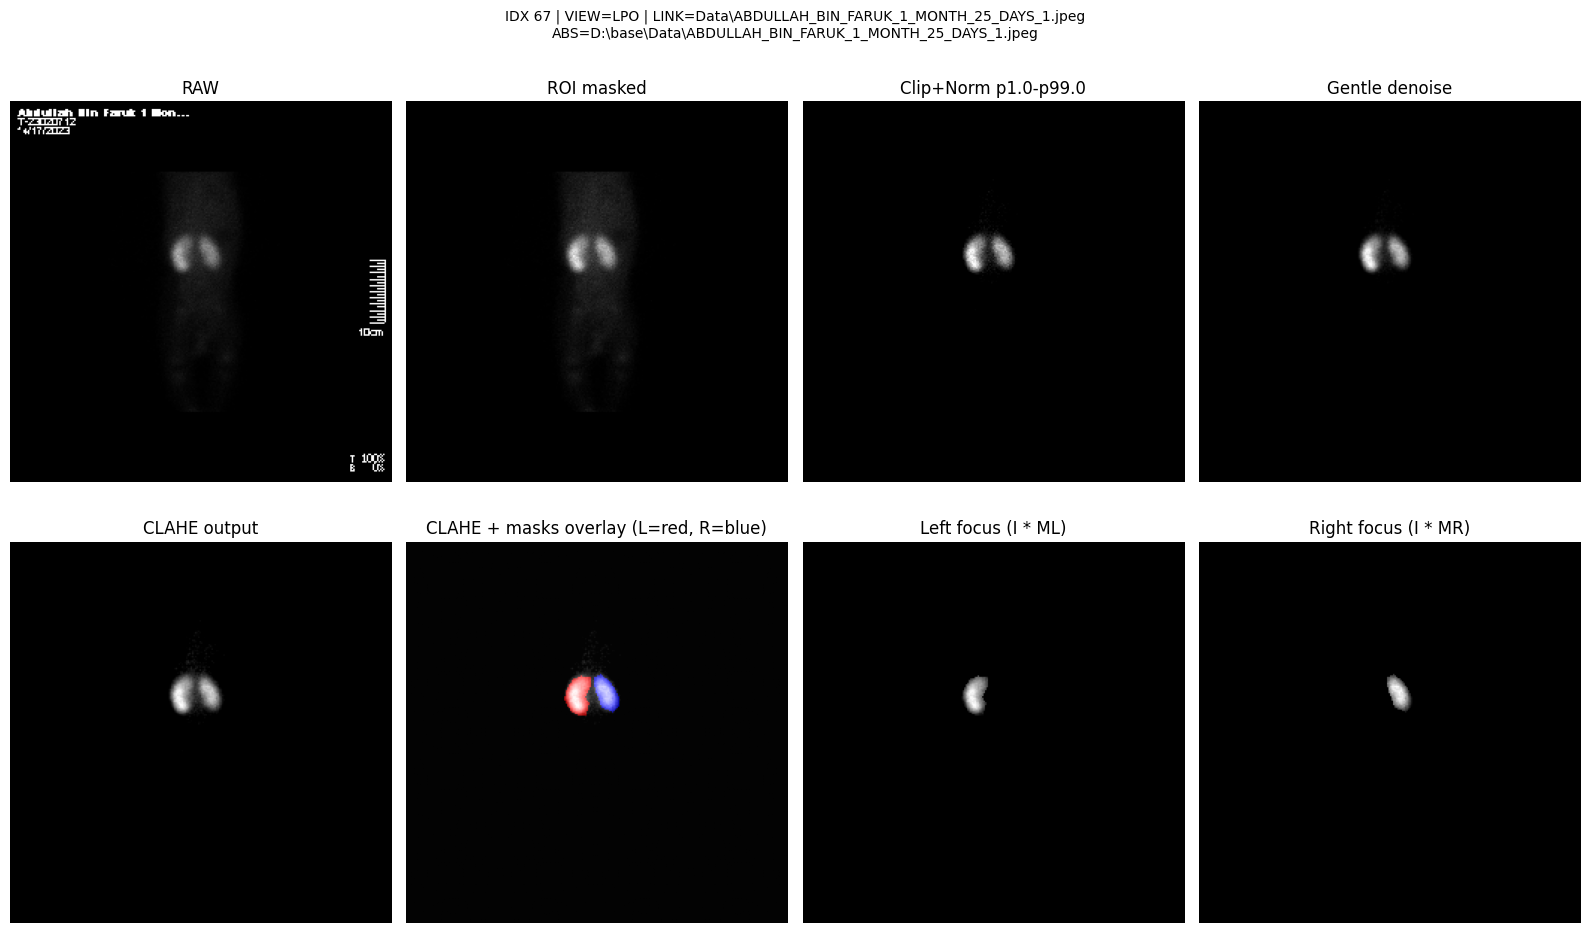

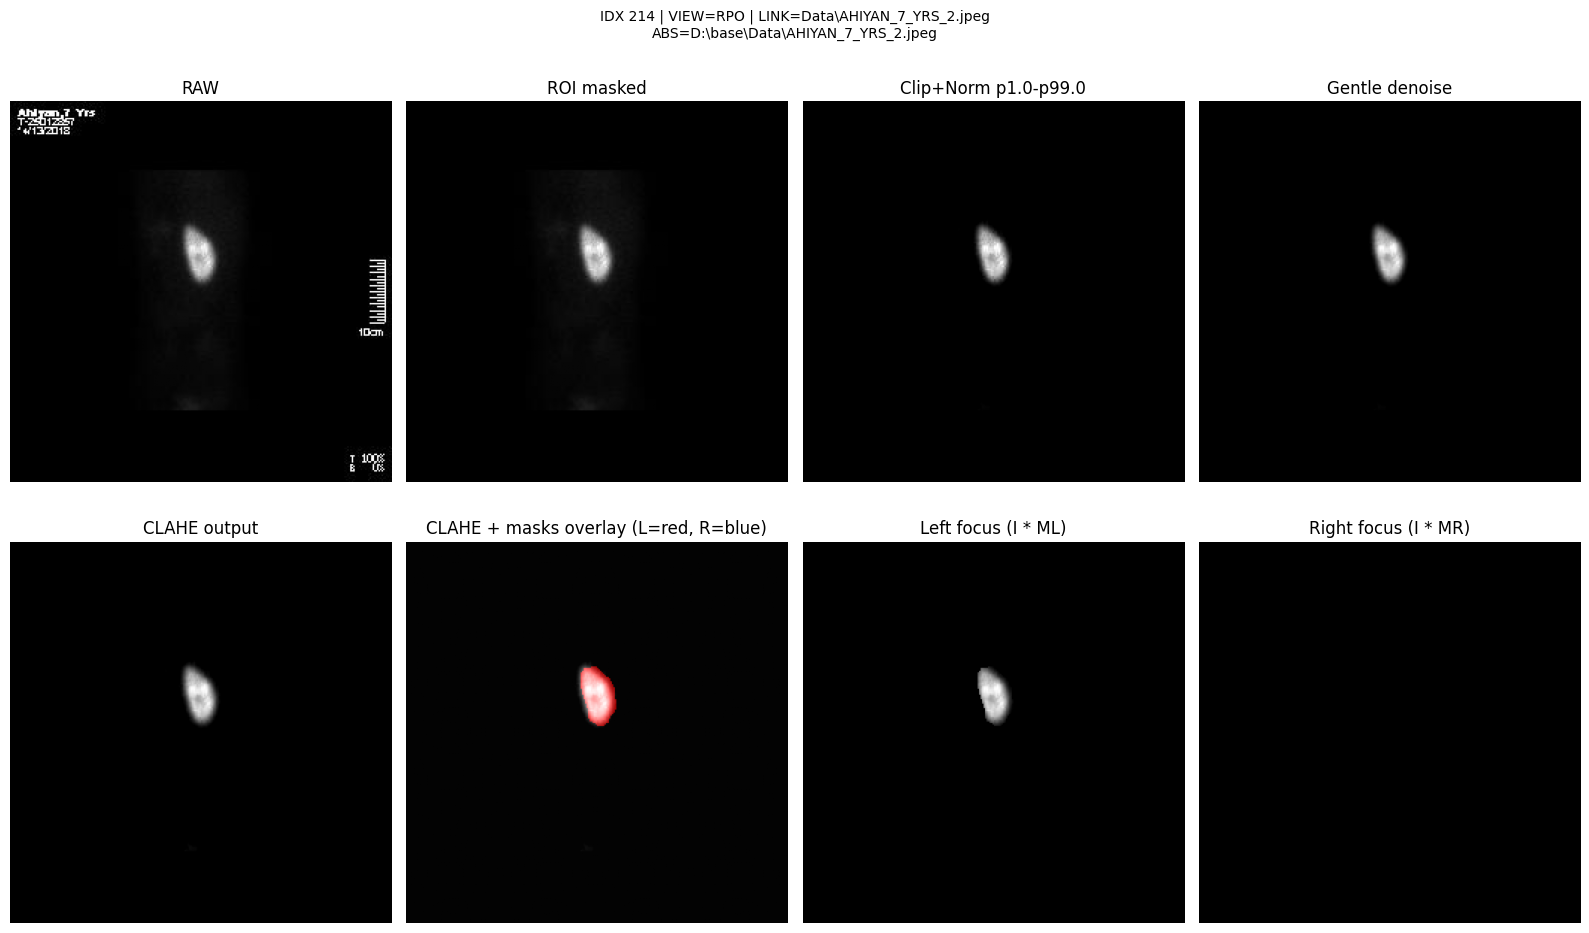

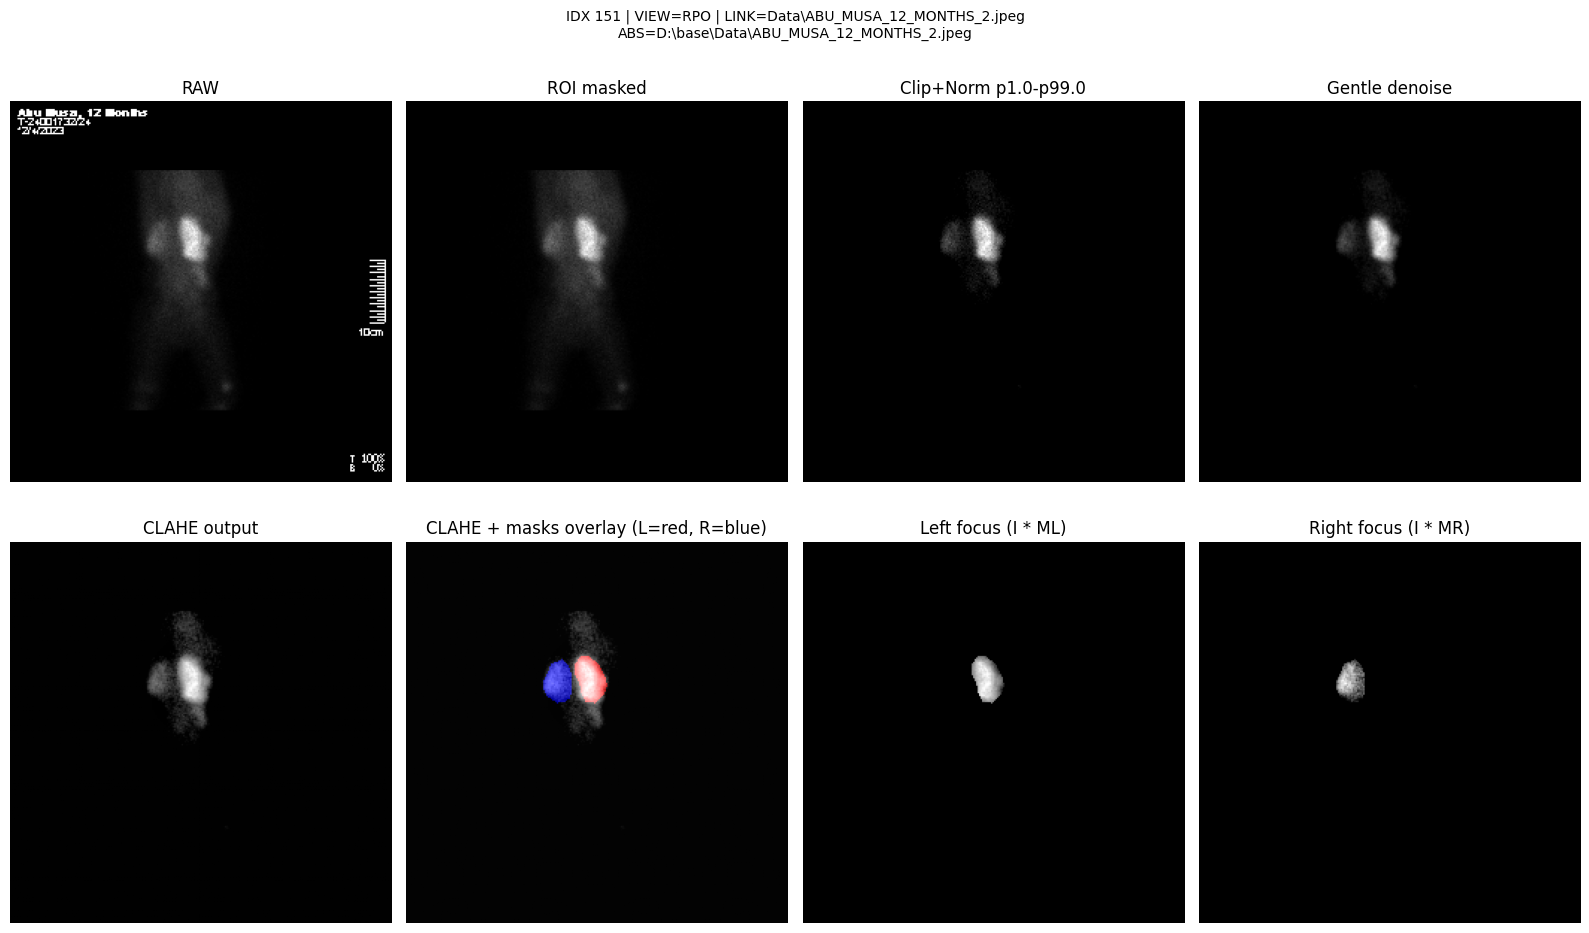

In [7]:
# CELL 6 — Visual proof: before/after preprocessing + masks (side-by-side)
def show_preprocess(idx: int, p_lo=1.0, p_hi=99.0, do_clahe=True):
    row = df.iloc[idx]
    abs_path: Path = row["__ABS_PATH__"]
    link = row[COL_LINK]
    view = row[COL_VIEW]

    if not abs_path.exists():
        print("ERROR: File missing:", abs_path)
        return

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)
    I_roi, I_clip, I_dnz, I_clahe, I_L, I_R = preprocess_for_model(I_raw, ML, MR, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe)

    # overlays for proof
    overlay = np.dstack([I_clahe, I_clahe, I_clahe])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)  # red tint for left
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)  # blue tint for right

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"IDX {idx} | VIEW={view} | LINK={link}\nABS={abs_path}", fontsize=10)

    ax = plt.subplot(2,4,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW"); ax.axis("off")
    ax = plt.subplot(2,4,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,4,3); ax.imshow(I_clip, cmap="gray"); ax.set_title(f"Clip+Norm p{p_lo}-p{p_hi}"); ax.axis("off")
    ax = plt.subplot(2,4,4); ax.imshow(I_dnz, cmap="gray"); ax.set_title("Gentle denoise"); ax.axis("off")

    ax = plt.subplot(2,4,5); ax.imshow(I_clahe, cmap="gray"); ax.set_title("CLAHE output"); ax.axis("off")
    ax = plt.subplot(2,4,6); ax.imshow(overlay); ax.set_title("CLAHE + masks overlay (L=red, R=blue)"); ax.axis("off")
    ax = plt.subplot(2,4,7); ax.imshow(I_L, cmap="gray"); ax.set_title("Left focus (I * ML)"); ax.axis("off")
    ax = plt.subplot(2,4,8); ax.imshow(I_R, cmap="gray"); ax.set_title("Right focus (I * MR)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# Pick 3 random samples with masks (if possible), else any samples
mask_nonzero = np.where([(load_masks_for_link(df[COL_LINK].iloc[i])[0].sum() +
                          load_masks_for_link(df[COL_LINK].iloc[i])[1].sum()) > 0
                         for i in range(min(300, len(df)))])[0]

if len(mask_nonzero) > 0:
    picks = random.sample(mask_nonzero.tolist(), k=min(3, len(mask_nonzero)))
else:
    picks = random.sample(range(len(df)), k=3)

print("Visualization picks:", picks)
for idx in picks:
    show_preprocess(idx)


In [8]:
# CELL 7 — Multi-view grouping sanity (proof we group *_1, *_2, *_3... together)
# We do NOT normalize underscores/spaces; we only strip trailing _<digits>.
# This respects your "05" vs "5" being different cases.

# Build grouped indices for a few patient-bases
gb = df.groupby("__PATIENT_BASE__").indices

# Show 5 random patient-bases and their LINK list
some_keys = random.sample(list(gb.keys()), k=5)
for k in some_keys:
    idxs = gb[k]
    links = df.loc[idxs, COL_LINK].tolist()
    print("\nPATIENT_BASE:", k, "| n_views=", len(links))
    for L in links[:10]:
        print(" ", L)



PATIENT_BASE: NAZIMUDDIN_11_YRS | n_views= 3
  Data\NAZIMUDDIN_11_YRS.jpeg
  Data\NAZIMUDDIN_11_YRS_1.jpeg
  Data\NAZIMUDDIN_11_YRS_2.jpeg

PATIENT_BASE: RAIDUL_11_MONTHS | n_views= 3
  Data\RAIDUL_11_MONTHS.jpeg
  Data\RAIDUL_11_MONTHS_1.jpeg
  Data\RAIDUL_11_MONTHS_2.jpeg

PATIENT_BASE: SANJIDA_40_DAYS | n_views= 3
  Data\SANJIDA_40_DAYS.jpeg
  Data\SANJIDA_40_DAYS_1.jpeg
  Data\SANJIDA_40_DAYS_2.jpeg

PATIENT_BASE: NAHID_11_YRS | n_views= 3
  Data\NAHID_11_YRS.jpeg
  Data\NAHID_11_YRS_1.jpeg
  Data\NAHID_11_YRS_2.jpeg

PATIENT_BASE: BIAZID_BOSTAMY_19MONTH | n_views= 3
  Data\BIAZID_BOSTAMY_19MONTH.jpeg
  Data\BIAZID_BOSTAMY_19MONTH_1.jpeg
  Data\BIAZID_BOSTAMY_19MONTH_2.jpeg


In [9]:
# CELL 8 — Re-resolve columns safely (NO assumptions) + reload CSV (robust)
# Why: earlier we required VIEW. If your CSV ever changes, this cell keeps us safe.

def require_col(df: pd.DataFrame, wanted: str) -> str:
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    print("ERROR: Required column not found:", wanted)
    print("Available columns:")
    for c in df.columns:
        print(" -", repr(c))
    raise KeyError(f"Required column '{wanted}' not found.")

def optional_col(df: pd.DataFrame, wanted: str):
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    return None

df = pd.read_csv(CSV_PATH)

COL_LINK = require_col(df, "LINK")
COL_VIEW = optional_col(df, "VIEW")  # optional on purpose

print("Loaded CSV:", df.shape)
print("Columns:", list(df.columns))
print("Resolved:")
print("  COL_LINK =", repr(COL_LINK))
print("  COL_VIEW =", repr(COL_VIEW))

# rebuild ABS paths (fresh)
df["__ABS_PATH__"] = [rel_to_abs_path(x, BASE_DIR) for x in df[COL_LINK].astype(str).tolist()]
df["__PATIENT_BASE__"] = [patient_base_from_link(x) for x in df[COL_LINK].astype(str).tolist()]

df[[COL_LINK] + ([COL_VIEW] if COL_VIEW else [])].head(10)


Loaded CSV: (2294, 23)
Columns: ['PATIENT NAME', 'AGE', 'AGE in MONTHS', 'SEX', 'LINK', 'VIEW', 'SIZE LEFT', 'SIZE RIGHT', 'ANATOMY', 'SHAPE LEFT', 'SHAPE RIGHT', 'POSITION', 'ECTOPIC POSITION LEFT', 'ECTOPIC POSITION RIGHT', 'Kidney COUNT', 'SCAR', 'SCAR LEFT', 'SCAR RIGHT', 'HDN', 'CORTICAL UPTAKE LEFT', 'CORTICAL UPTAKE RIGHT', 'Comment', 'CH']
Resolved:
  COL_LINK = 'LINK'
  COL_VIEW = 'VIEW'


,LINK,VIEW
0,Data\A_RAHMAN_6_MONTHS.jpeg,P
1,Data\A_RAHMAN_6_MONTHS_1.jpeg,LPO
2,Data\A_RAHMAN_6_MONTHS_2.jpeg,RPO
3,Data\ABDUL_ALIM_1_MONTHS.jpeg,P
4,Data\ABDUL_ALIM_1_MONTHS_1.jpeg,LPO
5,Data\ABDUL_ALIM_1_MONTHS_2.jpeg,RPO
6,Data\ABDUL_BATIN_63_YRS.jpeg,P
7,Data\ABDUL_BATIN_63_YRS_1.jpeg,LPO
8,Data\ABDUL_BATIN_63_YRS_2.jpeg,RPO
9,Data\ABDUL_MOTALIB_7_YRS.jpeg,P


In [10]:
# CELL 9 — File existence proof (progress bar) + show a few missing if any
missing_rows = []
for i in tqdm(range(len(df)), desc="Checking image files"):
    p = df["__ABS_PATH__"].iloc[i]
    if not Path(p).exists():
        missing_rows.append(i)

print("Total rows:", len(df))
print("Missing files:", len(missing_rows))

if len(missing_rows) > 0:
    print("\nFirst 10 missing examples:")
    for i in missing_rows[:10]:
        print(f"  idx={i} LINK={df[COL_LINK].iloc[i]}  ABS={df['__ABS_PATH__'].iloc[i]}")


Checking image files:   0%|          | 0/2294 [00:00<?, ?it/s]

Total rows: 2294
Missing files: 0


In [11]:
# CELL 10 — VIEW-aware flip (if VIEW exists) + mask-aligned flip + VIEW WEIGHTS (P anchor)
# Rules:
# - If VIEW is one of {"RPO","RLO"} (case-insensitive), flip horizontally.
# - Flip is applied to image AND masks consistently.
# - For patient-level aggregation (size/scar/uptake/etc): Posterior (P) is anchor.
#   LPO/RPO are supporting evidence with lower influence.

def norm_view(v):
    if v is None:
        return ""
    return str(v).strip().lower()

def _view_key(v):
    # normalize common variants, remove spaces
    vv = norm_view(v).replace(" ", "")
    return vv

# --- Patient-level aggregation weights (do NOT use in training sampler) ---
# P = anchor (1.0), obliques = supporting evidence (0.5 by default)
VIEW_W = {
    "p": 1.0,
    "posterior": 1.0,
    "pa": 1.0,   # sometimes used for posterior-anterior in some datasets
    "ap": 1.0,

    "lpo": 0.5,
    "rpo": 0.5,

    # RLO/LLO are also obliques in this dataset (and RLO is used for flip rule)
    "rlo": 0.5,
    "llo": 0.5,
}

def view_weight(view_val):
    return float(VIEW_W.get(_view_key(view_val), 1.0))

def should_flip_by_view(v: str) -> bool:
    vv = _view_key(v)
    return vv in {"rpo", "rlo"}  # keep EXACT rule as agreed

def hflip_np(I: np.ndarray) -> np.ndarray:
    return np.ascontiguousarray(I[:, ::-1])

def maybe_flip(I: np.ndarray, ML: np.ndarray, MR: np.ndarray, view_val):
    if COL_VIEW is None:
        return I, ML, MR, False
    if should_flip_by_view(view_val):
        return hflip_np(I), hflip_np(ML), hflip_np(MR), True
    return I, ML, MR, False

print("Flip rule active?", COL_VIEW is not None)
if COL_VIEW is not None:
    ex = [str(x) for x in df[COL_VIEW].head(20).tolist()]
    print("Example VIEW values (first 20):", ex)
    # quick proof of weights for seen values
    uniq = sorted(set(_view_key(x) for x in ex))
    print("View weights (seen):", {u: view_weight(u) for u in uniq})

Flip rule active? True
Example VIEW values (first 20): ['P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO']


In [12]:
# CELL 11 — Mask availability stats (with progress bar) + sanity counts
# This proves dmsa.json linkage works (via basenames) and shows how many have L/R masks.

has_any = 0
has_L = 0
has_R = 0
missing_in_json = 0

for i in tqdm(range(len(df)), desc="Scanning mask availability"):
    link = df[COL_LINK].iloc[i]
    fname = os.path.basename(str(link).replace("/", os.sep).replace("\\", os.sep))
    if fname not in via:
        missing_in_json += 1
        continue
    ML, MR = load_masks_for_link(link)
    if (ML.sum() + MR.sum()) > 0:
        has_any += 1
    if ML.sum() > 0:
        has_L += 1
    if MR.sum() > 0:
        has_R += 1

print("Mask stats:")
print("  Total rows:", len(df))
print("  Missing from JSON (by basename):", missing_in_json)
print("  Has any mask:", has_any)
print("  Has left mask:", has_L)
print("  Has right mask:", has_R)


Scanning mask availability:   0%|          | 0/2294 [00:00<?, ?it/s]

Mask stats:
  Total rows: 2294
  Missing from JSON (by basename): 0
  Has any mask: 2294
  Has left mask: 2090
  Has right mask: 2055


In [13]:
# CELL 12 — Final preprocessing wrapper (ROI mask + intensity clip + mild denoise + CLAHE) WITH view-flip support
# This is the preprocessing we agreed to:
# - Keep image 256x256
# - ROI masking (not crop+resize)
# - Intensity clipping p1–p99 (default), then normalize to [0,1]
# - Gentle denoise
# - CLAHE
# - Apply VIEW flip consistently to image+masks (if VIEW exists)

P_LO = 1.0
P_HI = 99.0

def preprocess_row(idx: int, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    row = df.iloc[idx]
    abs_path = Path(row["__ABS_PATH__"])
    if not abs_path.exists():
        raise FileNotFoundError(f"Missing image file: {abs_path}")

    link = row[COL_LINK]
    view_val = row[COL_VIEW] if COL_VIEW else None

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)

    # Flip by view if needed
    I_raw, ML, MR, did_flip = maybe_flip(I_raw, ML, MR, view_val)

    # Preprocess
    I_roi, I_clip, I_dnz, I_clahe, I_L, I_R = preprocess_for_model(
        I_raw, ML, MR, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe
    )

    out = {
        "idx": idx,
        "link": link,
        "abs_path": str(abs_path),
        "view": str(view_val) if view_val is not None else None,
        "did_flip": did_flip,
        "I_raw": I_raw,
        "ML": ML,
        "MR": MR,
        "I_roi": I_roi,
        "I_clip": I_clip,
        "I_dnz": I_dnz,
        "I_clahe": I_clahe,
        "I_L": I_L,
        "I_R": I_R,
    }
    return out

print("Preprocessing defaults:", f"p_lo={P_LO}, p_hi={P_HI}, CLAHE={True}")


Preprocessing defaults: p_lo=1.0, p_hi=99.0, CLAHE=True


Finding samples with masks:   0%|          | 0/600 [00:00<?, ?it/s]

Preprocess proof picks: [496, 155, 597]


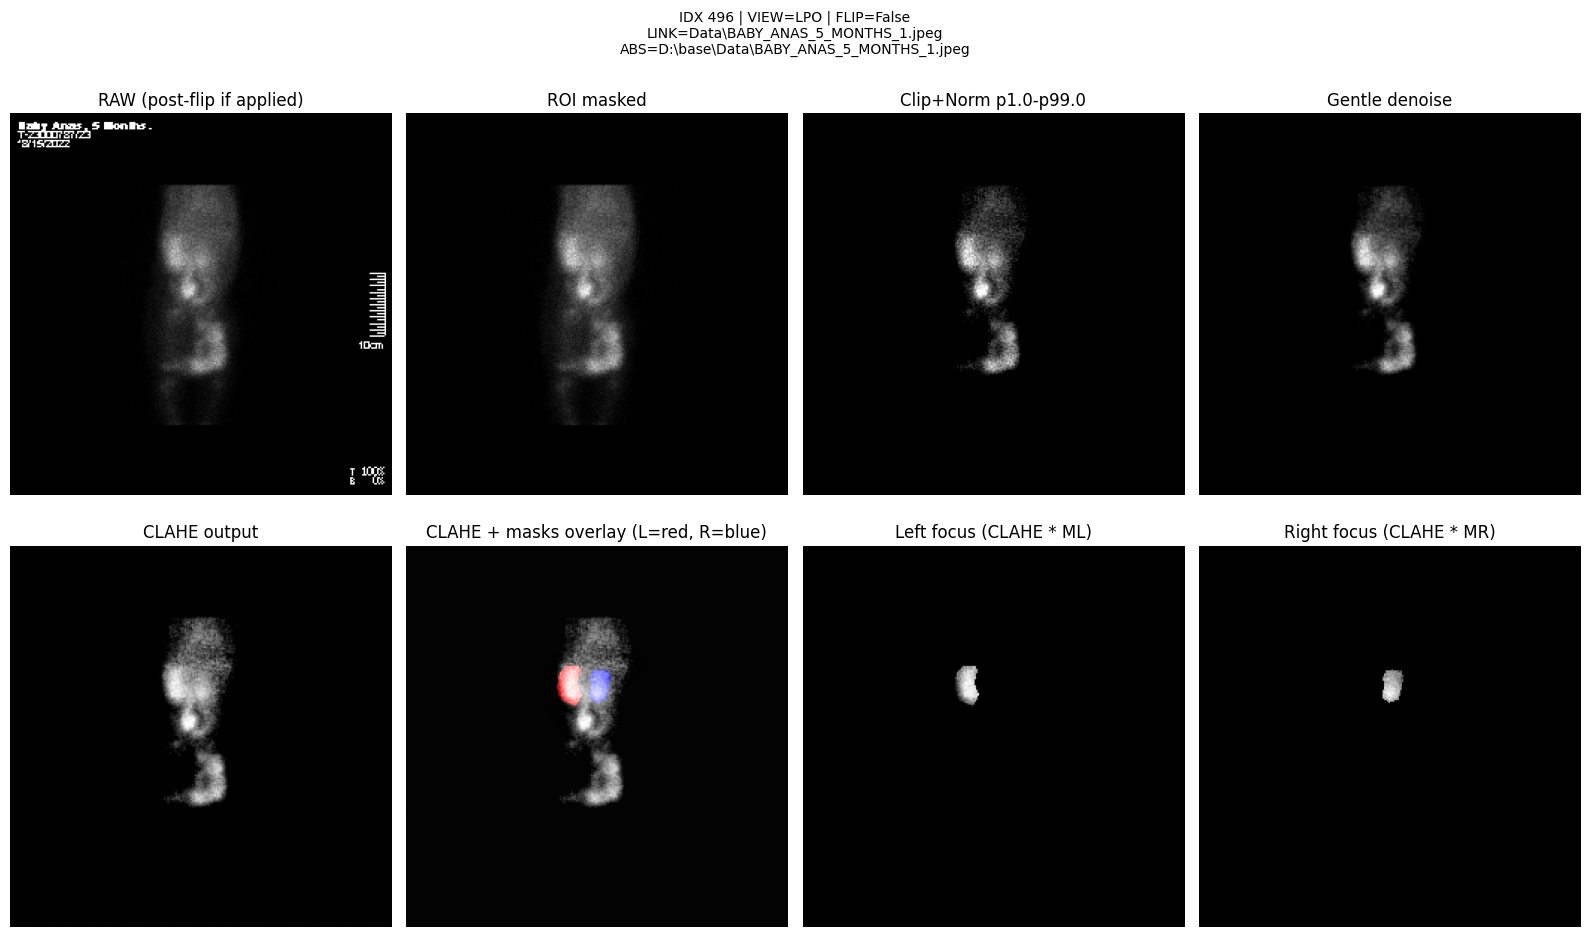

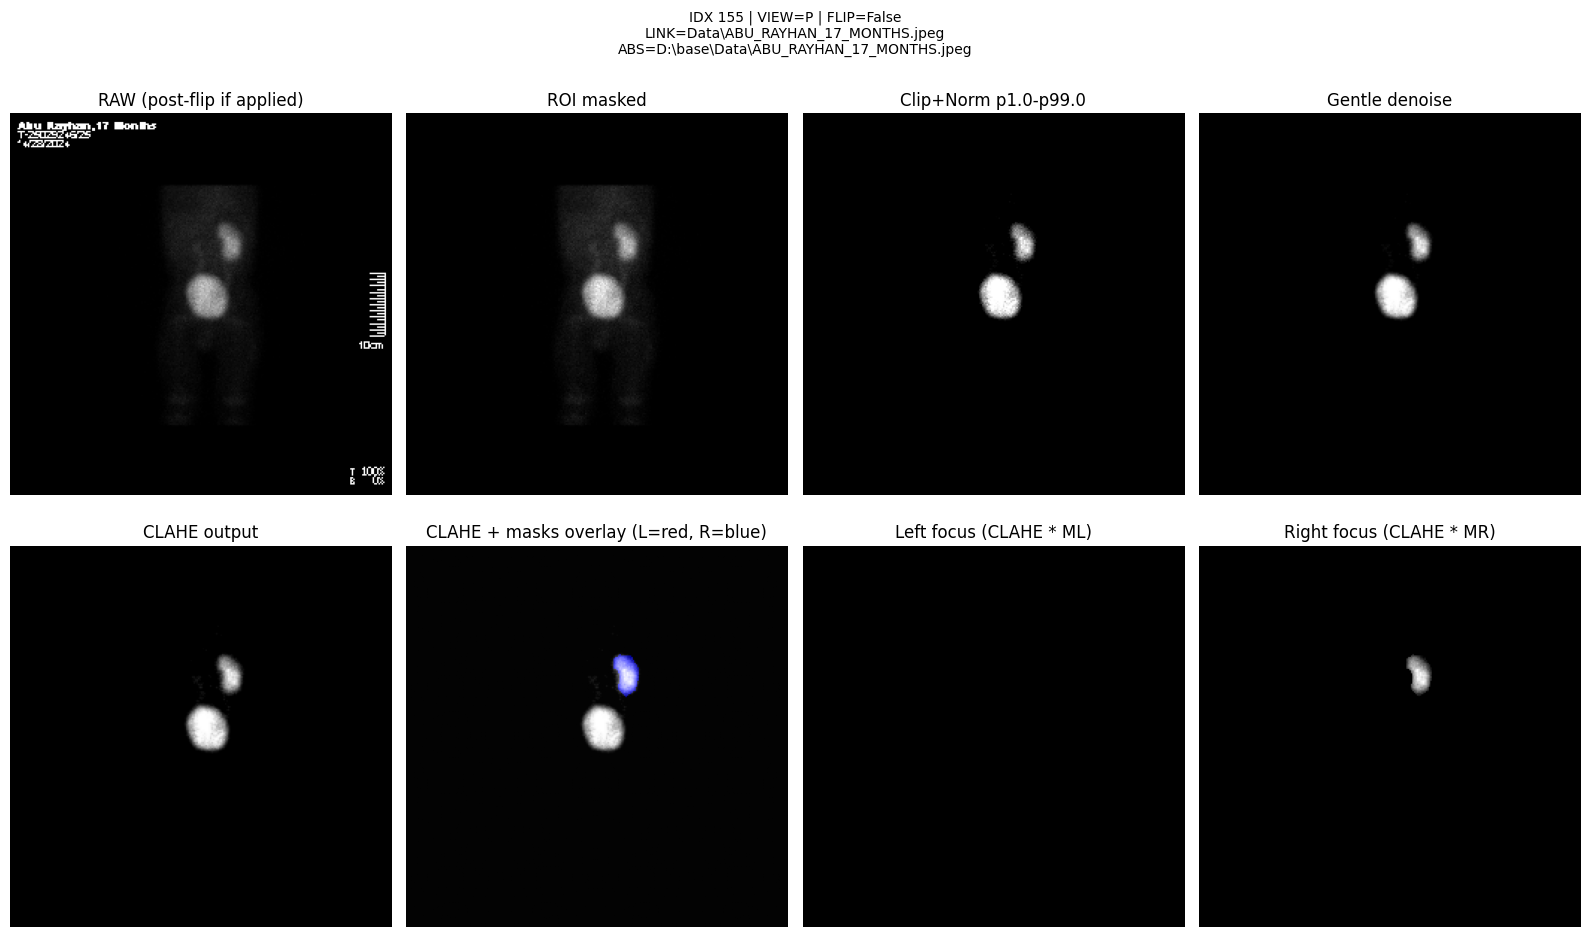

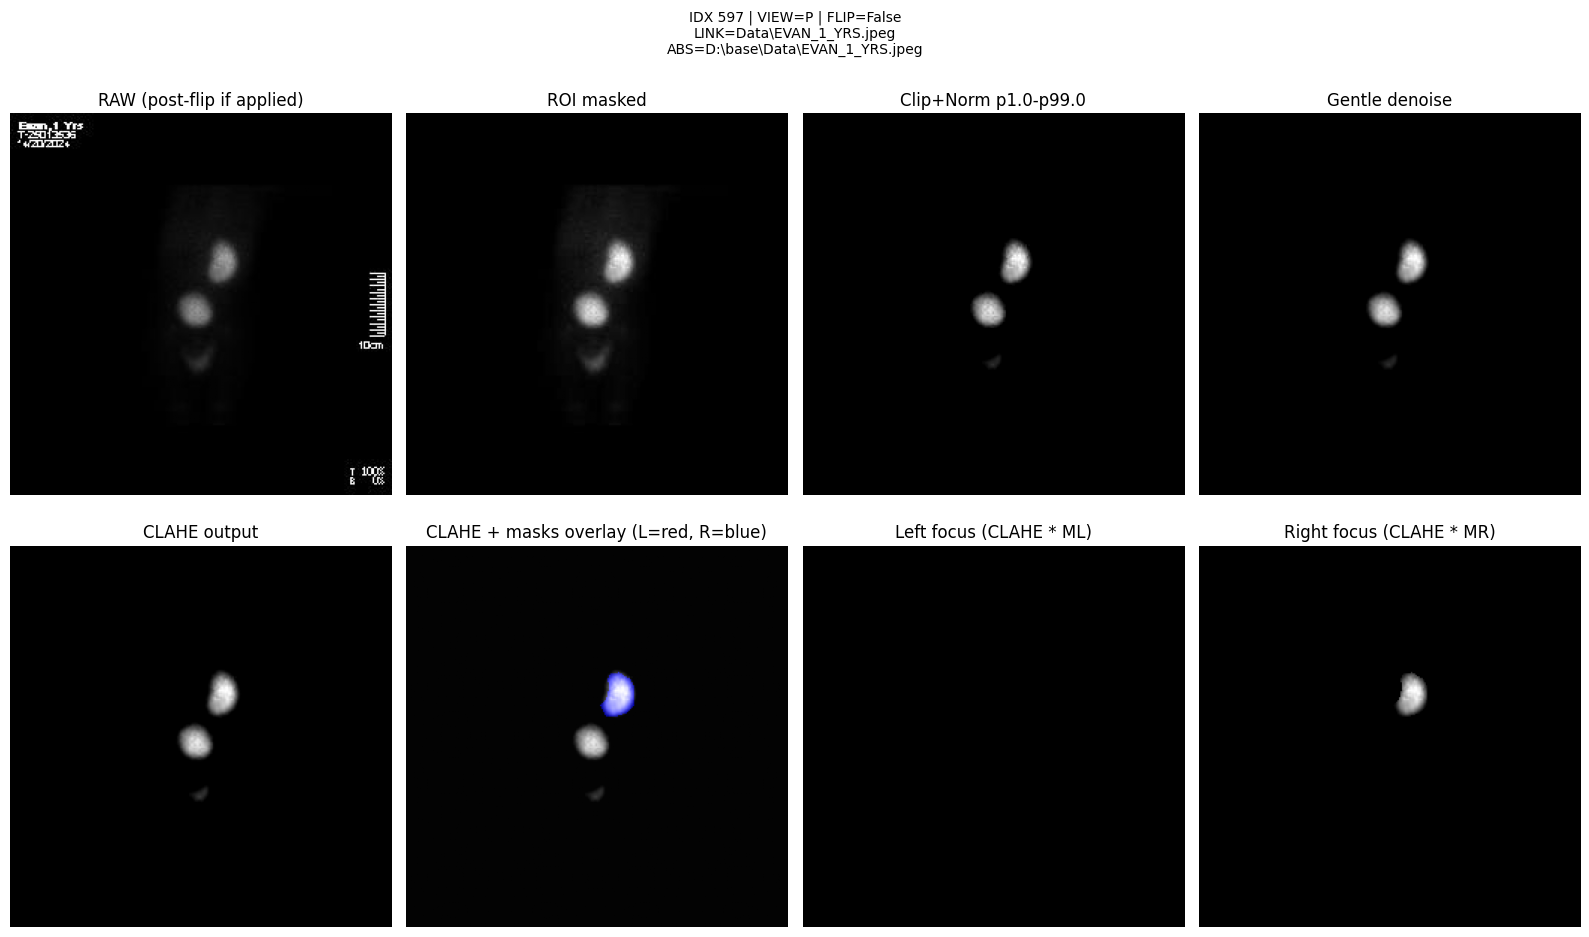

In [14]:
# CELL 13 — Visual proof (single sample) with flip indicator + tight side-by-side
def show_preprocess_v2(idx: int, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    pack = preprocess_row(idx, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe)

    I_raw   = pack["I_raw"]
    ML, MR  = pack["ML"], pack["MR"]
    I_roi   = pack["I_roi"]
    I_clip  = pack["I_clip"]
    I_dnz   = pack["I_dnz"]
    I_c     = pack["I_clahe"]
    I_L, I_R= pack["I_L"], pack["I_R"]

    overlay = np.dstack([I_c, I_c, I_c])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)  # left=red
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)  # right=blue

    title = f"IDX {pack['idx']} | VIEW={pack['view']} | FLIP={pack['did_flip']}\nLINK={pack['link']}\nABS={pack['abs_path']}"

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(title, fontsize=10)

    ax = plt.subplot(2,4,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW (post-flip if applied)"); ax.axis("off")
    ax = plt.subplot(2,4,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,4,3); ax.imshow(I_clip, cmap="gray"); ax.set_title(f"Clip+Norm p{p_lo}-p{p_hi}"); ax.axis("off")
    ax = plt.subplot(2,4,4); ax.imshow(I_dnz, cmap="gray"); ax.set_title("Gentle denoise"); ax.axis("off")

    ax = plt.subplot(2,4,5); ax.imshow(I_c, cmap="gray"); ax.set_title("CLAHE output"); ax.axis("off")
    ax = plt.subplot(2,4,6); ax.imshow(overlay); ax.set_title("CLAHE + masks overlay (L=red, R=blue)"); ax.axis("off")
    ax = plt.subplot(2,4,7); ax.imshow(I_L, cmap="gray"); ax.set_title("Left focus (CLAHE * ML)"); ax.axis("off")
    ax = plt.subplot(2,4,8); ax.imshow(I_R, cmap="gray"); ax.set_title("Right focus (CLAHE * MR)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# pick 3 samples that actually have masks (if possible), else random
cands = []
for i in tqdm(range(min(600, len(df))), desc="Finding samples with masks"):
    ML, MR = load_masks_for_link(df[COL_LINK].iloc[i])
    if (ML.sum() + MR.sum()) > 0:
        cands.append(i)

picks = random.sample(cands, k=min(3, len(cands))) if len(cands) > 0 else random.sample(range(len(df)), k=3)
print("Preprocess proof picks:", picks)

for idx in picks:
    show_preprocess_v2(idx)


In [15]:
# CELL 14 — Patient grouping proof (multi-view sets) + verify base stripping logic works
gb = df.groupby("__PATIENT_BASE__").indices
sizes = pd.Series({k: len(v) for k, v in gb.items()})

print("Patient groups:", len(gb))
print("Views per patient-base (value counts):")
print(sizes.value_counts().sort_index())

# Show 5 random patient groups with their LINKs (so you can visually verify)
some_keys = random.sample(list(gb.keys()), k=5)
for k in some_keys:
    idxs = gb[k]
    print("\nPATIENT_BASE:", k, "| n_views:", len(idxs))
    for i in idxs[:10]:
        row = df.iloc[i]
        print(" ", row[COL_LINK], "| VIEW=", (row[COL_VIEW] if COL_VIEW else "N/A"))


Patient groups: 759
Views per patient-base (value counts):
3    747
4      9
5      1
6      2
Name: count, dtype: int64

PATIENT_BASE: MUSTAFIZUR_RAHMAN_12_YRS | n_views: 3
  Data\MUSTAFIZUR_RAHMAN_12_YRS.jpeg | VIEW= P
  Data\MUSTAFIZUR_RAHMAN_12_YRS_1.jpeg | VIEW= LPO
  Data\MUSTAFIZUR_RAHMAN_12_YRS_2.jpeg | VIEW= RPO

PATIENT_BASE: NAFI_14_MONTH | n_views: 3
  Data\NAFI_14_MONTH.jpeg | VIEW= P
  Data\NAFI_14_MONTH_1.jpeg | VIEW= LPO
  Data\NAFI_14_MONTH_2.jpeg | VIEW= RPO

PATIENT_BASE: NIHAN_16MONTHS | n_views: 3
  Data\NIHAN_16MONTHS.jpeg | VIEW= P
  Data\NIHAN_16MONTHS_1.jpeg | VIEW= LPO
  Data\NIHAN_16MONTHS_2.jpeg | VIEW= RPO

PATIENT_BASE: NURJAHAN_30_YRS | n_views: 3
  Data\NURJAHAN_30_YRS.jpeg | VIEW= P
  Data\NURJAHAN_30_YRS_1.jpeg | VIEW= LPO
  Data\NURJAHAN_30_YRS_2.jpeg | VIEW= RPO

PATIENT_BASE: SHAHRIAR_15_MONTHS | n_views: 3
  Data\SHAHRIAR_15_MONTHS.jpeg | VIEW= P
  Data\SHAHRIAR_15_MONTHS_1.jpeg | VIEW= LPO
  Data\SHAHRIAR_15_MONTHS_2.jpeg | VIEW= RPO


In [16]:
# CELL 15 — PROOF: Masks are inside ROI (leakage check) + worst-case examples
# Goal:
# 1) Verify ML/MR pixels outside ROI are ~0 across dataset.
# 2) Print worst leakage cases (if any) so we can inspect them.

leak_records = []
max_leak = 0

for i in tqdm(range(len(df)), desc="Checking mask leakage outside ROI"):
    link = df[COL_LINK].iloc[i]
    ML, MR = load_masks_for_link(link)
    if (ML.sum() + MR.sum()) == 0:
        continue

    # Pixels in mask but outside ROI
    outside = (1 - ROI_U8).astype(np.uint8)
    leak_L = int((ML * outside).sum())
    leak_R = int((MR * outside).sum())
    leak = leak_L + leak_R

    if leak > 0:
        leak_records.append((i, leak, leak_L, leak_R, link))
        if leak > max_leak:
            max_leak = leak

print("Mask leakage outside ROI:")
print("  cases_with_any_leak:", len(leak_records))
print("  max_leak_pixels:", max_leak)

if len(leak_records) > 0:
    leak_records.sort(key=lambda x: x[1], reverse=True)
    print("\nTop 10 leakage cases:")
    for rec in leak_records[:10]:
        i, leak, leak_L, leak_R, link = rec
        print(f"  idx={i} leak={leak} (L={leak_L}, R={leak_R}) LINK={link}")
else:
    print("✅ No leakage detected in masked samples (within ROI).")


Checking mask leakage outside ROI:   0%|          | 0/2294 [00:00<?, ?it/s]

Mask leakage outside ROI:
  cases_with_any_leak: 0
  max_leak_pixels: 0
✅ No leakage detected in masked samples (within ROI).


Stat-mask proof picks: [534, 136]
IDX 534 | VIEW=P | FLIP=False
LINK=Data\BIPLAP_SHIL_BHULON_31_YRS.jpeg
Percentiles p1.0-p99.0:
  ROI only:        lo=0.0000 hi=0.2941
  ROI∩kidney-mask: lo=0.0902 hi=0.4275
Stat-mask pixels: 1255 | ROI pixels: 38416 | kidney pixels: 1255


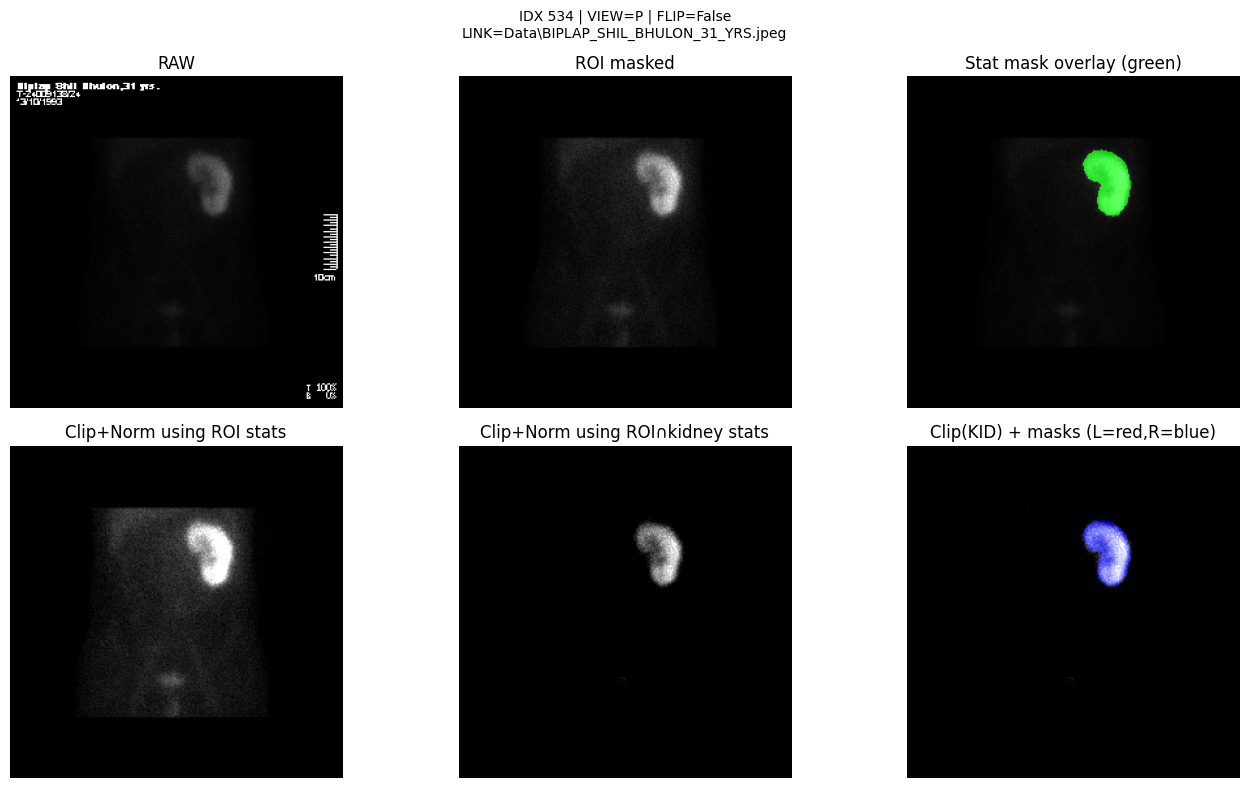

IDX 136 | VIEW=P | FLIP=False
LINK=Data\ABU_HANIF_04_YEARS_2.jpeg
Percentiles p1.0-p99.0:
  ROI only:        lo=0.0000 hi=0.2386
  ROI∩kidney-mask: lo=0.0706 hi=0.5294
Stat-mask pixels: 957 | ROI pixels: 38416 | kidney pixels: 957


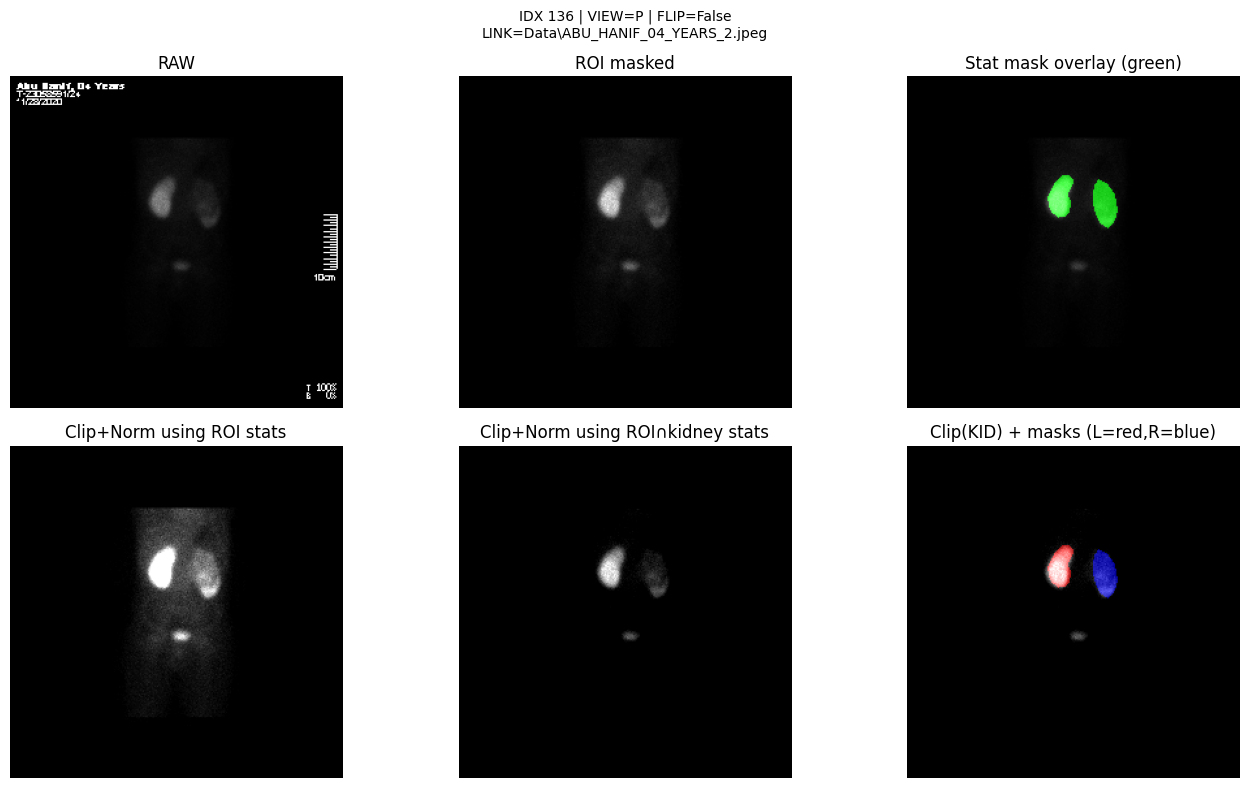

In [17]:
# CELL 16 — PROOF: Percentiles are computed from ROI∩kidney-mask (and show the stat-mask)
# Shows:
# - RAW/ROI
# - Stat mask overlay (green)
# - Percentiles computed from (ROI only) vs (ROI∩kidney-mask)
# - Before/after clip+norm visuals

def compute_percentiles(I_roi: np.ndarray, mask_bool: np.ndarray, p_lo=1.0, p_hi=99.0):
    vals = I_roi[mask_bool]
    if vals.size < 32:
        vals = I_roi.reshape(-1)
    lo = float(np.percentile(vals, p_lo))
    hi = float(np.percentile(vals, p_hi))
    return lo, hi

def show_statmask_proof(idx: int, p_lo=P_LO, p_hi=P_HI):
    row = df.iloc[idx]
    abs_path = Path(row["__ABS_PATH__"])
    link = row[COL_LINK]
    view_val = row[COL_VIEW] if COL_VIEW else None

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)
    I_raw, ML, MR, did_flip = maybe_flip(I_raw, ML, MR, view_val)

    I_roi = I_raw * ROI_F
    roi_mask = ROI_U8.astype(bool)

    kidney_mask = ((ML > 0) | (MR > 0))
    stat_mask = roi_mask & kidney_mask
    if stat_mask.sum() < 32:
        stat_mask = roi_mask

    lo_roi, hi_roi = compute_percentiles(I_roi, roi_mask, p_lo=p_lo, p_hi=p_hi)
    lo_kid, hi_kid = compute_percentiles(I_roi, stat_mask, p_lo=p_lo, p_hi=p_hi)

    I_clip_roi = intensity_clip_norm(I_roi, mask=roi_mask, p_lo=p_lo, p_hi=p_hi)
    I_clip_kid = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)

    # overlay stat mask (green) on ROI image
    overlay = np.dstack([I_roi, I_roi, I_roi])
    overlay[..., 1] = np.clip(overlay[..., 1] + 0.7*stat_mask.astype(np.float32), 0, 1)

    title = f"IDX {idx} | VIEW={view_val} | FLIP={did_flip}\nLINK={link}"
    print(title)
    print(f"Percentiles p{p_lo}-p{p_hi}:")
    print(f"  ROI only:        lo={lo_roi:.4f} hi={hi_roi:.4f}")
    print(f"  ROI∩kidney-mask: lo={lo_kid:.4f} hi={hi_kid:.4f}")
    print(f"Stat-mask pixels: {int(stat_mask.sum())} | ROI pixels: {int(roi_mask.sum())} | kidney pixels: {int(kidney_mask.sum())}")

    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(title, fontsize=10)

    ax = plt.subplot(2,3,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW"); ax.axis("off")
    ax = plt.subplot(2,3,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,3,3); ax.imshow(overlay); ax.set_title("Stat mask overlay (green)"); ax.axis("off")

    ax = plt.subplot(2,3,4); ax.imshow(I_clip_roi, cmap="gray"); ax.set_title("Clip+Norm using ROI stats"); ax.axis("off")
    ax = plt.subplot(2,3,5); ax.imshow(I_clip_kid, cmap="gray"); ax.set_title("Clip+Norm using ROI∩kidney stats"); ax.axis("off")

    # show mask overlay too
    I_tmp = np.clip(I_clip_kid,0,1)
    m_overlay = np.dstack([I_tmp, I_tmp, I_tmp])
    m_overlay[..., 0] = np.clip(m_overlay[..., 0] + 0.6*(ML>0), 0, 1)
    m_overlay[..., 2] = np.clip(m_overlay[..., 2] + 0.6*(MR>0), 0, 1)
    ax = plt.subplot(2,3,6); ax.imshow(m_overlay); ax.set_title("Clip(KID) + masks (L=red,R=blue)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# pick 2 masked samples and prove
masked_idxs = []
for i in range(min(800, len(df))):
    ML, MR = load_masks_for_link(df[COL_LINK].iloc[i])
    if (ML.sum() + MR.sum()) > 0:
        masked_idxs.append(i)

proof_picks = random.sample(masked_idxs, k=min(2, len(masked_idxs))) if masked_idxs else random.sample(range(len(df)), k=2)
print("Stat-mask proof picks:", proof_picks)

for idx in proof_picks:
    show_statmask_proof(idx)


In [18]:
# CELL 17 — LOCK IT: Make the "stats-from-kidney-mask" rule explicit (future-proof)
# Your current preprocess_for_model already behaves this way.
# This just makes it explicit and visible.

STATS_MODE = "roi_and_kidney_mask"  # locked rule

print("Locked clipping stats mode:", STATS_MODE)
print("Rule:")
print("  - Use ROI∩(ML∪MR) to compute percentiles when masks exist.")
print("  - Fallback to ROI when masks are empty/invalid.")


Locked clipping stats mode: roi_and_kidney_mask
Rule:
  - Use ROI∩(ML∪MR) to compute percentiles when masks exist.
  - Fallback to ROI when masks are empty/invalid.


In [19]:
# CELL 18 — Resolve ALL training-relevant CSV columns (no guessing) + show unique values (sanity)

COL_PATIENT_NAME = require_col(df, "PATIENT NAME")
COL_AGE_MONTHS   = require_col(df, "AGE in MONTHS")
COL_SEX          = require_col(df, "SEX")

COL_SIZE_L       = require_col(df, "SIZE LEFT")
COL_SIZE_R       = require_col(df, "SIZE RIGHT")

COL_ANATOMY      = require_col(df, "ANATOMY")
COL_KC_CSV       = require_col(df, "Kidney COUNT")

COL_SCAR_GLOBAL  = require_col(df, "SCAR")
COL_SCAR_L       = require_col(df, "SCAR LEFT")
COL_SCAR_R       = require_col(df, "SCAR RIGHT")

COL_UPTAKE_L     = require_col(df, "CORTICAL UPTAKE LEFT")
COL_UPTAKE_R     = require_col(df, "CORTICAL UPTAKE RIGHT")

# Optional (keep safe)
COL_POSITION     = optional_col(df, "POSITION")

print("Resolved key columns:")
for k, v in [
    ("COL_LINK", COL_LINK),
    ("COL_VIEW", COL_VIEW),
    ("COL_SIZE_L", COL_SIZE_L),
    ("COL_SIZE_R", COL_SIZE_R),
    ("COL_ANATOMY", COL_ANATOMY),
    ("COL_KC_CSV", COL_KC_CSV),
    ("COL_SCAR_GLOBAL", COL_SCAR_GLOBAL),
    ("COL_SCAR_L", COL_SCAR_L),
    ("COL_SCAR_R", COL_SCAR_R),
    ("COL_UPTAKE_L", COL_UPTAKE_L),
    ("COL_UPTAKE_R", COL_UPTAKE_R),
    ("COL_POSITION", COL_POSITION),
]:
    print(f"  {k}: {repr(v)}")

def show_uniques(col, n=30):
    vals = df[col].astype(str).fillna("NA").value_counts()
    print(f"\n[{col}] unique={len(vals)} | top {min(n,len(vals))}:")
    print(vals.head(n))

# Quick, explicit value sanity (this is just printing; no logic assumptions)
show_uniques(COL_ANATOMY)
show_uniques(COL_SIZE_L)
show_uniques(COL_SIZE_R)
show_uniques(COL_SCAR_L)
show_uniques(COL_SCAR_R)
show_uniques(COL_UPTAKE_L)
show_uniques(COL_UPTAKE_R)
show_uniques(COL_KC_CSV)
show_uniques(COL_SCAR_GLOBAL)
if COL_VIEW: show_uniques(COL_VIEW)


Resolved key columns:
  COL_LINK: 'LINK'
  COL_VIEW: 'VIEW'
  COL_SIZE_L: 'SIZE LEFT'
  COL_SIZE_R: 'SIZE RIGHT'
  COL_ANATOMY: 'ANATOMY'
  COL_KC_CSV: 'Kidney COUNT'
  COL_SCAR_GLOBAL: 'SCAR'
  COL_SCAR_L: 'SCAR LEFT'
  COL_SCAR_R: 'SCAR RIGHT'
  COL_UPTAKE_L: 'CORTICAL UPTAKE LEFT'
  COL_UPTAKE_R: 'CORTICAL UPTAKE RIGHT'
  COL_POSITION: 'POSITION'

[ANATOMY] unique=4 | top 4:
ANATOMY
NORMAL     1669
SINGLE      437
ECTOPIC     152
HORSHOE      36
Name: count, dtype: int64

[SIZE LEFT] unique=5 | top 5:
SIZE LEFT
NORMAL     1597
SMALLER     259
NV          204
BIGGER      165
PO           69
Name: count, dtype: int64

[SIZE RIGHT] unique=5 | top 5:
SIZE RIGHT
NORMAL     1535
NV          239
SMALLER     235
BIGGER      213
PO           72
Name: count, dtype: int64

[SCAR LEFT] unique=3 | top 3:
SCAR LEFT
NOT APPLICABLE    2111
MULTIPLE           171
SINGLE              12
Name: count, dtype: int64

[SCAR RIGHT] unique=3 | top 3:
SCAR RIGHT
NOT APPLICABLE    2114
MULTIPLE           174


In [20]:
# CELL 19 — FULL REPLACEMENT (FIX): Build GT presence from masks + parse labels (Scar/Anat/SizeRel/Uptake)
# Fix: DO NOT use mask_L/mask_R arrays. Load masks per row via load_masks_for_link(link).

def _s(x) -> str:
    return str(x).strip().upper()

ANAT_MAP_3 = {"NORMAL": 0, "ECTOPIC": 1, "HORSHOE": 2}
SIZE_MAP_3 = {"SMALLER": 0, "NORMAL": 1, "BIGGER": 2}

SCAR_PRESENT_SET = {"SINGLE", "MULTIPLE"}       # merged => 1
SCAR_NONE_TOKEN  = "NOT APPLICABLE"             # when kidney present => 0

UPTAKE_NORMAL_TOKEN = "NORMAL"
UPTAKE_REDUCED_TOKEN = "REDUCED"
UPTAKE_NA_TOKEN = "NOT APPLICABLE"

def parse_anat3(x) -> int:
    return ANAT_MAP_3.get(_s(x), -1)

def parse_size3(x) -> int:
    return SIZE_MAP_3.get(_s(x), -1)

def parse_scar_bin(x) -> int:
    ss = _s(x)
    if ss in SCAR_PRESENT_SET:
        return 1
    if ss == _s(SCAR_NONE_TOKEN):
        return 0
    return -1

def parse_uptake_bin(x) -> int:
    ss = _s(x)
    if ss == _s(UPTAKE_NORMAL_TOKEN):
        return 0
    if ss == _s(UPTAKE_REDUCED_TOKEN):
        return 1
    if ss == _s(UPTAKE_NA_TOKEN) or ss in {"NA", "N/A", ""}:
        return -1
    return -1

def derive_size_relation(szL_3: int, szR_3: int) -> int:
    # 0 L smaller, 1 equal, 2 L bigger
    if szL_3 < 0 or szR_3 < 0:
        return -1
    if szL_3 < szR_3:
        return 0
    if szL_3 == szR_3:
        return 1
    return 2

def _flip_lr_u8(a: np.ndarray) -> np.ndarray:
    # consistent horizontal flip for masks
    return np.ascontiguousarray(a[:, ::-1])

# ---- Build columns (with progress bar) ----
LP_list, RP_list = [], []
ML_sum_list, MR_sum_list = [], []

anat3_list, anat_abn_list, anat_sub_list = [], [], []
scarL_bin_list, scarR_bin_list = [], []
uptakeL_bin_list, uptakeR_bin_list = [], []
sizeL_3_list, sizeR_3_list, size_rel_list = [], [], []

pbar = tqdm(range(len(df)), desc="Build targets (masks + labels)", leave=False)
for i in pbar:
    row = df.iloc[i]
    link = row[COL_LINK]
    view_val = row[COL_VIEW] if COL_VIEW else ""

    # Load masks for this image (256x256)
    ML, MR = load_masks_for_link(link)

    # Apply the SAME flip rule as images (RPO/RLO) so left/right semantics stay consistent
    if should_flip_by_view(view_val):
        ML = _flip_lr_u8(ML)
        MR = _flip_lr_u8(MR)

    ml_sum = int(ML.sum())
    mr_sum = int(MR.sum())

    lp = 1 if ml_sum > 0 else 0
    rp = 1 if mr_sum > 0 else 0

    LP_list.append(lp); RP_list.append(rp)
    ML_sum_list.append(ml_sum); MR_sum_list.append(mr_sum)

    # ---- ANATOMY (only when BOTH kidneys present) ----
    a3 = parse_anat3(row[COL_ANATOMY])
    if lp == 1 and rp == 1 and a3 in (0, 1, 2):
        anat3_list.append(a3)
        anat_abn_list.append(0 if a3 == 0 else 1)
        if a3 in (1, 2):
            anat_sub_list.append(0 if a3 == 1 else 1)  # 0 ectopic, 1 horshoe
        else:
            anat_sub_list.append(-1)
    else:
        anat3_list.append(-1)
        anat_abn_list.append(-1)
        anat_sub_list.append(-1)

    # ---- SCAR (binary, only when side present; else ignore) ----
    sL = parse_scar_bin(row[COL_SCAR_L])
    sR = parse_scar_bin(row[COL_SCAR_R])
    scarL_bin_list.append(sL if (lp == 1 and sL in (0, 1)) else -1)
    scarR_bin_list.append(sR if (rp == 1 and sR in (0, 1)) else -1)

    # ---- UPTAKE (binary NORMAL/REDUCED, only when side present; NOT APPLICABLE => ignore) ----
    uL = parse_uptake_bin(row[COL_UPTAKE_L])
    uR = parse_uptake_bin(row[COL_UPTAKE_R])
    uptakeL_bin_list.append(uL if (lp == 1 and uL in (0, 1)) else -1)
    uptakeR_bin_list.append(uR if (rp == 1 and uR in (0, 1)) else -1)

    # ---- SIZE RELATION (only when BOTH present + both side labels valid) ----
    szL = parse_size3(row[COL_SIZE_L])
    szR = parse_size3(row[COL_SIZE_R])
    if lp == 0: szL = -1
    if rp == 0: szR = -1

    sizeL_3_list.append(szL)
    sizeR_3_list.append(szR)

    if lp == 1 and rp == 1:
        size_rel_list.append(derive_size_relation(szL, szR))
    else:
        size_rel_list.append(-1)

# Save columns
df["__LP_GT__"] = LP_list
df["__RP_GT__"] = RP_list
df["__ML_SUM__"] = ML_sum_list
df["__MR_SUM__"] = MR_sum_list

df["__ANAT3__"] = anat3_list
df["__ANAT_ABN__"] = anat_abn_list
df["__ANAT_SUB__"] = anat_sub_list

df["__SCARL_BIN__"] = scarL_bin_list
df["__SCARR_BIN__"] = scarR_bin_list

df["__UPTAKEL_BIN__"] = uptakeL_bin_list
df["__UPTAKER_BIN__"] = uptakeR_bin_list

df["__SIZEL_3__"] = sizeL_3_list
df["__SIZER_3__"] = sizeR_3_list
df["__SIZE_REL__"] = size_rel_list

print("✅ Done. Targets rebuilt (using load_masks_for_link, no mask_L/mask_R arrays).")
print(df[["__LP_GT__","__RP_GT__","__SCARL_BIN__","__SCARR_BIN__","__UPTAKEL_BIN__","__UPTAKER_BIN__","__SIZE_REL__"]].head(10))


Build targets (masks + labels):   0%|          | 0/2294 [00:00<?, ?it/s]

✅ Done. Targets rebuilt (using load_masks_for_link, no mask_L/mask_R arrays).
   __LP_GT__  __RP_GT__  __SCARL_BIN__  __SCARR_BIN__  __UPTAKEL_BIN__  \
0          1          1              0              1                0   
1          1          1              0              1                0   
2          1          1              0              1                0   
3          1          1              0              0                0   
4          1          1              0              0                0   
5          1          1              0              0                0   
6          0          1             -1              0               -1   
7          0          1             -1              0               -1   
8          0          1             -1              0               -1   
9          1          1              0              0                0   

   __UPTAKER_BIN__  __SIZE_REL__  
0                1             1  
1                1             1  
2 

In [21]:
# CELL 20 — FULL REPLACEMENT: Imbalance report for the NEW targets
# (scar binary + anatomy two-step + size relation + uptake binary)

def vc(series, name):
    s = pd.Series(series)
    print(f"\n{name} value_counts:")
    print(s.value_counts(dropna=False).sort_index())

vc(df["__LP_GT__"], "__LP_GT__")
vc(df["__RP_GT__"], "__RP_GT__")

# Anatomy validity and distributions
valid_anat = df["__ANAT3__"] >= 0
print("\nANATOMY valid samples:", int(valid_anat.sum()), "out of", len(df))
vc(df.loc[valid_anat, "__ANAT3__"], "ANAT3 (0=NORMAL,1=ECTOPIC,2=HORSHOE)")
vc(df.loc[valid_anat, "__ANAT_ABN__"], "ANAT_ABN (0=normal,1=abnormal)")
vc(df.loc[df["__ANAT_SUB__"] >= 0, "__ANAT_SUB__"], "ANAT_SUB (0=ECTOPIC,1=HORSHOE)")

# Scar present-only binary distributions
valid_sL = df["__SCARL_BIN__"] >= 0
valid_sR = df["__SCARR_BIN__"] >= 0
print("\nSCARL valid samples:", int(valid_sL.sum()), "SCARR valid samples:", int(valid_sR.sum()))
vc(df.loc[valid_sL, "__SCARL_BIN__"], "SCARL_BIN (0=none,1=present)")
vc(df.loc[valid_sR, "__SCARR_BIN__"], "SCARR_BIN (0=none,1=present)")

# Uptake binary distributions (valid only)
valid_uL = df["__UPTAKEL_BIN__"] >= 0
valid_uR = df["__UPTAKER_BIN__"] >= 0
print("\nUPTAKEL valid samples:", int(valid_uL.sum()), "UPTAKER valid samples:", int(valid_uR.sum()))
vc(df.loc[valid_uL, "__UPTAKEL_BIN__"], "UPTAKEL_BIN (0=NORMAL,1=REDUCED)")
vc(df.loc[valid_uR, "__UPTAKER_BIN__"], "UPTAKER_BIN (0=NORMAL,1=REDUCED)")

# Size relation distributions (both present + size labels valid)
valid_rel = df["__SIZE_REL__"] >= 0
print("\nSIZE_REL valid samples:", int(valid_rel.sum()))
vc(df.loc[valid_rel, "__SIZE_REL__"], "SIZE_REL (0=L smaller,1=equal,2=L bigger)")



__LP_GT__ value_counts:
__LP_GT__
0     204
1    2090
Name: count, dtype: int64

__RP_GT__ value_counts:
__RP_GT__
0     239
1    2055
Name: count, dtype: int64

ANATOMY valid samples: 1851 out of 2294

ANAT3 (0=NORMAL,1=ECTOPIC,2=HORSHOE) value_counts:
__ANAT3__
0    1663
1     152
2      36
Name: count, dtype: int64

ANAT_ABN (0=normal,1=abnormal) value_counts:
__ANAT_ABN__
0    1663
1     188
Name: count, dtype: int64

ANAT_SUB (0=ECTOPIC,1=HORSHOE) value_counts:
__ANAT_SUB__
0    152
1     36
Name: count, dtype: int64

SCARL valid samples: 2090 SCARR valid samples: 2055

SCARL_BIN (0=none,1=present) value_counts:
__SCARL_BIN__
0    1907
1     183
Name: count, dtype: int64

SCARR_BIN (0=none,1=present) value_counts:
__SCARR_BIN__
0    1875
1     180
Name: count, dtype: int64

UPTAKEL valid samples: 2090 UPTAKER valid samples: 2055

UPTAKEL_BIN (0=NORMAL,1=REDUCED) value_counts:
__UPTAKEL_BIN__
0    1493
1     597
Name: count, dtype: int64

UPTAKER_BIN (0=NORMAL,1=REDUCED) value_cou

Scar examples picks:
  Left present (1): [205, 1996]
  Left none (0):    [1340, 1949]
  Right present (1): [132, 412]
  Right none (0):    [1088, 1233]


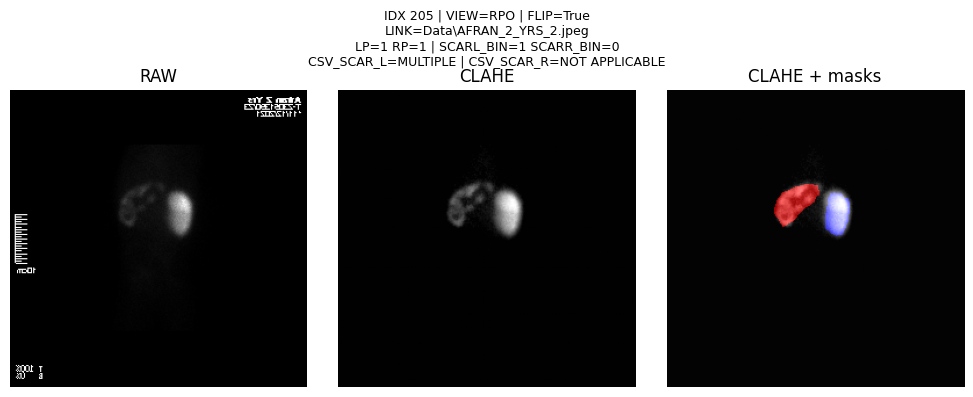

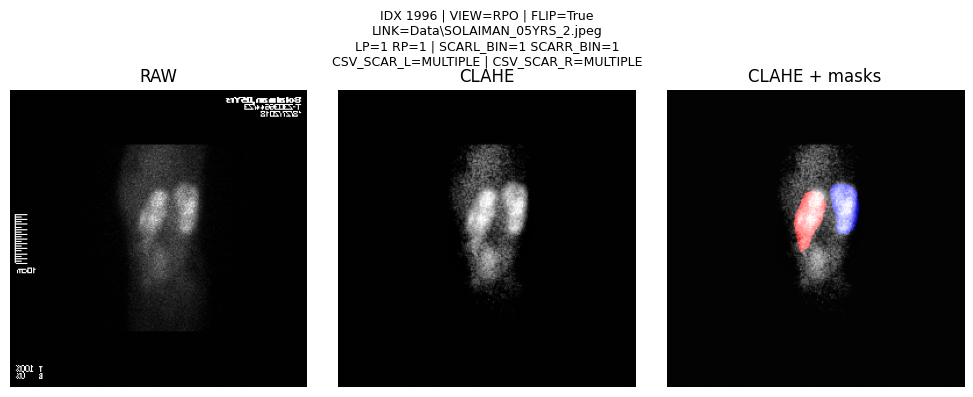

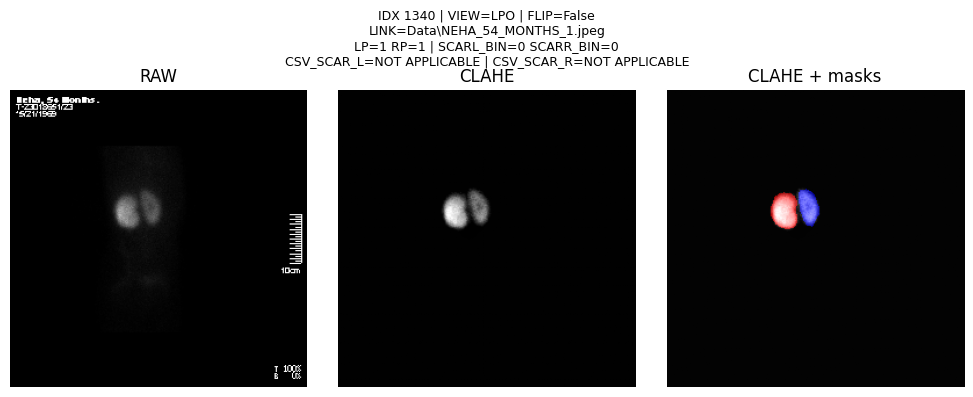

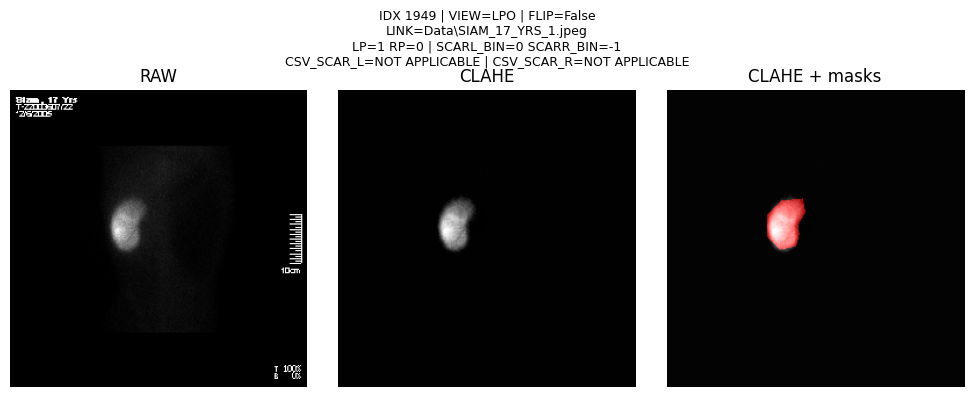

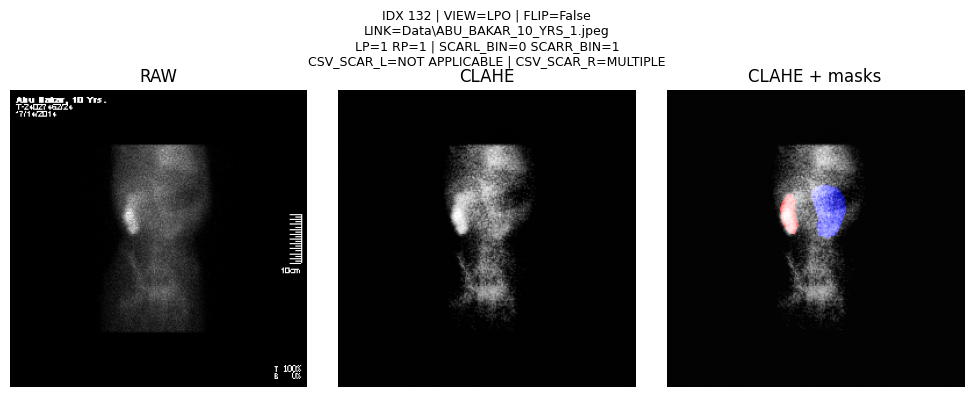

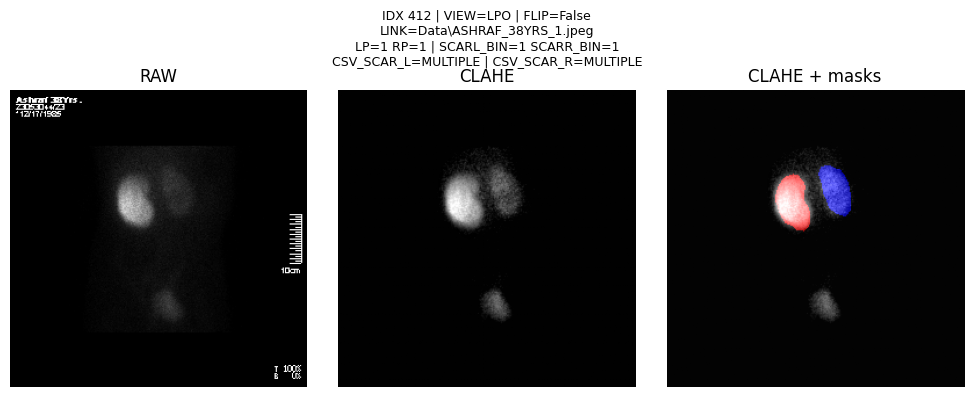

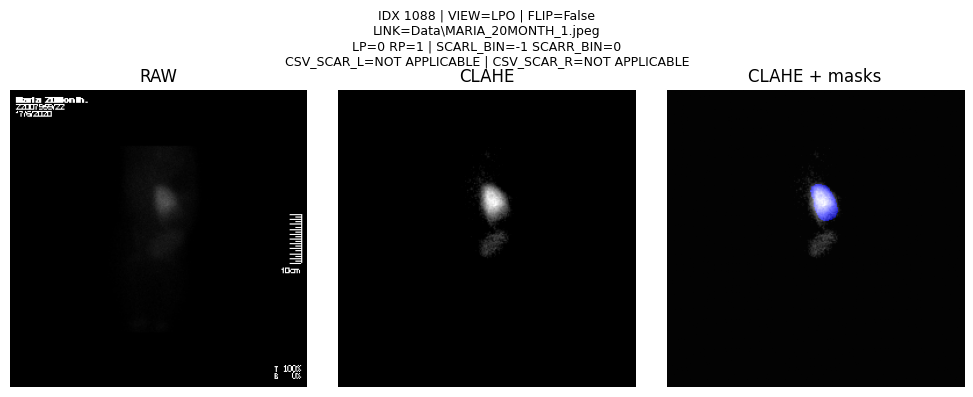

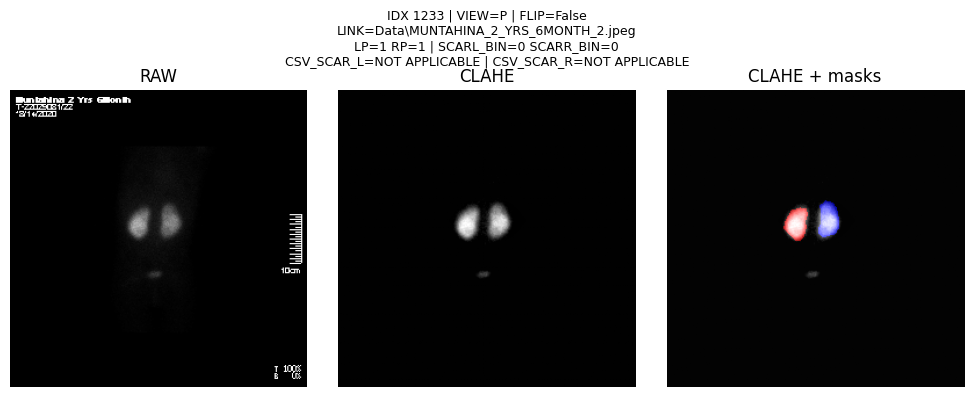

In [22]:
# CELL 21 — Visual verification for SCAR labels (show examples of scar-present vs scar-none)
# This proves that our "NOT APPLICABLE => NONE" is only applied when kidney is present (mask exists).

def pick_examples_for_scar(side="L", want=1, k=3, max_scan=2000):
    """
    side: 'L' or 'R'
    want: 1 (present) or 0 (none)
    """
    col = "__SCARL_BIN__" if side.upper() == "L" else "__SCARR_BIN__"
    idxs = []
    for i in range(min(max_scan, len(df))):
        if int(df[col].iloc[i]) == int(want):
            idxs.append(i)
    if len(idxs) == 0:
        return []
    return random.sample(idxs, k=min(k, len(idxs)))

def show_scar_case(idx: int):
    pack = preprocess_row(idx, p_lo=P_LO, p_hi=P_HI, do_clahe=True)
    ML, MR = pack["ML"], pack["MR"]
    I_c = pack["I_clahe"]

    overlay = np.dstack([I_c, I_c, I_c])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)

    title = (
        f"IDX {idx} | VIEW={pack['view']} | FLIP={pack['did_flip']}\n"
        f"LINK={pack['link']}\n"
        f"LP={df['__LP_GT__'].iloc[idx]} RP={df['__RP_GT__'].iloc[idx]} | "
        f"SCARL_BIN={df['__SCARL_BIN__'].iloc[idx]} SCARR_BIN={df['__SCARR_BIN__'].iloc[idx]}\n"
        f"CSV_SCAR_L={df[COL_SCAR_L].iloc[idx]} | CSV_SCAR_R={df[COL_SCAR_R].iloc[idx]}"
    )

    plt.figure(figsize=(10,4))
    plt.suptitle(title, fontsize=9)
    plt.subplot(1,3,1); plt.imshow(pack["I_raw"], cmap="gray"); plt.title("RAW"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(pack["I_clahe"], cmap="gray"); plt.title("CLAHE"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title("CLAHE + masks"); plt.axis("off")
    plt.tight_layout()
    plt.show()

# Pick and show examples
pL1 = pick_examples_for_scar("L", want=1, k=2)
pL0 = pick_examples_for_scar("L", want=0, k=2)
pR1 = pick_examples_for_scar("R", want=1, k=2)
pR0 = pick_examples_for_scar("R", want=0, k=2)

print("Scar examples picks:")
print("  Left present (1):", pL1)
print("  Left none (0):   ", pL0)
print("  Right present (1):", pR1)
print("  Right none (0):   ", pR0)

for idx in (pL1 + pL0 + pR1 + pR0):
    show_scar_case(idx)


In [23]:
# CELL 22 — Patient-level split (train/val/test) with HORSHOE enforcement (no leakage)
# Split unit = __PATIENT_BASE__ (your filename-based patient grouping)
# Goal:
# 1) Patient-disjoint splits
# 2) Ensure at least 1 HORSHOE patient in VAL and 1 in TEST (if possible)

SEED = 1337
rng = np.random.default_rng(SEED)

SPLIT_TRAIN = 0
SPLIT_VAL   = 1
SPLIT_TEST  = 2

SPLIT_NAME = {0: "train", 1: "val", 2: "test"}

# Unique patient IDs
patient_ids = df["__PATIENT_BASE__"].dropna().astype(str).unique().tolist()
patient_ids = sorted(patient_ids)
n_pat = len(patient_ids)
print("Total unique patient_ids:", n_pat)

# Identify HORSHOE patients (based on valid anatomy target)
horseshoe_patients = sorted(df.loc[df["__ANAT3__"] == 2, "__PATIENT_BASE__"].astype(str).unique().tolist())
print("HORSHOE patient_ids (unique):", len(horseshoe_patients))

# Targets for patient counts
n_val  = max(1, int(round(0.10 * n_pat)))
n_test = max(1, int(round(0.10 * n_pat)))
n_train = n_pat - n_val - n_test
if n_train < 1:
    # safety
    n_train = max(1, n_train)
print("Target patient counts:", {"train": n_train, "val": n_val, "test": n_test})

def make_patient_split(patient_ids, horseshoe_patients, n_train, n_val, n_test, rng):
    all_set = set(patient_ids)
    hs_set = set(horseshoe_patients)

    # Randomize order (stable w/ seed)
    ids = patient_ids.copy()
    rng.shuffle(ids)

    train_set = set()
    val_set   = set()
    test_set  = set()

    # --- Enforce horseshoe presence ---
    hs = list(horseshoe_patients)
    rng.shuffle(hs)

    # Put 1 HS in val and 1 HS in test if possible
    if len(hs) >= 1 and n_val > 0:
        val_set.add(hs[0])
    if len(hs) >= 2 and n_test > 0:
        test_set.add(hs[1])
    elif len(hs) == 1 and n_test > 0:
        # If only one HS patient exists, keep it in VAL; TEST can't have HS.
        pass

    # Fill remaining with the randomized ids list
    for pid in ids:
        if pid in val_set or pid in test_set:
            continue
        # Fill train first, then val, then test
        if len(train_set) < n_train:
            train_set.add(pid)
        elif len(val_set) < n_val:
            val_set.add(pid)
        elif len(test_set) < n_test:
            test_set.add(pid)

    # If any split is short (due to rounding or enforcement), fix by moving from train
    # (never violate disjointness)
    def move_from_train(target_set, target_n):
        nonlocal train_set
        if len(target_set) >= target_n:
            return
        need = target_n - len(target_set)
        move_ids = list(train_set)[:need]
        for m in move_ids:
            train_set.remove(m)
            target_set.add(m)

    move_from_train(val_set, n_val)
    move_from_train(test_set, n_test)

    # Final sanity: disjoint + coverage
    assert len(train_set & val_set) == 0
    assert len(train_set & test_set) == 0
    assert len(val_set & test_set) == 0
    assert len(train_set | val_set | test_set) == n_pat

    return train_set, val_set, test_set

train_pat, val_pat, test_pat = make_patient_split(patient_ids, horseshoe_patients, n_train, n_val, n_test, rng)

print("Patient split counts:", {"train": len(train_pat), "val": len(val_pat), "test": len(test_pat)})

# Proof of horseshoe enforcement
hs_train = len(set(horseshoe_patients) & train_pat)
hs_val   = len(set(horseshoe_patients) & val_pat)
hs_test  = len(set(horseshoe_patients) & test_pat)
print("HORSHOE patients by split:", {"train": hs_train, "val": hs_val, "test": hs_test})


Total unique patient_ids: 759
HORSHOE patient_ids (unique): 12
Target patient counts: {'train': 607, 'val': 76, 'test': 76}
Patient split counts: {'train': 607, 'val': 76, 'test': 76}
HORSHOE patients by split: {'train': 8, 'val': 1, 'test': 3}


In [24]:
# CELL 23 — Assign split label to each row + leak-proof checks
def split_of_patient(pid: str) -> int:
    if pid in train_pat:
        return SPLIT_TRAIN
    if pid in val_pat:
        return SPLIT_VAL
    return SPLIT_TEST

df["__SPLIT__"] = [split_of_patient(pid) for pid in df["__PATIENT_BASE__"].astype(str).tolist()]
df["__SPLIT_NAME__"] = df["__SPLIT__"].map(SPLIT_NAME)

print(df["__SPLIT_NAME__"].value_counts())

# Leak proof: no patient_id appears in more than one split
pat_to_splits = df.groupby("__PATIENT_BASE__")["__SPLIT__"].nunique()
bad = pat_to_splits[pat_to_splits > 1]
print("Patients with split leakage:", int((pat_to_splits > 1).sum()))
if len(bad) > 0:
    print("Leakage examples:")
    print(bad.head(20))
    raise RuntimeError("Split leakage detected. Stop and fix.")

print("✅ Patient-level splits are disjoint.")


__SPLIT_NAME__
train    1834
test      231
val       229
Name: count, dtype: int64
Patients with split leakage: 0
✅ Patient-level splits are disjoint.


In [64]:
# CELL 24 — FULL REPLACEMENT: Split report (images + patient-level anat subtype) + horseshoe presence

def report_split(df, split_id, name):
    sub = df[df["__SPLIT__"] == split_id]
    n_img = len(sub)
    n_pat = sub["__PATIENT_BASE__"].nunique()

    # -----------------------------
    # Image-level anatomy counts (valid only)
    # -----------------------------
    anat_valid = sub[sub["__ANAT3__"] >= 0]
    anat_counts_img = anat_valid["__ANAT3__"].value_counts().sort_index().to_dict()

    # -----------------------------
    # Patient-level anatomy subtype counts (valid only)
    # Rule: for each patient, take MAX anat label across valid views
    # (0=NORMAL, 1=ECTOPIC, 2=HORSESHOE). This is for sanity-checking distribution & ensuring HS exists.
    # -----------------------------
    pat_anat = (
        anat_valid.groupby("__PATIENT_BASE__")["__ANAT3__"]
        .max()
    )
    anat_counts_pat = pat_anat.value_counts().sort_index().to_dict()

    # Disagreement check: how many patients have >1 unique valid anat label across their views?
    anat_nunique_by_pat = anat_valid.groupby("__PATIENT_BASE__")["__ANAT3__"].nunique()
    n_pat_anat_disagree = int((anat_nunique_by_pat > 1).sum())

    # horseshoe patient count (patient-level)
    hs_pat = int((pat_anat == 2).sum())

    # -----------------------------
    # Scar present counts (valid only)
    # -----------------------------
    sL_valid = sub[sub["__SCARL_BIN__"] >= 0]["__SCARL_BIN__"].value_counts().sort_index().to_dict()
    sR_valid = sub[sub["__SCARR_BIN__"] >= 0]["__SCARR_BIN__"].value_counts().sort_index().to_dict()
    sL_present = int(sub["__SCARL_BIN__"].eq(1).sum())
    sR_present = int(sub["__SCARR_BIN__"].eq(1).sum())

    # -----------------------------
    # Size relation (valid only)
    # -----------------------------
    rel_valid = sub[sub["__SIZE_REL__"] >= 0]["__SIZE_REL__"].value_counts().sort_index().to_dict()

    print(f"\n=== SPLIT: {name} ===")
    print("patients:", n_pat, "| images:", n_img)

    print("ANAT3 valid images:", len(anat_valid),
          "| image-counts (0=NORMAL,1=ECTOPIC,2=HORSESHOE):", anat_counts_img)

    print("ANAT3 patient-counts (MAX over valid views):", anat_counts_pat,
          "| patients_with_view_disagreement:", n_pat_anat_disagree)

    print("HORSHOE patients:", hs_pat)

    print("SCARL_BIN valid counts (0=none,1=present):", sL_valid, "| present_rows:", sL_present)
    print("SCARR_BIN valid counts (0=none,1=present):", sR_valid, "| present_rows:", sR_present)

    print("SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger):", rel_valid)


report_split(df, SPLIT_TRAIN, "train")
report_split(df, SPLIT_VAL,   "val")
report_split(df, SPLIT_TEST,  "test")



=== SPLIT: train ===
patients: 607 | images: 1834
ANAT3 valid images: 1512 | image-counts (0=NORMAL,1=ECTOPIC,2=HORSESHOE): {0: 1372, 1: 116, 2: 24}
ANAT3 patient-counts (MAX over valid views): {0: 454, 1: 38, 2: 8} | patients_with_view_disagreement: 0
HORSHOE patients: 8
SCARL_BIN valid counts (0=none,1=present): {0: 1537, 1: 150} | present_rows: 150
SCARR_BIN valid counts (0=none,1=present): {0: 1509, 1: 150} | present_rows: 150
SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger): {0: 303, 1: 913, 2: 242}

=== SPLIT: val ===
patients: 76 | images: 229
ANAT3 valid images: 163 | image-counts (0=NORMAL,1=ECTOPIC,2=HORSESHOE): {0: 147, 1: 13, 2: 3}
ANAT3 patient-counts (MAX over valid views): {0: 49, 1: 4, 2: 1} | patients_with_view_disagreement: 0
HORSHOE patients: 1
SCARL_BIN valid counts (0=none,1=present): {0: 187, 1: 15} | present_rows: 15
SCARR_BIN valid counts (0=none,1=present): {0: 178, 1: 12} | present_rows: 12
SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger): {0: 42,

In [26]:
# CELL 25 — Balanced sampling weights (for TRAIN only)
# Strategy:
# - NO global downsampling
# - Use per-row weights to oversample rare signals:
#   * Horseshoe anatomy (ANAT3==2)
#   * Scar present on either side (SCARL_BIN==1 or SCARR_BIN==1)
#
# Notes:
# - Weights apply only in TRAIN loader later.
# - Moderate multipliers (start small; can tune later).
# - We cap weights to avoid extreme behavior.

W_BASE = 1.0
W_HORSHOE = 4.0       # horseshoe is very rare
W_SCAR_PRESENT = 3.0  # scar-present is rare
W_CAP = 10.0

train_mask = df["__SPLIT__"] == SPLIT_TRAIN
weights = np.ones(len(df), dtype=np.float32) * W_BASE

# boost horseshoe rows (only where anatomy valid)
weights[(train_mask) & (df["__ANAT3__"] == 2)] *= W_HORSHOE

# boost any scar-present rows (present-only binary)
scar_present_any = (df["__SCARL_BIN__"] == 1) | (df["__SCARR_BIN__"] == 1)
weights[(train_mask) & (scar_present_any)] *= W_SCAR_PRESENT

# cap
weights = np.minimum(weights, W_CAP)

df["__W_TRAIN__"] = weights

print("Train weights summary:")
w_train = df.loc[train_mask, "__W_TRAIN__"].values
print("  min:", float(w_train.min()), "max:", float(w_train.max()), "mean:", float(w_train.mean()))
print("  unique weights (train):", sorted(set([float(x) for x in np.unique(w_train)]))[:20], "...")

# Show how many train rows get boosted
print("Boosted horseshoe rows in train:", int(((train_mask) & (df["__ANAT3__"] == 2)).sum()))
print("Boosted scar-present rows in train:", int(((train_mask) & (scar_present_any)).sum()))
print("Boosted any rows in train:", int(((train_mask) & (df["__W_TRAIN__"] > W_BASE)).sum()))


Train weights summary:
  min: 1.0 max: 4.0 mean: 1.2486368417739868
  unique weights (train): [1.0, 3.0, 4.0] ...
Boosted horseshoe rows in train: 24
Boosted scar-present rows in train: 192
Boosted any rows in train: 216


In [27]:
# CELL 26 — (Optional) Torch sampler object creation (safe)
# If torch is installed, we create a WeightedRandomSampler for TRAIN rows.
# If not, we still keep the weights for later.

try:
    import torch
    from torch.utils.data import WeightedRandomSampler
    _HAS_TORCH = True
except Exception as e:
    _HAS_TORCH = False
    print("Torch not available in this environment:", e)

print("Torch available:", _HAS_TORCH)

if _HAS_TORCH:
    train_indices = np.where(df["__SPLIT__"].values == SPLIT_TRAIN)[0]
    train_weights = df.loc[train_indices, "__W_TRAIN__"].values.astype(np.float64)

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(train_weights, dtype=torch.double),
        num_samples=len(train_indices),   # 1 epoch ~= train size
        replacement=True
    )

    print("✅ Created WeightedRandomSampler for TRAIN.")
    print("  train_indices:", len(train_indices))
else:
    sampler = None


Torch available: True
✅ Created WeightedRandomSampler for TRAIN.
  train_indices: 1834


In [28]:
# CELL 27 — FULL ADDITION: Core helpers required by DMSADataset
# Defines: load_grayscale_256, percentile_clip, gentle_denoise, apply_clahe,
#          apply_roi_and_masks, should_flip_by_view, maybe_flip_rpo

import cv2
import numpy as np
from pathlib import Path

def load_grayscale_256(path: Path) -> np.ndarray:
    """Load image as grayscale float32 in [0,1]. Assumes image is already 256x256."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found or unreadable: {path}")
    if img.shape != (256, 256):
        # We avoid resizing unless absolutely necessary; but keep run-all proof:
        img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
    return (img.astype(np.float32) / 255.0)

def percentile_clip(I: np.ndarray, p_lo: float, p_hi: float) -> np.ndarray:
    """Clip intensities using percentiles inside the ROI image."""
    lo = np.percentile(I, p_lo)
    hi = np.percentile(I, p_hi)
    if hi <= lo:
        return I.copy()
    J = np.clip(I, lo, hi)
    # normalize back to 0..1
    J = (J - lo) / (hi - lo + 1e-8)
    return J.astype(np.float32)

def gentle_denoise(I: np.ndarray) -> np.ndarray:
    """Light denoise without destroying edges (good for nuclear scans)."""
    # bilateral works well for speckly scans; keep gentle
    J = cv2.bilateralFilter((I * 255).astype(np.uint8), d=3, sigmaColor=20, sigmaSpace=20)
    return (J.astype(np.float32) / 255.0)

def apply_clahe(I: np.ndarray, clipLimit: float = 2.0, tileGridSize=(8, 8)) -> np.ndarray:
    """CLAHE on 0..1 float image."""
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    J = clahe.apply((I * 255).astype(np.uint8))
    return (J.astype(np.float32) / 255.0)

def should_flip_by_view(view_val: str) -> bool:
    """Flip for RPO/RLO style views. You said you only have RPO; keep it general."""
    v = str(view_val).strip().upper()
    return v in {"RPO", "RLO"}  # keep your earlier logic

def apply_roi_and_masks(I0: np.ndarray, idx: int):
    """
    Returns:
      I_roi: cropped ROI image
      ML_roi: left mask cropped to ROI
      MR_roi: right mask cropped to ROI
    Uses your locked ROI constants that must already exist in the notebook.
    """
    # Ensure ROI constants exist
    for name in ["ROI_X0","ROI_X1","ROI_Y0","ROI_Y1"]:
        if name not in globals():
            raise NameError(f"{name} not defined. Define ROI constants before using dataset.")

    x0, x1 = int(ROI_X0), int(ROI_X1)
    y0, y1 = int(ROI_Y0), int(ROI_Y1)

    # Load masks via your existing mask loader (must exist)
    link = df.iloc[idx][COL_LINK]
    ML, MR = load_masks_for_link(link)  # expects 256x256 uint8/bool

    I_roi = I0[y0:y1, x0:x1]
    ML_roi = ML[y0:y1, x0:x1]
    MR_roi = MR[y0:y1, x0:x1]

    return I_roi, ML_roi, MR_roi

def maybe_flip_rpo(I: np.ndarray, ML: np.ndarray, MR: np.ndarray, view_val: str):
    """Flip image + both masks consistently if view requires it."""
    if should_flip_by_view(view_val):
        I2  = np.ascontiguousarray(I[:, ::-1])
        ML2 = np.ascontiguousarray(ML[:, ::-1])
        MR2 = np.ascontiguousarray(MR[:, ::-1])
        return I2, ML2, MR2, True
    return I, ML, MR, False

print("✅ Core helpers loaded: load_grayscale_256 / ROI+mask / preprocess / flip")


✅ Core helpers loaded: load_grayscale_256 / ROI+mask / preprocess / flip


In [29]:
# CELL 28 — FULL REPLACEMENT: Torch Dataset (locked preprocessing + masks + view flip) + adds Uptake targets

import torch
from torch.utils.data import Dataset, DataLoader

class DMSADataset(Dataset):
    def __init__(self, indices, p_lo=1.0, p_hi=99.0, do_clahe=True, return_debug=False):
        self.indices = list(indices)
        self.p_lo = float(p_lo)
        self.p_hi = float(p_hi)
        self.do_clahe = bool(do_clahe)
        self.return_debug = bool(return_debug)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, k):
        idx = int(self.indices[k])
        row = df.iloc[idx]

        link = row[COL_LINK]
        view_val = row[COL_VIEW] if COL_VIEW else ""
        abs_path = Path(row["__ABS_PATH__"])

        # Load + preprocess (your locked pipeline)
        I0 = load_grayscale_256(abs_path)                              # [H,W] float32 0..1
        I_roi, ML, MR = apply_roi_and_masks(I0, idx)                   # ROI + mask raster from json + locked ROI
        I_clip = percentile_clip(I_roi, self.p_lo, self.p_hi)
        I_dnz = gentle_denoise(I_clip)
        I_clahe = apply_clahe(I_dnz) if self.do_clahe else I_dnz

        # View fix (RPO flip): flip image + both masks consistently
        I_clahe, ML, MR, did_flip = maybe_flip_rpo(I_clahe, ML, MR, view_val)

        # Context stream: [1,H,W]
        I_ctx = torch.from_numpy(I_clahe[None, :, :].astype(np.float32))

        # Focus streams: [I*Mask, Mask]
        ML_f = ML.astype(np.float32)
        MR_f = MR.astype(np.float32)

        I_L_img = (I_clahe * ML_f).astype(np.float32)
        I_R_img = (I_clahe * MR_f).astype(np.float32)

        I_L = torch.from_numpy(np.stack([I_L_img, ML_f], axis=0))  # [2,H,W]
        I_R = torch.from_numpy(np.stack([I_R_img, MR_f], axis=0))  # [2,H,W]

        # Targets (ints), keep -1 for ignore
        t = {
            "idx": idx,
            "link": link,
            "view": str(view_val) if view_val is not None else "",
            "did_flip": bool(did_flip),

            "LP": int(row["__LP_GT__"]),
            "RP": int(row["__RP_GT__"]),

            "ANAT_ABN": int(row["__ANAT_ABN__"]),
            "ANAT_SUB": int(row["__ANAT_SUB__"]),

            "SCARL_BIN": int(row["__SCARL_BIN__"]),
            "SCARR_BIN": int(row["__SCARR_BIN__"]),

            "UPTAKEL_BIN": int(row["__UPTAKEL_BIN__"]),
            "UPTAKER_BIN": int(row["__UPTAKER_BIN__"]),

            "SIZE_REL": int(row["__SIZE_REL__"]),
        }

        if self.return_debug:
            dbg = {
                "I0": I0,
                "I_roi": I_roi,
                "I_clip": I_clip,
                "I_dnz": I_dnz,
                "I_clahe": I_clahe,
                "ML": ML,
                "MR": MR,
                "I_L_img": I_L_img,
                "I_R_img": I_R_img,
                "abs_path": str(abs_path),
            }
            return I_ctx, I_L, I_R, t, dbg

        return I_ctx, I_L, I_R, t

print("✅ DMSADataset defined (now includes Uptake targets).")


✅ DMSADataset defined (now includes Uptake targets).


In [30]:
# CELL 29 — FULL REPLACEMENT (RUN-ALL): Create row-level VAL/TEST loaders + PATIENT-LEVEL TRAIN loader (K=5)
# Architecture + preprocessing unchanged (same DMSADataset).
# Change: training batches are PATIENTS, each with K=5 sampled views; loss computed on view-weighted aggregated logits.

import random
from collections import defaultdict
from torch.utils.data import DataLoader, Dataset
import torch

# ---- Safe defaults ----
if "P_LO" not in globals(): P_LO = 1.0
if "P_HI" not in globals(): P_HI = 99.0

# Patient training settings
K_VIEWS = 5
if "PATIENT_BATCH_SIZE" not in globals(): PATIENT_BATCH_SIZE = 4   # reduce if OOM
if "ROW_BATCH_SIZE_EVAL" not in globals(): ROW_BATCH_SIZE_EVAL = 8
if "NUM_WORKERS" not in globals(): NUM_WORKERS = 0  # safest on Windows

# ---- Always define split indices here ----
train_indices = np.where(df["__SPLIT__"].values == SPLIT_TRAIN)[0]
val_indices   = np.where(df["__SPLIT__"].values == SPLIT_VAL)[0]
test_indices  = np.where(df["__SPLIT__"].values == SPLIT_TEST)[0]

print("Row counts by split:", {"train": len(train_indices), "val": len(val_indices), "test": len(test_indices)})

# ---- Row datasets ----
ds_train_rows = DMSADataset(train_indices, p_lo=P_LO, p_hi=P_HI, do_clahe=True)
ds_val        = DMSADataset(val_indices,   p_lo=P_LO, p_hi=P_HI, do_clahe=True)
ds_test       = DMSADataset(test_indices,  p_lo=P_LO, p_hi=P_HI, do_clahe=True)

# Map global row idx -> row dataset position (for patient sampling)
ds_train_rows._g2pos = {int(g): i for i, g in enumerate(ds_train_rows.indices)}

# ---- Row loaders (VAL/TEST evaluation stays row-based like v5) ----
dl_val = DataLoader(
    ds_val,
    batch_size=ROW_BATCH_SIZE_EVAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dl_test = DataLoader(
    ds_test,
    batch_size=ROW_BATCH_SIZE_EVAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ---- Patient mapping for TRAIN ----
patient_to_rows = defaultdict(list)
for ridx in train_indices:
    pb = df["__PATIENT_BASE__"].iloc[int(ridx)]
    patient_to_rows[pb].append(int(ridx))

train_patients = sorted(patient_to_rows.keys())

print("Train patients:", len(train_patients))
lens = [len(v) for v in patient_to_rows.values()]
print("Views per train patient (min/mean/max):", int(np.min(lens)), float(np.mean(lens)), int(np.max(lens)))

class PatientTrainDataset(Dataset):
    """
    Each item = one patient.
    Returns:
      I_ctx: [K,1,H,W]
      I_L  : [K,2,H,W]
      I_R  : [K,2,H,W]
      t    : dict targets (patient-level; taken from first sampled view)
      views_str: str with K views joined by "|" (stable collate)
    """
    def __init__(self, row_dataset, patient_keys, patient_to_rows, k_views=4):
        self.row_ds = row_dataset
        self.patient_keys = list(patient_keys)
        self.patient_to_rows = patient_to_rows
        self.k = int(k_views)

    def __len__(self):
        return len(self.patient_keys)

    def __getitem__(self, i):
        pb = self.patient_keys[int(i)]
        rows = self.patient_to_rows[pb]

        # sample K views (with replacement if needed)
        if len(rows) >= self.k:
            chosen = random.sample(rows, self.k)
        else:
            chosen = [rows[random.randrange(len(rows))] for _ in range(self.k)]

        I_ctx_list, I_L_list, I_R_list, views_list = [], [], [], []
        t0 = None

        for gidx in chosen:
            pos = self.row_ds._g2pos[int(gidx)]
            I_ctx, I_L, I_R, t = self.row_ds[pos]

            I_ctx_list.append(I_ctx)
            I_L_list.append(I_L)
            I_R_list.append(I_R)
            views_list.append(str(t.get("view", "")))

            if t0 is None:
                # keep only the target fields (patient-level)
                t0 = {k: t[k] for k in t.keys() if k not in ["idx","link","view","did_flip"]}

        # stack to [K,...]
        I_ctx = torch.stack(I_ctx_list, dim=0)
        I_L   = torch.stack(I_L_list,   dim=0)
        I_R   = torch.stack(I_R_list,   dim=0)

        # include patient_base for debugging
        t0["patient_base"] = pb

        return I_ctx, I_L, I_R, t0, "|".join(views_list)

ds_train_pat = PatientTrainDataset(ds_train_rows, train_patients, patient_to_rows, k_views=K_VIEWS)

dl_train = DataLoader(
    ds_train_pat,
    batch_size=PATIENT_BATCH_SIZE,
    shuffle=True,          # shuffle patients
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print("✅ Dataloaders ready:",
      {"train_pat_batches": len(dl_train), "val_row_batches": len(dl_val), "test_row_batches": len(dl_test),
       "K_VIEWS": K_VIEWS, "PATIENT_BATCH_SIZE": PATIENT_BATCH_SIZE, "ROW_BATCH_SIZE_EVAL": ROW_BATCH_SIZE_EVAL})


Row counts by split: {'train': 1834, 'val': 229, 'test': 231}
Using: {'P_LO': 1.0, 'P_HI': 99.0, 'BATCH_SIZE': 8, 'NUM_WORKERS': 0}
✅ Dataloaders ready: {'train_batches': 230, 'val_batches': 29, 'test_batches': 29, 'train_sampler': True}


In [31]:
# CELL 30 — FULL REPLACEMENT: DataLoader sanity check (PATIENT train K=4 + ROW eval)
# Shows exactly what dl_train, dl_val batches look like.

import torch

print("=== TRAIN (patient) batch ===")
batch = next(iter(dl_train))
I_ctx, I_L, I_R, t, views = batch

print("I_ctx:", tuple(I_ctx.shape), I_ctx.dtype)  # [B,K,1,H,W]
print("I_L  :", tuple(I_L.shape),   I_L.dtype)    # [B,K,2,H,W]
print("I_R  :", tuple(I_R.shape),   I_R.dtype)    # [B,K,2,H,W]
print("views_str example[0]:", views[0])

print("Target keys:", sorted(list(t.keys())))
for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","UPTAKEL_BIN","UPTAKER_BIN","SIZE_REL"]:
    if k in t:
        v = t[k]
        if torch.is_tensor(v):
            uniq = torch.unique(v.cpu())
            print(f"  {k}: shape={tuple(v.shape)} unique={uniq[:10].tolist()}")
        else:
            # strings or list
            print(f"  {k}: type={type(v)}")

print("\n=== VAL (row) batch ===")
batch2 = next(iter(dl_val))
I_ctx2, I_L2, I_R2, t2 = batch2
print("I_ctx:", tuple(I_ctx2.shape), I_ctx2.dtype)  # [B,1,H,W]
print("I_L  :", tuple(I_L2.shape),   I_L2.dtype)    # [B,2,H,W]
print("I_R  :", tuple(I_R2.shape),   I_R2.dtype)    # [B,2,H,W]
print("Target keys:", sorted(list(t2.keys())))

print("\n✅ CELL 30 OK.")


✅ Batch tensors:
  I_ctx: (8, 1, 196, 196) torch.float32
  I_L  : (8, 2, 196, 196) torch.float32
  I_R  : (8, 2, 196, 196) torch.float32

✅ Target keys: ['ANAT_ABN', 'ANAT_SUB', 'LP', 'RP', 'SCARL_BIN', 'SCARR_BIN', 'SIZE_REL', 'UPTAKEL_BIN', 'UPTAKER_BIN', 'did_flip', 'idx', 'link', 'view']

✅ Target samples:
  LP: [1, 1, 1, 1, 1, 1, 1, 1]
  RP: [1, 1, 1, 1, 1, 0, 1, 1]
  ANAT_ABN: [1, 0, 0, 0, 0, -1, 0, 0]
  ANAT_SUB: [0, -1, -1, -1, -1, -1, -1, -1]
  SCARL_BIN: [0, 0, 0, 0, 1, 0, 1, 0]
  SCARR_BIN: [0, 0, 0, 0, 0, -1, 1, 0]
  UPTAKEL_BIN: [0, 0, 0, 0, 1, 0, 1, 0]
  UPTAKER_BIN: [0, 0, 1, 0, 0, -1, 1, 0]
  SIZE_REL: [1, 1, 2, 1, 0, -1, 1, 1]

✅ Valid counts in this batch (ignore=-1):
  ANAT_ABN: 7/8
  ANAT_SUB: 1/8
  SCARL_BIN: 8/8
  SCARR_BIN: 7/8
  UPTAKEL_BIN: 8/8
  UPTAKER_BIN: 7/8
  SIZE_REL: 7/8


In [32]:
# CELL 31 — FULL REPLACEMENT: Config (training + backbone) + Uptake as CO-PRIMARY

BACKBONE_NAME = "inception_v3"   # "inception_v3" or "vgg16"
PRETRAINED = True

EPOCHS = 15

# LR schedule (stability): optional one-time drop
ENABLE_LR_DROP = True
LR_DROP_EPOCH  = 8      # drop LR at the start of this epoch
LR_DROP_FACTOR = 0.1    # multiply LR by this factor

# Lower LR to reduce overflow risk with Inception feature extraction
LR = 1e-4
WEIGHT_DECAY = 1e-4

# Turn AMP off until training is stable (NaN-free)
USE_AMP = False

GRAD_CLIP_NORM = 1.0

# Cap class weights to avoid extreme imbalance explosions
MAX_CLASS_WEIGHT = 10.0

# Uptake treated as PRIMARY / CO-PRIMARY head (agreement)
# (We still tune thresholds per-side on VAL for reporting.)
UPTAKE_LOSS_W = 1.0

print("Config:")
print("  BACKBONE_NAME:", BACKBONE_NAME)
print("  PRETRAINED:", PRETRAINED)
print("  EPOCHS:", EPOCHS)
print("  LR:", LR)
print("  WEIGHT_DECAY:", WEIGHT_DECAY)
print("  USE_AMP:", USE_AMP)
print("  GRAD_CLIP_NORM:", GRAD_CLIP_NORM)
print("  MAX_CLASS_WEIGHT:", MAX_CLASS_WEIGHT)
print("  UPTAKE_LOSS_W:", UPTAKE_LOSS_W)

Config:
  BACKBONE_NAME: inception_v3
  PRETRAINED: True
  EPOCHS: 10
  LR: 0.0001
  WEIGHT_DECAY: 0.0001
  USE_AMP: False
  GRAD_CLIP_NORM: 1.0
  MAX_CLASS_WEIGHT: 8.0
  UPTAKE_LOSS_W: 0.25


In [33]:
# CELL 32 — Backbone wrapper (torchvision preferred; timm fallback) — FIXED for Inception aux_logits
# Supports: Inception v3 (299 + ImageNet norm) and VGG16 (224 + ImageNet norm)
# For torchvision Inception v3 with weights: aux_logits MUST be True; we ignore aux outputs.

import torch
import torch.nn as nn
import torch.nn.functional as F

_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)

def imagenet_norm(x3: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(_IMAGENET_MEAN, device=x3.device, dtype=x3.dtype).view(1,3,1,1)
    std  = torch.tensor(_IMAGENET_STD,  device=x3.device, dtype=x3.dtype).view(1,3,1,1)
    return (x3 - mean) / std

class TVBackbone(nn.Module):
    def __init__(self, name: str, pretrained: bool = True):
        super().__init__()
        self.name = name.lower().strip()
        self.pretrained = bool(pretrained)

        self.backend = "torchvision"
        self.out_dim = None

        try:
            from torchvision import models as tv_models
            self.tv_models = tv_models
        except Exception:
            self.tv_models = None
            self.backend = "timm"

        if self.backend == "torchvision":
            self._build_torchvision()
        else:
            self._build_timm()

    def _build_torchvision(self):
        tv_models = self.tv_models

        if self.name == "vgg16":
            m = tv_models.vgg16(weights=tv_models.VGG16_Weights.IMAGENET1K_V1 if self.pretrained else None)
            self.features = m.features
            self.avgpool = m.avgpool
            self.fc = nn.Sequential(
                nn.Flatten(),
                m.classifier[0],  # Linear(25088->4096)
                nn.ReLU(inplace=True),
                m.classifier[2],  # Dropout
            )
            self.out_dim = 4096

        elif self.name == "inception_v3":
            # IMPORTANT: torchvision forces aux_logits=True when weights are used.
            m = tv_models.inception_v3(
                weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1 if self.pretrained else None,
                aux_logits=True,          # must be True with weights
                transform_input=True
            )
            # We'll use it as a feature extractor by stopping at avgpool.
            # In torchvision inception_v3, forward uses multiple internal blocks; easiest is to keep the full model
            # and extract features via its internal "avgpool" output pathway.
            self.inception = m
            self.out_dim = 2048

        else:
            raise ValueError(f"Unsupported BACKBONE_NAME='{self.name}' for torchvision backend.")

    def _build_timm(self):
        try:
            import timm
        except Exception as e:
            raise RuntimeError("Neither torchvision models nor timm is available. Install one of them.") from e

        if self.name == "vgg16":
            m = timm.create_model("vgg16", pretrained=self.pretrained, num_classes=0, global_pool="avg")
            self.features = m
            self.out_dim = m.num_features

        elif self.name == "inception_v3":
            m = timm.create_model("inception_v3", pretrained=self.pretrained, num_classes=0, global_pool="avg")
            self.features = m
            self.out_dim = m.num_features

        else:
            raise ValueError(f"Unsupported BACKBONE_NAME='{self.name}' for timm backend.")

    def forward(self, x1: torch.Tensor) -> torch.Tensor:
        """
        x1: [B,1,H,W] in [0,1]
        returns: [B, out_dim]
        """
        x3 = x1.repeat(1, 3, 1, 1)

        if self.name == "inception_v3":
            x3 = F.interpolate(x3, size=(299, 299), mode="bilinear", align_corners=False)
        elif self.name == "vgg16":
            x3 = F.interpolate(x3, size=(224, 224), mode="bilinear", align_corners=False)

        x3 = imagenet_norm(x3)

        if self.backend == "torchvision":
            if self.name == "vgg16":
                z = self.features(x3)
                z = self.avgpool(z)
                z = self.fc(z)
                return z

            # ---- inception_v3 feature extraction (ignore aux) ----
            m = self.inception

            # This follows torchvision's internal feature path (no classifier head).
            # We take pooled features: [B,2048,1,1] -> flatten to [B,2048]
            x = m.Conv2d_1a_3x3(x3)
            x = m.Conv2d_2a_3x3(x)
            x = m.Conv2d_2b_3x3(x)
            x = m.maxpool1(x)
            x = m.Conv2d_3b_1x1(x)
            x = m.Conv2d_4a_3x3(x)
            x = m.maxpool2(x)
            x = m.Mixed_5b(x)
            x = m.Mixed_5c(x)
            x = m.Mixed_5d(x)
            x = m.Mixed_6a(x)
            x = m.Mixed_6b(x)
            x = m.Mixed_6c(x)
            x = m.Mixed_6d(x)
            x = m.Mixed_6e(x)
            x = m.Mixed_7a(x)
            x = m.Mixed_7b(x)
            x = m.Mixed_7c(x)
            x = m.avgpool(x)
            x = torch.flatten(x, 1)
            return x

        else:
            return self.features(x3)

print("✅ Backbone wrapper ready (Inception aux_logits FIXED).")


✅ Backbone wrapper ready (Inception aux_logits FIXED).


In [34]:
# CELL 33 — FULL REPLACEMENT: Dual-stream multi-head model + adds Uptake_L / Uptake_R heads
# Run-all proof: defines DEVICE/BACKBONE_NAME/PRETRAINED if missing

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- SAFE DEFAULTS (so Run All won't break if a config cell was removed/moved) ----
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if "BACKBONE_NAME" not in globals():
    BACKBONE_NAME = "inception_v3"
if "PRETRAINED" not in globals():
    PRETRAINED = True

print("Using DEVICE:", DEVICE)
print("Backbone:", BACKBONE_NAME, "| PRETRAINED:", PRETRAINED)

class DMSAMultiHead(nn.Module):
    def __init__(self, backbone_name: str, pretrained: bool = True):
        super().__init__()
        self.backbone = TVBackbone(backbone_name, pretrained=pretrained)
        d = self.backbone.out_dim

        # Focus adapters: 2ch -> 1ch (learned), initialized to pass through channel0 (I*Mask)
        self.focusL = nn.Conv2d(2, 1, kernel_size=1, bias=True)
        self.focusR = nn.Conv2d(2, 1, kernel_size=1, bias=True)
        with torch.no_grad():
            self.focusL.weight.zero_(); self.focusR.weight.zero_()
            self.focusL.weight[0, 0, 0, 0] = 1.0
            self.focusR.weight[0, 0, 0, 0] = 1.0
            self.focusL.bias.zero_(); self.focusR.bias.zero_()

        # Heads
        self.head_LP = nn.Linear(d, 2)
        self.head_RP = nn.Linear(d, 2)

        self.head_anat_abn = nn.Linear(3 * d, 2)  # FC+FL+FR
        self.head_anat_sub = nn.Linear(3 * d, 2)

        self.head_scarL = nn.Linear(2 * d, 2)     # FC+FL
        self.head_scarR = nn.Linear(2 * d, 2)     # FC+FR

        # Uptake heads (binary) — FC + side focus
        self.head_uptakeL = nn.Linear(2 * d, 2)   # FC+FL
        self.head_uptakeR = nn.Linear(2 * d, 2)   # FC+FR

        self.head_size_rel = nn.Linear(3 * d, 3)  # FC+FL+FR

    def forward(self, I_ctx, I_L, I_R):
        # Context features
        FC = self.backbone(I_ctx)   # [B,d]

        # Focus: compress 2ch -> 1ch and extract features
        IL1 = self.focusL(I_L)      # [B,1,H,W]
        IR1 = self.focusR(I_R)      # [B,1,H,W]
        FL = self.backbone(IL1)     # [B,d]
        FR = self.backbone(IR1)     # [B,d]

        # Presence logits
        lp_logits = self.head_LP(FL)
        rp_logits = self.head_RP(FR)

        # Global concat
        G = torch.cat([FC, FL, FR], dim=1)

        return {
            "lp": lp_logits,
            "rp": rp_logits,
            "anat_abn": self.head_anat_abn(G),
            "anat_sub": self.head_anat_sub(G),
            "scarL": self.head_scarL(torch.cat([FC, FL], dim=1)),
            "scarR": self.head_scarR(torch.cat([FC, FR], dim=1)),
            "uptakeL": self.head_uptakeL(torch.cat([FC, FL], dim=1)),
            "uptakeR": self.head_uptakeR(torch.cat([FC, FR], dim=1)),
            "size_rel": self.head_size_rel(G),
        }

model = DMSAMultiHead(BACKBONE_NAME, pretrained=PRETRAINED).to(DEVICE)
print("✅ Model created on", DEVICE)
print("Backbone out_dim:", model.backbone.out_dim)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Params:", f"{n_params:,}", "| trainable:", f"{n_trainable:,}")


Using DEVICE: cuda
Backbone: inception_v3 | PRETRAINED: True
✅ Model created on cuda
Backbone out_dim: 2048
Params: 27,245,257 | trainable: 27,245,257


In [35]:
# CELL 34 — FULL REPLACEMENT: Class weights (capped) from TRAIN split + adds Uptake weights

def compute_class_weights_from_series(series: pd.Series, n_classes: int, max_w: float):
    s = series.values
    s = s[s >= 0]
    if len(s) == 0:
        return torch.ones(n_classes, dtype=torch.float32)
    counts = np.bincount(s.astype(int), minlength=n_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    inv = counts.sum() / (n_classes * counts)
    inv = np.minimum(inv, float(max_w))
    return torch.tensor(inv.astype(np.float32))

train_df = df[df["__SPLIT__"] == SPLIT_TRAIN]

w_lp = compute_class_weights_from_series(train_df["__LP_GT__"], 2, MAX_CLASS_WEIGHT)
w_rp = compute_class_weights_from_series(train_df["__RP_GT__"], 2, MAX_CLASS_WEIGHT)

w_anat_abn = compute_class_weights_from_series(train_df["__ANAT_ABN__"], 2, MAX_CLASS_WEIGHT)
w_anat_sub = compute_class_weights_from_series(train_df["__ANAT_SUB__"], 2, MAX_CLASS_WEIGHT)

w_scarL = compute_class_weights_from_series(train_df["__SCARL_BIN__"], 2, MAX_CLASS_WEIGHT)
w_scarR = compute_class_weights_from_series(train_df["__SCARR_BIN__"], 2, MAX_CLASS_WEIGHT)

w_uptakeL = compute_class_weights_from_series(train_df["__UPTAKEL_BIN__"], 2, MAX_CLASS_WEIGHT)
w_uptakeR = compute_class_weights_from_series(train_df["__UPTAKER_BIN__"], 2, MAX_CLASS_WEIGHT)

w_size_rel = compute_class_weights_from_series(train_df["__SIZE_REL__"], 3, MAX_CLASS_WEIGHT)

print("Class weights (capped):")
print("  w_lp:", w_lp.tolist())
print("  w_rp:", w_rp.tolist())
print("  w_anat_abn:", w_anat_abn.tolist())
print("  w_anat_sub:", w_anat_sub.tolist())
print("  w_scarL:", w_scarL.tolist())
print("  w_scarR:", w_scarR.tolist())
print("  w_uptakeL:", w_uptakeL.tolist())
print("  w_uptakeR:", w_uptakeR.tolist())
print("  w_size_rel:", w_size_rel.tolist())

# Move to device
w_lp = w_lp.to(DEVICE)
w_rp = w_rp.to(DEVICE)
w_anat_abn = w_anat_abn.to(DEVICE)
w_anat_sub = w_anat_sub.to(DEVICE)
w_scarL = w_scarL.to(DEVICE)
w_scarR = w_scarR.to(DEVICE)
w_uptakeL = w_uptakeL.to(DEVICE)
w_uptakeR = w_uptakeR.to(DEVICE)
w_size_rel = w_size_rel.to(DEVICE)


Class weights (capped):
  w_lp: [6.238095283508301, 0.54356849193573]
  w_rp: [5.239999771118164, 0.552742600440979]
  w_anat_abn: [0.5510203838348389, 5.400000095367432]
  w_anat_sub: [0.6034482717514038, 2.9166667461395264]
  w_scarL: [0.5487963557243347, 5.62333345413208]
  w_scarR: [0.5497018098831177, 5.53000020980835]
  w_uptakeL: [0.699999988079071, 1.75]
  w_uptakeR: [0.7472972869873047, 1.510928988456726]
  w_size_rel: [1.603960394859314, 0.5323110818862915, 2.0082645416259766]


In [36]:
# CELL 35 — Loss functions (masked by validity; no training on -1)
# We use CrossEntropyLoss with per-head class weights.
# For heads with ignore labels (-1), we compute loss only on valid indices.

ce_none = nn.CrossEntropyLoss(reduction="none")

def masked_ce_loss(logits: torch.Tensor, targets: torch.Tensor, class_w: torch.Tensor, ignore_value: int = -1):
    """
    logits: [B,C]
    targets: [B] with -1 for ignore
    class_w: [C]
    returns: scalar loss, valid_count
    """
    valid = (targets != ignore_value)
    if valid.sum().item() == 0:
        return logits.sum() * 0.0, 0  # zero loss on correct device/dtype
    t = targets[valid].long()
    l = F.cross_entropy(logits[valid], t, weight=class_w, reduction="mean")
    return l, int(valid.sum().item())

def to_targets(batch_t, key):
    # batch_t[key] is a list-like; DataLoader default collate gives list for strings, tensor for ints.
    v = batch_t[key]
    if isinstance(v, torch.Tensor):
        return v.to(DEVICE)
    return torch.tensor(v, device=DEVICE)

print("✅ Loss helpers ready.")


✅ Loss helpers ready.


In [37]:
# CELL 36 — Metrics helpers (accuracy + macro-F1) with ignore (-1)
def accuracy_ignore(pred: np.ndarray, gt: np.ndarray, ignore=-1):
    m = (gt != ignore)
    if m.sum() == 0:
        return None
    return float((pred[m] == gt[m]).mean())

def f1_macro_ignore(pred: np.ndarray, gt: np.ndarray, n_classes: int, ignore=-1):
    m = (gt != ignore)
    if m.sum() == 0:
        return None
    gt2 = gt[m].astype(int)
    pr2 = pred[m].astype(int)
    f1s = []
    for c in range(n_classes):
        tp = np.sum((pr2 == c) & (gt2 == c))
        fp = np.sum((pr2 == c) & (gt2 != c))
        fn = np.sum((pr2 != c) & (gt2 == c))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1 = 2 * prec * rec / (prec + rec + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s))

print("✅ Metric helpers ready.")


✅ Metric helpers ready.


In [38]:
# CELL 37 — FULL REPLACEMENT: PATIENT-LEVEL train loop (K views) + ROW-LEVEL eval loop
# - Train: each batch item is a patient with K sampled views; we average logits using VIEW weights, then compute loss once per patient.
# - Eval: stays row-level (dl_val/dl_test) like v5 (patient-level eval is handled later in the notebook for reporting).

from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = GradScaler(enabled=False)  # AMP OFF

# ---- Safe view-weight defaults (agreement2.0) ----
if "VIEW_W" not in globals():
    VIEW_W = {"P": 1.0, "POSTERIOR": 1.0, "AP": 1.0,
              "LPO": 0.5, "RPO": 0.5, "LLO": 0.5, "RLO": 0.5}

def _view_weight(v: str) -> float:
    vn = norm_view(v)
    return float(VIEW_W.get(vn, 0.5))

def is_finite_tensor(x: torch.Tensor) -> bool:
    return torch.isfinite(x).all().item()

def aggregate_logits_patient(out_flat: dict, w_bk: torch.Tensor, B: int, K: int):
    """Average logits over K views for each patient, using weights w_bk [B,K]."""
    denom = w_bk.sum(dim=1, keepdim=True).clamp_min(1e-6)  # [B,1]
    w_norm = (w_bk / denom).unsqueeze(-1)                  # [B,K,1]
    out = {}
    for key, logits in out_flat.items():
        C = logits.shape[1]
        lk = logits.view(B, K, C)
        out[key] = (lk * w_norm).sum(dim=1)                # [B,C]
    return out

def run_one_epoch_train_patient(model, loader, optimizer):
    model.train()
    losses = []
    pbar = tqdm(loader, desc=f"train_pat(K={K_VIEWS})", leave=False)

    for step, (I_ctxK, I_LK, I_RK, t, views) in enumerate(pbar, start=1):
        # I_ctxK: [B,K,1,H,W]  I_LK/I_RK: [B,K,2,H,W]
        B = I_ctxK.shape[0]
        K = I_ctxK.shape[1]

        # Move tensors
        I_ctxK = I_ctxK.to(DEVICE, non_blocking=True)
        I_LK   = I_LK.to(DEVICE, non_blocking=True)
        I_RK   = I_RK.to(DEVICE, non_blocking=True)

        # Flatten to [B*K,...] for the model forward
        I_ctx = I_ctxK.view(B * K, *I_ctxK.shape[2:])
        I_L   = I_LK.view(B * K, *I_LK.shape[2:])
        I_R   = I_RK.view(B * K, *I_RK.shape[2:])

        # Build weights [B,K] from view strings
        # views is a list[str] length B; each string contains K views joined by "|"
        w = torch.empty((B, K), device=DEVICE, dtype=torch.float32)
        for b in range(B):
            vb = str(views[b]).split("|")
            for k in range(K):
                w[b, k] = _view_weight(vb[k])

        optimizer.zero_grad(set_to_none=True)

        out_flat = model(I_ctx, I_L, I_R)   # each head: [B*K, C]
        out = aggregate_logits_patient(out_flat, w, B=B, K=K)

        # Targets (patient-level)
        LP        = to_targets(t, "LP")
        RP        = to_targets(t, "RP")
        ANAT_ABN  = to_targets(t, "ANAT_ABN")
        ANAT_SUB  = to_targets(t, "ANAT_SUB")
        SCARL     = to_targets(t, "SCARL_BIN")
        SCARR     = to_targets(t, "SCARR_BIN")
        UPL       = to_targets(t, "UPTAKEL_BIN")
        UPR       = to_targets(t, "UPTAKER_BIN")
        SIZE_REL  = to_targets(t, "SIZE_REL")

        loss_lp, _ = masked_ce_loss(out["lp"], LP, w_lp, ignore_value=-1)
        loss_rp, _ = masked_ce_loss(out["rp"], RP, w_rp, ignore_value=-1)
        loss_abn,_ = masked_ce_loss(out["anat_abn"], ANAT_ABN, w_anat_abn, ignore_value=-1)
        loss_sub,_ = masked_ce_loss(out["anat_sub"], ANAT_SUB, w_anat_sub, ignore_value=-1)
        loss_sL,_  = masked_ce_loss(out["scarL"], SCARL, w_scarL, ignore_value=-1)
        loss_sR,_  = masked_ce_loss(out["scarR"], SCARR, w_scarR, ignore_value=-1)
        loss_uL,_  = masked_ce_loss(out["uptakeL"], UPL, w_uptakeL, ignore_value=-1)
        loss_uR,_  = masked_ce_loss(out["uptakeR"], UPR, w_uptakeR, ignore_value=-1)
        loss_rel,_ = masked_ce_loss(out["size_rel"], SIZE_REL, w_size_rel, ignore_value=-1)

        loss = (
            1.0 * loss_lp +
            1.0 * loss_rp +
            1.0 * loss_abn +
            1.0 * loss_sub +
            1.0 * loss_sL +
            1.0 * loss_sR +
            UPTAKE_LOSS_W * loss_uL +
            UPTAKE_LOSS_W * loss_uR +
            1.0 * loss_rel
        )

        if not is_finite_tensor(loss):
            raise RuntimeError(f"Non-finite loss at step {step}: {loss}")

        loss.backward()
        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        losses.append(float(loss.detach().cpu().item()))
        pbar.set_postfix(loss=float(np.mean(losses)))

    return float(np.mean(losses)) if losses else None

@torch.no_grad()
def run_eval(model, loader, name="val"):
    model.eval()

    keys = ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","UPTAKEL_BIN","UPTAKER_BIN","SIZE_REL"]
    all_gt = {k: [] for k in keys}

    # Store predictions
    all_pr = {
        "LP": [], "RP": [],
        "ANAT_ABN": [], "ANAT_SUB": [],
        "SCARL_BIN": [], "SCARR_BIN": [],
        "UPTAKEL_BIN": [], "UPTAKER_BIN": [],
        "SIZE_REL": []
    }

    pbar = tqdm(loader, desc=name, leave=False)
    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        # preds
        all_pr["LP"].append(out["lp"].argmax(dim=1).detach().cpu().numpy())
        all_pr["RP"].append(out["rp"].argmax(dim=1).detach().cpu().numpy())
        all_pr["ANAT_ABN"].append(out["anat_abn"].argmax(dim=1).detach().cpu().numpy())
        all_pr["ANAT_SUB"].append(out["anat_sub"].argmax(dim=1).detach().cpu().numpy())
        all_pr["SCARL_BIN"].append(out["scarL"].argmax(dim=1).detach().cpu().numpy())
        all_pr["SCARR_BIN"].append(out["scarR"].argmax(dim=1).detach().cpu().numpy())
        all_pr["UPTAKEL_BIN"].append(out["uptakeL"].argmax(dim=1).detach().cpu().numpy())
        all_pr["UPTAKER_BIN"].append(out["uptakeR"].argmax(dim=1).detach().cpu().numpy())
        all_pr["SIZE_REL"].append(out["size_rel"].argmax(dim=1).detach().cpu().numpy())

        # gts
        for k in keys:
            all_gt[k].append(np.array(t[k], dtype=np.int64) if not isinstance(t[k], torch.Tensor) else t[k].cpu().numpy())

    # concat
    for k in keys:
        all_gt[k] = np.concatenate(all_gt[k], axis=0)
    for k in all_pr:
        all_pr[k] = np.concatenate(all_pr[k], axis=0)

    metrics = {}
    metrics["LP_acc"] = float((all_pr["LP"] == all_gt["LP"]).mean())
    metrics["RP_acc"] = float((all_pr["RP"] == all_gt["RP"]).mean())

    metrics["ANAT_ABN_acc"] = accuracy_ignore(all_pr["ANAT_ABN"], all_gt["ANAT_ABN"], ignore=-1)
    metrics["ANAT_ABN_f1m"] = f1_macro_ignore(all_pr["ANAT_ABN"], all_gt["ANAT_ABN"], 2, ignore=-1)

    metrics["ANAT_SUB_acc"] = accuracy_ignore(all_pr["ANAT_SUB"], all_gt["ANAT_SUB"], ignore=-1)
    metrics["ANAT_SUB_f1m"] = f1_macro_ignore(all_pr["ANAT_SUB"], all_gt["ANAT_SUB"], 2, ignore=-1)

    metrics["SCARL_acc"] = accuracy_ignore(all_pr["SCARL_BIN"], all_gt["SCARL_BIN"], ignore=-1)
    metrics["SCARL_f1m"] = f1_macro_ignore(all_pr["SCARL_BIN"], all_gt["SCARL_BIN"], 2, ignore=-1)

    metrics["SCARR_acc"] = accuracy_ignore(all_pr["SCARR_BIN"], all_gt["SCARR_BIN"], ignore=-1)
    metrics["SCARR_f1m"] = f1_macro_ignore(all_pr["SCARR_BIN"], all_gt["SCARR_BIN"], 2, ignore=-1)

    metrics["UPTAKEL_acc"] = accuracy_ignore(all_pr["UPTAKEL_BIN"], all_gt["UPTAKEL_BIN"], ignore=-1)
    metrics["UPTAKEL_f1m"] = f1_macro_ignore(all_pr["UPTAKEL_BIN"], all_gt["UPTAKEL_BIN"], 2, ignore=-1)

    metrics["UPTAKER_acc"] = accuracy_ignore(all_pr["UPTAKER_BIN"], all_gt["UPTAKER_BIN"], ignore=-1)
    metrics["UPTAKER_f1m"] = f1_macro_ignore(all_pr["UPTAKER_BIN"], all_gt["UPTAKER_BIN"], 2, ignore=-1)

    metrics["SIZE_REL_acc"] = accuracy_ignore(all_pr["SIZE_REL"], all_gt["SIZE_REL"], ignore=-1)
    metrics["SIZE_REL_f1m"] = f1_macro_ignore(all_pr["SIZE_REL"], all_gt["SIZE_REL"], 3, ignore=-1)

    return metrics

print("✅ Train (patient-K) / eval (row) loops ready.")


✅ Train/eval loops ready (now includes Uptake as AUX head).


C:\Users\User\AppData\Local\Temp\ipykernel_14892\1526899510.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)  # AMP OFF


In [39]:
# CELL 38 — Train run (PATIENT-based K=5) + row-level VAL metrics
history = []

# Aliases (keep names stable)
train_loader = dl_train     # patient batches
val_loader   = dl_val       # row batches
test_loader  = dl_test      # row batches
print("✅ Aliased: train_loader (patient), val_loader/test_loader (row)")

for epoch in range(1, EPOCHS + 1):
    print(f"\n[EPOCH {epoch:02d}/{EPOCHS}]")

    # Optional LR drop (stability)
    if 'ENABLE_LR_DROP' in globals() and ENABLE_LR_DROP and epoch == int(LR_DROP_EPOCH):
        for pg in optimizer.param_groups:
            pg['lr'] = float(pg['lr']) * float(LR_DROP_FACTOR)
        print(f"[LR DROP] epoch={epoch} new_lr={optimizer.param_groups[0]['lr']:.6g}")
    tr_loss = run_one_epoch_train_patient(model, train_loader, optimizer)
    val_metrics = run_eval(model, val_loader, name="val")

    row = {"epoch": epoch, "train_loss": tr_loss}
    row.update(val_metrics)
    history.append(row)

    print("train_loss:", f"{tr_loss:.4f}" if tr_loss is not None else None)
    print("val:", {k: (None if v is None else round(v, 4)) for k, v in val_metrics.items()})

hist_df = pd.DataFrame(history)
hist_df


✅ Aliased: train_loader/val_loader/test_loader

[EPOCH 01/10]


train:   0%|          | 0/230 [00:00<?, ?it/s]

val:   0%|          | 0/29 [00:00<?, ?it/s]

train_loss: 3.0332
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.8957, 'ANAT_ABN_f1m': 0.4725, 'ANAT_SUB_acc': 0.875, 'ANAT_SUB_f1m': 0.7143, 'SCARL_acc': 0.3564, 'SCARL_f1m': 0.3244, 'SCARR_acc': 0.4211, 'SCARR_f1m': 0.3569, 'UPTAKEL_acc': 0.4851, 'UPTAKEL_f1m': 0.4843, 'UPTAKER_acc': 0.5263, 'UPTAKER_f1m': 0.5106, 'SIZE_REL_acc': 0.5813, 'SIZE_REL_f1m': 0.4677}

[EPOCH 02/10]


train:   0%|          | 0/230 [00:00<?, ?it/s]

...

train_loss: 0.6531
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9018, 'ANAT_ABN_f1m': 0.4742, 'ANAT_SUB_acc': 0.8125, 'ANAT_SUB_f1m': 0.4483, 'SCARL_acc': 0.7921, 'SCARL_f1m': 0.5511, 'SCARR_acc': 0.6316, 'SCARR_f1m': 0.4651, 'UPTAKEL_acc': 0.6535, 'UPTAKEL_f1m': 0.6421, 'UPTAKER_acc': 0.3789, 'UPTAKER_f1m': 0.2877, 'SIZE_REL_acc': 0.7312, 'SIZE_REL_f1m': 0.6406}

[EPOCH 10/10]


train:   0%|          | 0/230 [00:00<?, ?it/s]

val:   0%|          | 0/29 [00:00<?, ?it/s]

train_loss: 0.4709
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9018, 'ANAT_ABN_f1m': 0.4742, 'ANAT_SUB_acc': 0.8125, 'ANAT_SUB_f1m': 0.6444, 'SCARL_acc': 0.8366, 'SCARL_f1m': 0.6027, 'SCARR_acc': 0.8579, 'SCARR_f1m': 0.5958, 'UPTAKEL_acc': 0.8317, 'UPTAKEL_f1m': 0.8039, 'UPTAKER_acc': 0.4789, 'UPTAKER_f1m': 0.4535, 'SIZE_REL_acc': 0.6438, 'SIZE_REL_f1m': 0.4608}


,epoch,train_loss,LP_acc,RP_acc,ANAT_ABN_acc,ANAT_ABN_f1m,ANAT_SUB_acc,ANAT_SUB_f1m,SCARL_acc,SCARL_f1m,SCARR_acc,SCARR_f1m,UPTAKEL_acc,UPTAKEL_f1m,UPTAKER_acc,UPTAKER_f1m,SIZE_REL_acc,SIZE_REL_f1m
0,1,3.033191,1.0,1.0,0.895706,0.472492,0.8750,0.714286,0.356436,0.324380,0.421053,0.356923,0.485149,0.484340,0.526316,0.510646,0.58125,0.467662
1,2,2.165428,1.0,1.0,0.907975,0.534552,0.8125,0.448276,0.900990,0.557018,0.678947,0.447332,0.767327,0.730123,0.689474,0.687526,0.65625,0.647153
2,3,1.546878,1.0,1.0,0.901840,0.474194,0.6875,0.407407,0.915842,0.608125,0.873684,0.565714,0.599010,0.593743,0.421053,0.374177,0.69375,0.693398
3,4,1.325867,1.0,1.0,0.907975,0.534552,0.8125,0.448276,0.900990,0.588930,0.473684,0.385431,0.405941,0.394303,0.400000,0.333538,0.62500,0.549685
4,5,1.131539,1.0,1.0,0.926380,0.680392,0.8125,0.448276,0.930693,0.631771,0.863158,0.556394,0.668317,0.650997,0.752632,0.687007,0.68750,0.585362
5,6,0.787306,1.0,1.0,0.901840,0.474194,0.8125,0.448276,0.891089,0.547823,0.542105,0.413393,0.678218,0.664392,0.394737,0.314510,0.61250,0.629098
6,7,0.720595,1.0,1.0,0.914110,0.588384,0.8125,0.448276,0.910891,0.526562,0.831579,0.532164,0.613861,0.608333,0.426316,0.388923,0.44375,0.447170
7,8,0.609946,1.0,1.0,0.901840,0.474194,0.7500,0.428571,0.891089,0.577888,0.852632,0.570413,0.698020,0.685045,0.605263,0.602078,0.68750,0.537318
8,9,0.653055,1.0,1.0,0.901840,0.474194,0.8125,0.448276,0.792079,0.551111,0.631579,0.465090,0.653465,0.642098,0.378947,0.287711,0.73125,0.640637
9,10,0.470917,1.0,1.0,0.901840,0.474194,0.8125,0.644444,0.836634,0.602718,0.857895,0.595777,0.831683,0.803928,0.478947,0.453500,0.64375,0.460841


In [40]:
# CELL 39 — Final training summary (history) + pick “best epoch” by Scar mean F1 (val)
# Assumes hist_df exists from CELL 38

if "hist_df" not in globals():
    hist_df = pd.DataFrame(history)

hist_df["SCAR_mean_f1m"] = hist_df[["SCARL_f1m", "SCARR_f1m"]].mean(axis=1)
hist_df["SCAR_mean_acc"] = hist_df[["SCARL_acc", "SCARR_acc"]].mean(axis=1)

display(hist_df)

best_row = hist_df.sort_values(["SCAR_mean_f1m", "SCAR_mean_acc"], ascending=False).iloc[0]
print("\nBest epoch by SCAR mean F1 (val):")
print(best_row.to_dict())

print("\nLast epoch:")
print(hist_df.iloc[-1].to_dict())


,epoch,train_loss,LP_acc,RP_acc,ANAT_ABN_acc,ANAT_ABN_f1m,ANAT_SUB_acc,ANAT_SUB_f1m,SCARL_acc,SCARL_f1m,SCARR_acc,SCARR_f1m,UPTAKEL_acc,UPTAKEL_f1m,UPTAKER_acc,UPTAKER_f1m,SIZE_REL_acc,SIZE_REL_f1m,SCAR_mean_f1m,SCAR_mean_acc
0,1,3.033191,1.0,1.0,0.895706,0.472492,0.8750,0.714286,0.356436,0.324380,0.421053,0.356923,0.485149,0.484340,0.526316,0.510646,0.58125,0.467662,0.340652,0.388744
1,2,2.165428,1.0,1.0,0.907975,0.534552,0.8125,0.448276,0.900990,0.557018,0.678947,0.447332,0.767327,0.730123,0.689474,0.687526,0.65625,0.647153,0.502175,0.789969
2,3,1.546878,1.0,1.0,0.901840,0.474194,0.6875,0.407407,0.915842,0.608125,0.873684,0.565714,0.599010,0.593743,0.421053,0.374177,0.69375,0.693398,0.586920,0.894763
3,4,1.325867,1.0,1.0,0.907975,0.534552,0.8125,0.448276,0.900990,0.588930,0.473684,0.385431,0.405941,0.394303,0.400000,0.333538,0.62500,0.549685,0.487181,0.687337
4,5,1.131539,1.0,1.0,0.926380,0.680392,0.8125,0.448276,0.930693,0.631771,0.863158,0.556394,0.668317,0.650997,0.752632,0.687007,0.68750,0.585362,0.594082,0.896925
5,6,0.787306,1.0,1.0,0.901840,0.474194,0.8125,0.448276,0.891089,0.547823,0.542105,0.413393,0.678218,0.664392,0.394737,0.314510,0.61250,0.629098,0.480608,0.716597
6,7,0.720595,1.0,1.0,0.914110,0.588384,0.8125,0.448276,0.910891,0.526562,0.831579,0.532164,0.613861,0.608333,0.426316,0.388923,0.44375,0.447170,0.529363,0.871235
7,8,0.609946,1.0,1.0,0.901840,0.474194,0.7500,0.428571,0.891089,0.577888,0.852632,0.570413,0.698020,0.685045,0.605263,0.602078,0.68750,0.537318,0.574150,0.871860
8,9,0.653055,1.0,1.0,0.901840,0.474194,0.8125,0.448276,0.792079,0.551111,0.631579,0.465090,0.653465,0.642098,0.378947,0.287711,0.73125,0.640637,0.508101,0.711829
9,10,0.470917,1.0,1.0,0.901840,0.474194,0.8125,0.644444,0.836634,0.602718,0.857895,0.595777,0.831683,0.803928,0.478947,0.453500,0.64375,0.460841,0.599247,0.847264



Best epoch by SCAR mean F1 (val):
{'epoch': 10.0, 'train_loss': 0.47091655489867146, 'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.901840490797546, 'ANAT_ABN_f1m': 0.47419354838684435, 'ANAT_SUB_acc': 0.8125, 'ANAT_SUB_f1m': 0.6444444444438417, 'SCARL_acc': 0.8366336633663366, 'SCARL_f1m': 0.6027176828173323, 'SCARR_acc': 0.8578947368421053, 'SCARR_f1m': 0.595776534551566, 'UPTAKEL_acc': 0.8316831683168316, 'UPTAKEL_f1m': 0.8039282859421704, 'UPTAKER_acc': 0.4789473684210526, 'UPTAKER_f1m': 0.45349952061324184, 'SIZE_REL_acc': 0.64375, 'SIZE_REL_f1m': 0.4608413246384339, 'SCAR_mean_f1m': 0.5992471086844491, 'SCAR_mean_acc': 0.847264200104221}

Last epoch:
{'epoch': 10.0, 'train_loss': 0.47091655489867146, 'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.901840490797546, 'ANAT_ABN_f1m': 0.47419354838684435, 'ANAT_SUB_acc': 0.8125, 'ANAT_SUB_f1m': 0.6444444444438417, 'SCARL_acc': 0.8366336633663366, 'SCARL_f1m': 0.6027176828173323, 'SCARR_acc': 0.8578947368421053, 'SCARR_f1m': 0.595776

In [52]:
# CELL 40 — FULL REPLACEMENT: Row-level KidneyCount metrics (ignore class 0)
import numpy as np
import torch

def f1_macro_for_labels(gt, pr, labels):
    gt = np.asarray(gt)
    pr = np.asarray(pr)
    f1s = []
    for lab in labels:
        tp = np.sum((gt == lab) & (pr == lab))
        fp = np.sum((gt != lab) & (pr == lab))
        fn = np.sum((gt == lab) & (pr != lab))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1 = 2 * prec * rec / (prec + rec + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s)) if len(f1s) else 0.0

@torch.no_grad()
def eval_count_rowlevel(loader, name="VAL/TEST"):
    y_gt = []
    y_pr = []
    for I_ctx, I_L, I_R, t in loader:
        I_ctx = I_ctx.to(DEVICE); I_L = I_L.to(DEVICE); I_R = I_R.to(DEVICE)
        out = model(I_ctx, I_L, I_R)

        lp = out["lp"].argmax(1).cpu().numpy()  # 0/1
        rp = out["rp"].argmax(1).cpu().numpy()  # 0/1

        # Count is derived (your rule): count = LP + RP  -> {0,1,2}
        count_pr = lp + rp
        count_gt = (t["LP"].numpy() + t["RP"].numpy())  # {0,1,2} but in your dataset effectively {1,2}

        y_gt.append(count_gt)
        y_pr.append(count_pr)

    y_gt = np.concatenate(y_gt)
    y_pr = np.concatenate(y_pr)

    acc = float((y_gt == y_pr).mean())

    # IMPORTANT: your dataset has NO 0-kidney patients -> compute macro-F1 over labels [1,2]
    f1m_12 = f1_macro_for_labels(y_gt, y_pr, labels=[1, 2])

    print(f"✅ {name} KidneyCount (derived from LP/RP):")
    print("  count_acc:", round(acc, 4))
    print("  count_f1_macro(only 1vs2):", round(f1m_12, 4))
    print("  GT counts:", dict(zip(*np.unique(y_gt, return_counts=True))))
    print("  PR counts:", dict(zip(*np.unique(y_pr, return_counts=True))))
    return {"count_acc": acc, "count_f1m_12": f1m_12}

# Run on VAL/TEST (row-level)
_ = eval_count_rowlevel(val_loader,  name="VAL")
_ = eval_count_rowlevel(test_loader, name="TEST")


✅ VAL KidneyCount (derived from LP/RP):
  count_acc: 1.0
  count_f1_macro(only 1vs2): 1.0
  GT counts: {1: 66, 2: 163}
  PR counts: {1: 66, 2: 163}
✅ TEST KidneyCount (derived from LP/RP):
  count_acc: 1.0
  count_f1_macro(only 1vs2): 1.0
  GT counts: {1: 55, 2: 176}
  PR counts: {1: 55, 2: 176}


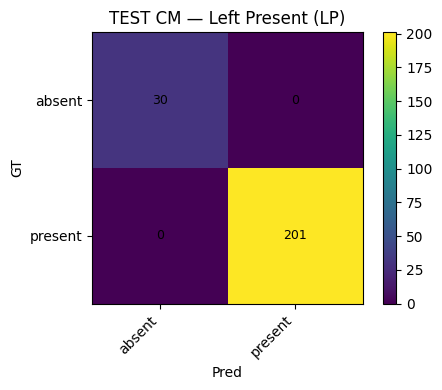

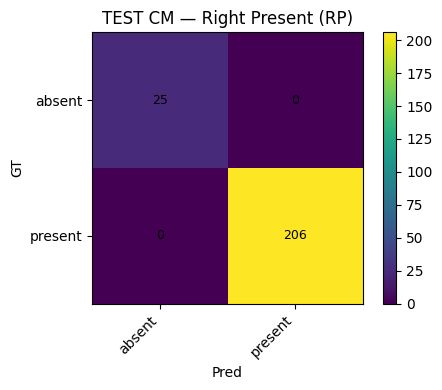

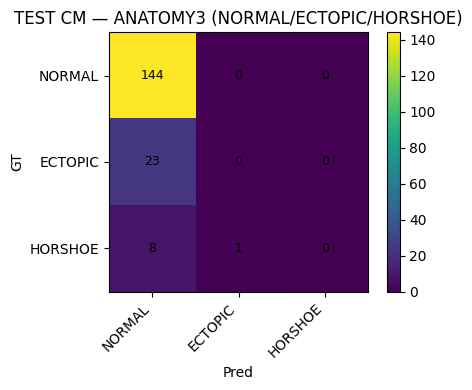

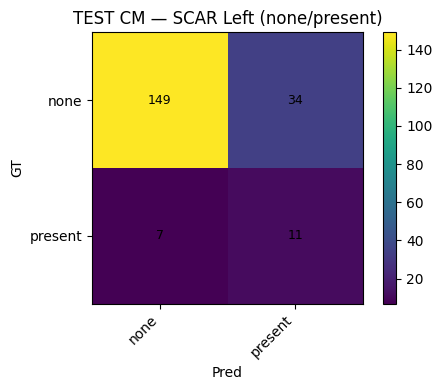

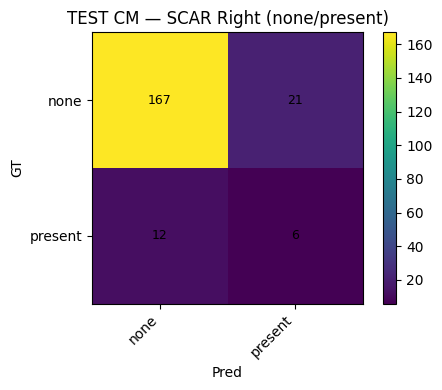

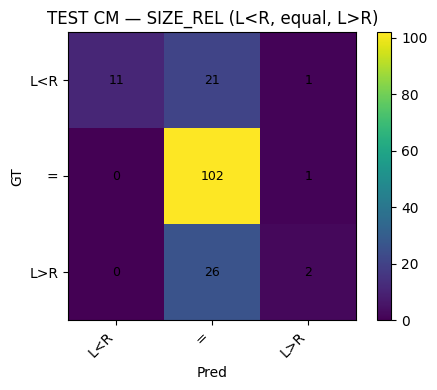

Counts (valid samples):
  ANAT3 valid: 176
  SCARL valid: 201 | SCARR valid: 206
  SIZE_REL valid: 164


In [53]:
# CELL 41 — Confusion matrices on TEST (LP, RP, Anatomy3 reconstructed, ScarL/ScarR, Size_rel)
# All ignore invalid (-1). Shows plots + prints counts.

def confusion_matrix_int(gt, pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for g, p in zip(gt, pred):
        if 0 <= g < n_classes and 0 <= p < n_classes:
            cm[g, p] += 1
    return cm

def plot_cm(cm, title, class_names):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Pred")
    plt.ylabel("GT")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def collect_test_preds(model, loader):
    model.eval()
    out_store = {k: [] for k in ["lp","rp","anat_abn","anat_sub","scarL","scarR","size_rel"]}
    gt_store  = {k: [] for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","SIZE_REL"]}
    extra_gt  = {"ANAT3": []}  # from df via idx

    pbar = tqdm(loader, desc="collect_test_preds", leave=False)
    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        for k in out_store.keys():
            out_store[k].append(out[k].detach().cpu())

        # gts
        for k in gt_store.keys():
            gt_store[k].append(to_targets(t, k).detach().cpu())

        # anatomy3 ground truth from df using idx
        idxs = t["idx"] if isinstance(t["idx"], list) else t["idx"].tolist()
        anat3 = df.loc[idxs, "__ANAT3__"].values.astype(int)
        extra_gt["ANAT3"].append(torch.tensor(anat3))

    # concat
    for k in out_store:
        out_store[k] = torch.cat(out_store[k], dim=0).numpy()
    for k in gt_store:
        gt_store[k] = torch.cat(gt_store[k], dim=0).numpy().astype(int)
    extra_gt["ANAT3"] = torch.cat(extra_gt["ANAT3"], dim=0).numpy().astype(int)

    return out_store, gt_store, extra_gt

pred_logits, gt, extra_gt = collect_test_preds(model, test_loader)

# --- LP / RP ---
lp_pred = pred_logits["lp"].argmax(axis=1)
rp_pred = pred_logits["rp"].argmax(axis=1)
cm_lp = confusion_matrix_int(gt["LP"], lp_pred, 2)
cm_rp = confusion_matrix_int(gt["RP"], rp_pred, 2)
plot_cm(cm_lp, "TEST CM — Left Present (LP)", ["absent","present"])
plot_cm(cm_rp, "TEST CM — Right Present (RP)", ["absent","present"])

# --- Anatomy 3-class reconstructed: if abn==0 => NORMAL else use sub (0=ECTOPIC,1=HORSHOE) ---
anat3_gt = extra_gt["ANAT3"]
anat3_pred = np.full_like(anat3_gt, fill_value=-1)

abn_pred = pred_logits["anat_abn"].argmax(axis=1)
sub_pred = pred_logits["anat_sub"].argmax(axis=1)

valid_anat3 = (anat3_gt >= 0)
anat3_pred[valid_anat3] = 0
anat3_pred[(valid_anat3) & (abn_pred == 1) & (sub_pred == 0)] = 1
anat3_pred[(valid_anat3) & (abn_pred == 1) & (sub_pred == 1)] = 2

cm_anat3 = confusion_matrix_int(anat3_gt[valid_anat3], anat3_pred[valid_anat3], 3)
plot_cm(cm_anat3, "TEST CM — ANATOMY3 (NORMAL/ECTOPIC/HORSHOE)", ["NORMAL","ECTOPIC","HORSHOE"])

# --- Scar L/R (binary) ---
valid_sL = (gt["SCARL_BIN"] >= 0)
valid_sR = (gt["SCARR_BIN"] >= 0)
sL_pred = pred_logits["scarL"].argmax(axis=1)
sR_pred = pred_logits["scarR"].argmax(axis=1)

cm_sL = confusion_matrix_int(gt["SCARL_BIN"][valid_sL], sL_pred[valid_sL], 2)
cm_sR = confusion_matrix_int(gt["SCARR_BIN"][valid_sR], sR_pred[valid_sR], 2)
plot_cm(cm_sL, "TEST CM — SCAR Left (none/present)", ["none","present"])
plot_cm(cm_sR, "TEST CM — SCAR Right (none/present)", ["none","present"])

# --- Size relation (3-class) ---
valid_rel = (gt["SIZE_REL"] >= 0)
rel_pred = pred_logits["size_rel"].argmax(axis=1)
cm_rel = confusion_matrix_int(gt["SIZE_REL"][valid_rel], rel_pred[valid_rel], 3)
plot_cm(cm_rel, "TEST CM — SIZE_REL (L<R, equal, L>R)", ["L<R","=","L>R"])

print("Counts (valid samples):")
print("  ANAT3 valid:", int(valid_anat3.sum()))
print("  SCARL valid:", int(valid_sL.sum()), "| SCARR valid:", int(valid_sR.sum()))
print("  SIZE_REL valid:", int(valid_rel.sum()))


In [55]:
# CELL 42 — Patient-level evaluation (weighted across views: P anchor) + correct validity gating + uptake threshold tuning (per-side)

import numpy as np
from tqdm import tqdm
import torch

# --- helpers ---
def f1_pos(gt, pr, pos_label=1):
    gt = np.asarray(gt).astype(int)
    pr = np.asarray(pr).astype(int)
    tp = int(((gt == pos_label) & (pr == pos_label)).sum())
    fp = int(((gt != pos_label) & (pr == pos_label)).sum())
    fn = int(((gt == pos_label) & (pr != pos_label)).sum())
    p = tp / (tp + fp + 1e-12)
    r = tp / (tp + fn + 1e-12)
    f1 = 2 * p * r / (p + r + 1e-12)
    return float(f1), float(p), float(r), tp, fp, fn

def best_thr_for_pos(y_true, y_prob, thr_grid=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    # ignore invalid
    m = y_true >= 0
    y_true = y_true[m]
    y_prob = y_prob[m]
    if len(y_true) == 0:
        return {"thr": 0.5, "F1": 0.0, "P": 0.0, "R": 0.0, "TP": 0, "FP": 0, "FN": 0, "N": 0}

    if thr_grid is None:
        thr_grid = np.linspace(0.05, 0.95, 19)

    best = None
    for thr in thr_grid:
        y_pred = (y_prob >= thr).astype(int)
        f1, p, r, tp, fp, fn = f1_pos(y_true, y_pred, pos_label=1)
        cand = {"thr": float(thr), "F1": f1, "P": p, "R": r, "TP": tp, "FP": fp, "FN": fn, "N": int(len(y_true))}
        if (best is None) or (cand["F1"] > best["F1"]):
            best = cand
    return best

def f1_macro_for_labels(gt, pr, labels):
    gt = np.asarray(gt).astype(int)
    pr = np.asarray(pr).astype(int)
    f1s = []
    for lab in labels:
        m = gt == lab
        if m.sum() == 0:
            continue
        tp = int(((gt == lab) & (pr == lab)).sum())
        fp = int(((gt != lab) & (pr == lab)).sum())
        fn = int(((gt == lab) & (pr != lab)).sum())
        p = tp / (tp + fp + 1e-12)
        r = tp / (tp + fn + 1e-12)
        f1 = 2 * p * r / (p + r + 1e-12)
        f1s.append(float(f1))
    return float(np.mean(f1s)) if len(f1s) else float("nan")

def acc_valid(gt, pr):
    gt = np.asarray(gt).astype(int)
    pr = np.asarray(pr).astype(int)
    m = gt >= 0
    if m.sum() == 0:
        return float("nan"), 0
    return float((gt[m] == pr[m]).mean()), int(m.sum())

def f1m_valid(gt, pr, labels):
    gt = np.asarray(gt).astype(int)
    pr = np.asarray(pr).astype(int)
    m = np.isin(gt, labels)
    if m.sum() == 0:
        return float("nan"), 0
    return f1_macro_for_labels(gt[m], pr[m], labels=labels), int(m.sum())

def _safe_view_list(batch_rows):
    if COL_VIEW is None:
        return [""] * len(batch_rows)
    return df.loc[batch_rows, COL_VIEW].astype(str).tolist()

def _weighted_mean_logits(rows_logits: np.ndarray, rows_views: list, pid_list: list):
    """rows_logits: [N, C], rows_views: N strings, pid_list: N strings"""
    uniq = []
    seen = set()
    for p in pid_list:
        if p not in seen:
            seen.add(p)
            uniq.append(p)

    out = np.zeros((len(uniq), rows_logits.shape[1]), dtype=np.float32)
    for i, pid in enumerate(uniq):
        idxs = [j for j, p in enumerate(pid_list) if p == pid]
        if len(idxs) == 1:
            out[i] = rows_logits[idxs[0]]
            continue

        w = np.array([view_weight(rows_views[j]) for j in idxs], dtype=np.float32)
        if float(w.sum()) <= 0:
            out[i] = rows_logits[idxs].mean(axis=0)
        else:
            out[i] = (rows_logits[idxs] * w[:, None]).sum(axis=0) / (w.sum() + 1e-12)
    return uniq, out

@torch.no_grad()
def eval_patient_level(loader, split_name="val"):
    model.eval()

    ds = loader.dataset
    if not hasattr(ds, "indices"):
        raise AttributeError("Expected loader.dataset to be a torch.utils.data.Subset with `.indices` for df mapping.")
    row_indices = ds.indices  # df row indices in fixed order (val/test are shuffle=False)

    # row-level accumulators
    pid_rows = []
    view_rows = []

    gt = {k: [] for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL","SCARR","UPL","UPR","SIZE_REL"]}
    logits = {k: [] for k in ["lp","rp","abn","sub","scarL","scarR","uptL","uptR","size"]}

    cursor = 0
    it = tqdm(loader, desc=f"collect {split_name}", leave=False)
    for I_ctx, I_L, I_R, t in it:
        bsz = int(I_ctx.shape[0])
        batch_rows = row_indices[cursor:cursor+bsz]
        cursor += bsz

        pid_rows.extend(df.loc[batch_rows, "__PATIENT_BASE__"].astype(str).tolist())
        view_rows.extend(_safe_view_list(batch_rows))

        # GT from t (already aligned with batch)
        gt["LP"].extend(t["LP"].numpy().tolist())
        gt["RP"].extend(t["RP"].numpy().tolist())
        gt["ANAT_ABN"].extend(t["ANAT_ABN"].numpy().tolist())
        gt["ANAT_SUB"].extend(t["ANAT_SUB"].numpy().tolist())
        gt["SCARL"].extend(t["SCARL_BIN"].numpy().tolist())
        gt["SCARR"].extend(t["SCARR_BIN"].numpy().tolist())
        gt["UPL"].extend(t["UPTAKEL_BIN"].numpy().tolist())
        gt["UPR"].extend(t["UPTAKER_BIN"].numpy().tolist())
        gt["SIZE_REL"].extend(t["SIZE_REL"].numpy().tolist())

        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)
        out = model(I_ctx, I_L, I_R)

        logits["lp"].append(out["lp"].detach().cpu().numpy())
        logits["rp"].append(out["rp"].detach().cpu().numpy())
        logits["abn"].append(out["anat_abn"].detach().cpu().numpy())
        logits["sub"].append(out["anat_sub"].detach().cpu().numpy())
        logits["scarL"].append(out["scarL"].detach().cpu().numpy())
        logits["scarR"].append(out["scarR"].detach().cpu().numpy())
        logits["uptL"].append(out["uptakeL"].detach().cpu().numpy())
        logits["uptR"].append(out["uptakeR"].detach().cpu().numpy())
        logits["size"].append(out["size_rel"].detach().cpu().numpy())

    # concat row logits
    for k in logits:
        logits[k] = np.concatenate(logits[k], axis=0)

    # weighted patient-level logits
    pid_uniq, lpL = _weighted_mean_logits(logits["lp"], view_rows, pid_rows)
    _,       rpL = _weighted_mean_logits(logits["rp"], view_rows, pid_rows)
    _,      abnL = _weighted_mean_logits(logits["abn"], view_rows, pid_rows)
    _,      subL = _weighted_mean_logits(logits["sub"], view_rows, pid_rows)
    _,    scarLL = _weighted_mean_logits(logits["scarL"], view_rows, pid_rows)
    _,    scarRL = _weighted_mean_logits(logits["scarR"], view_rows, pid_rows)
    _,     uptLL = _weighted_mean_logits(logits["uptL"], view_rows, pid_rows)
    _,     uptRL = _weighted_mean_logits(logits["uptR"], view_rows, pid_rows)
    _,     sizeL = _weighted_mean_logits(logits["size"], view_rows, pid_rows)

    # patient-level GT: first occurrence per patient (should be consistent across views)
    def first_per_patient(values):
        out = []
        seen = set()
        for pid, v in zip(pid_rows, values):
            if pid in seen:
                continue
            seen.add(pid)
            out.append(int(v))
        return np.array(out, dtype=int)

    LP_gt   = first_per_patient(gt["LP"])
    RP_gt   = first_per_patient(gt["RP"])
    ABN_gt  = first_per_patient(gt["ANAT_ABN"])
    SUB_gt  = first_per_patient(gt["ANAT_SUB"])
    SCARL_gt= first_per_patient(gt["SCARL"])
    SCARR_gt= first_per_patient(gt["SCARR"])
    UPTL_gt = first_per_patient(gt["UPL"])
    UPTR_gt = first_per_patient(gt["UPR"])
    SIZE_gt = first_per_patient(gt["SIZE_REL"])

    # predictions
    LP_pr   = lpL.argmax(1).astype(int)
    RP_pr   = rpL.argmax(1).astype(int)
    ABN_pr  = abnL.argmax(1).astype(int)
    SUB_pr  = subL.argmax(1).astype(int)
    SIZE_pr = sizeL.argmax(1).astype(int)

    # count from LP/RP
    COUNT_gt = (LP_gt + RP_gt).astype(int)
    COUNT_pr = (LP_pr + RP_pr).astype(int)

    # probs for scar/uptake (class=1)
    scarL_prob = torch.softmax(torch.tensor(scarLL), dim=1).numpy()[:, 1]
    scarR_prob = torch.softmax(torch.tensor(scarRL), dim=1).numpy()[:, 1]
    uptL_prob  = torch.softmax(torch.tensor(uptLL),  dim=1).numpy()[:, 1]
    uptR_prob  = torch.softmax(torch.tensor(uptRL),  dim=1).numpy()[:, 1]

    # ----- Anatomy gated reconstruction (agreement) -----
    # GT anatomy4: 0 SINGLE, 1 NORMAL, 2 ECTOPIC, 3 HORSHOE
    ANAT4_gt = np.full(len(pid_uniq), -1, dtype=int)
    ANAT4_gt[COUNT_gt == 1] = 0
    m2 = COUNT_gt == 2
    # Only valid if ABN_gt is known (0/1)
    ANAT4_gt[m2 & (ABN_gt == 0)] = 1
    ANAT4_gt[m2 & (ABN_gt == 1) & (SUB_gt == 0)] = 2
    ANAT4_gt[m2 & (ABN_gt == 1) & (SUB_gt == 1)] = 3

    # Pred anatomy4 using gated logic
    ANAT4_pr = np.full(len(pid_uniq), -1, dtype=int)
    ANAT4_pr[COUNT_pr == 1] = 0  # SINGLE rule
    mp2 = COUNT_pr == 2
    ANAT4_pr[mp2 & (ABN_pr == 0)] = 1
    ANAT4_pr[mp2 & (ABN_pr == 1) & (SUB_pr == 0)] = 2
    ANAT4_pr[mp2 & (ABN_pr == 1) & (SUB_pr == 1)] = 3

    # ----- Metrics (validity-aware) -----
    out = {"n_pat": int(len(pid_uniq))}

    out["LP_acc"], n_lp = acc_valid(LP_gt, LP_pr)
    out["RP_acc"], n_rp = acc_valid(RP_gt, RP_pr)

    out["count_acc"], n_cnt = acc_valid(COUNT_gt, COUNT_pr)
    out["count_f1m_12"], _ = f1m_valid(COUNT_gt, COUNT_pr, labels=[1, 2])  # correct for this dataset

    # Anatomy ABN/Sub are ONLY meaningful when GT count==2 and labels are valid
    m_abn = (COUNT_gt == 2) & (ABN_gt >= 0)
    out["anat_abn_acc"] = float((ABN_gt[m_abn] == ABN_pr[m_abn]).mean()) if m_abn.sum() else float("nan")
    out["anat_abn_f1m"] = f1_macro_for_labels(ABN_gt[m_abn], ABN_pr[m_abn], labels=[0, 1]) if m_abn.sum() else float("nan")
    out["anat_abn_n"]   = int(m_abn.sum())

    # SUB is valid only where GT abnormal (SUB_gt >=0). (agreement)
    m_sub = (COUNT_gt == 2) & (SUB_gt >= 0)
    out["anat_sub_acc"] = float((SUB_gt[m_sub] == SUB_pr[m_sub]).mean()) if m_sub.sum() else float("nan")
    out["anat_sub_f1m"] = f1_macro_for_labels(SUB_gt[m_sub], SUB_pr[m_sub], labels=[0, 1]) if m_sub.sum() else float("nan")
    out["anat_sub_n"]   = int(m_sub.sum())

    # Final gated anatomy-4 evaluation (only where GT anatomy is valid)
    m_anat4 = ANAT4_gt >= 0
    out["anat4_acc"] = float((ANAT4_gt[m_anat4] == ANAT4_pr[m_anat4]).mean()) if m_anat4.sum() else float("nan")
    out["anat4_f1m"] = f1_macro_for_labels(ANAT4_gt[m_anat4], ANAT4_pr[m_anat4], labels=[0,1,2,3]) if m_anat4.sum() else float("nan")
    out["anat4_n"]   = int(m_anat4.sum())

    # Size relation (valid only where gt available)
    out["size_rel_acc"], n_sz = acc_valid(SIZE_gt, SIZE_pr)
    out["size_rel_f1m"], _ = f1m_valid(SIZE_gt, SIZE_pr, labels=[0, 1, 2])
    out["size_rel_n"] = int(n_sz)

    # Scar quick @0.5 (valid per-side only)
    m_sL = SCARL_gt >= 0
    m_sR = SCARR_gt >= 0
    if m_sL.sum():
        out["scarL_f1_pos_05"], out["scarL_p_05"], out["scarL_r_05"], *_ = f1_pos(SCARL_gt[m_sL], (scarL_prob[m_sL] >= 0.5).astype(int))
    else:
        out["scarL_f1_pos_05"]=out["scarL_p_05"]=out["scarL_r_05"]=float("nan")
    if m_sR.sum():
        out["scarR_f1_pos_05"], out["scarR_p_05"], out["scarR_r_05"], *_ = f1_pos(SCARR_gt[m_sR], (scarR_prob[m_sR] >= 0.5).astype(int))
    else:
        out["scarR_f1_pos_05"]=out["scarR_p_05"]=out["scarR_r_05"]=float("nan")

    # Uptake quick @0.5 (valid per-side only)
    m_uL = UPTL_gt >= 0
    m_uR = UPTR_gt >= 0
    if m_uL.sum():
        out["uptakeL_f1_pos_05"], out["uptakeL_p_05"], out["uptakeL_r_05"], *_ = f1_pos(UPTL_gt[m_uL], (uptL_prob[m_uL] >= 0.5).astype(int))
    else:
        out["uptakeL_f1_pos_05"]=out["uptakeL_p_05"]=out["uptakeL_r_05"]=float("nan")
    if m_uR.sum():
        out["uptakeR_f1_pos_05"], out["uptakeR_p_05"], out["uptakeR_r_05"], *_ = f1_pos(UPTR_gt[m_uR], (uptR_prob[m_uR] >= 0.5).astype(int))
    else:
        out["uptakeR_f1_pos_05"]=out["uptakeR_p_05"]=out["uptakeR_r_05"]=float("nan")

    # Return extra for threshold tuning
    out_extra = {
        "pid": np.array(pid_uniq, dtype=object),

        "uptL_prob": uptL_prob, "uptR_prob": uptR_prob,
        "uptL_gt": UPTL_gt,     "uptR_gt": UPTR_gt,

        "scarL_prob": scarL_prob, "scarR_prob": scarR_prob,
        "scarL_gt": SCARL_gt,     "scarR_gt": SCARR_gt,
    }
    return out, out_extra

# --- Run patient-level eval for VAL/TEST ---
pat_val,  extra_val  = eval_patient_level(val_loader,  split_name="val")
pat_test, extra_test = eval_patient_level(test_loader, split_name="test")

def _round_dict(d):
    out = {}
    for k,v in d.items():
        if isinstance(v, float):
            out[k] = (None if np.isnan(v) else round(v, 4))
        else:
            out[k] = v
    return out

print("✅ Patient-level aggregated:", {"val": pat_val["n_pat"], "test": pat_test["n_pat"]})
print("VAL metrics:", _round_dict({k:v for k,v in pat_val.items() if k != "n_pat"}))
print("TEST metrics:", _round_dict({k:v for k,v in pat_test.items() if k != "n_pat"}))

# --- Uptake threshold tuning on VAL (per-side), then apply to TEST (agreement) ---
best_uptL = best_thr_for_pos(extra_val["uptL_gt"], extra_val["uptL_prob"])
best_uptR = best_thr_for_pos(extra_val["uptR_gt"], extra_val["uptR_prob"])
thrL = float(best_uptL["thr"])
thrR = float(best_uptR["thr"])

print("\n✅ Best VAL thresholds — Uptake:")
print("  UptakeL:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in best_uptL.items()})
print("  UptakeR:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in best_uptR.items()})

# Apply tuned thresholds to TEST and report side + ANY (only on valid patients)
def eval_uptake_with_thr(extra, thrL, thrR):
    gtL = np.asarray(extra["uptL_gt"]).astype(int)
    gtR = np.asarray(extra["uptR_gt"]).astype(int)
    pL  = np.asarray(extra["uptL_prob"]).astype(float)
    pR  = np.asarray(extra["uptR_prob"]).astype(float)

    mL = gtL >= 0
    mR = gtR >= 0

    res = {}

    if mL.sum():
        prL = (pL[mL] >= thrL).astype(int)
        res["uptakeL_f1"] , res["uptakeL_p"], res["uptakeL_r"], *_ = f1_pos(gtL[mL], prL)
        res["uptakeL_n"] = int(mL.sum())
    else:
        res["uptakeL_f1"]=res["uptakeL_p"]=res["uptakeL_r"]=float("nan")
        res["uptakeL_n"]=0

    if mR.sum():
        prR = (pR[mR] >= thrR).astype(int)
        res["uptakeR_f1"] , res["uptakeR_p"], res["uptakeR_r"], *_ = f1_pos(gtR[mR], prR)
        res["uptakeR_n"] = int(mR.sum())
    else:
        res["uptakeR_f1"]=res["uptakeR_p"]=res["uptakeR_r"]=float("nan")
        res["uptakeR_n"]=0

    # ANY: only for patients where at least one side has a valid GT
    m_any = (gtL >= 0) | (gtR >= 0)
    if m_any.sum():
        any_gt = ((gtL[m_any] == 1) | (gtR[m_any] == 1)).astype(int)
        any_pr = ((pL[m_any] >= thrL) | (pR[m_any] >= thrR)).astype(int)
        res["uptakeAny_f1"], res["uptakeAny_p"], res["uptakeAny_r"], *_ = f1_pos(any_gt, any_pr)
        res["uptakeAny_n"] = int(m_any.sum())
    else:
        res["uptakeAny_f1"]=res["uptakeAny_p"]=res["uptakeAny_r"]=float("nan")
        res["uptakeAny_n"]=0

    return res

test_upt = eval_uptake_with_thr(extra_test, thrL, thrR)
print("\nTEST Uptake @ tuned thresholds:")
print(_round_dict(test_upt))

✅ Patient-level aggregated: {'val': 76, 'test': 76}
VAL metrics: {'LP_acc': 1.0, 'RP_acc': 1.0, 'count_acc': 1.0, 'count_f1m_12': 1.0, 'anat_abn_acc': 0.6447, 'anat_abn_f1m': 0.392, 'anat_sub_acc': 0.0526, 'anat_sub_f1m': 0.0519, 'size_rel_acc': 0.4474, 'size_rel_f1m': 0.4006, 'scarL_f1_pos_05': 0.2353, 'scarL_p_05': 0.1667, 'scarL_r_05': 0.4, 'scarR_f1_pos_05': 0.1667, 'scarR_p_05': 0.125, 'scarR_r_05': 0.25, 'uptakeL_f1_pos_05': 0.7619, 'uptakeL_p_05': 0.6667, 'uptakeL_r_05': 0.8889, 'uptakeR_f1_pos_05': 0.4944, 'uptakeR_p_05': 0.3333, 'uptakeR_r_05': 0.9565, 'uptake_any_f1_05': 0.6214, 'uptake_any_p_05': 0.4507, 'uptake_any_r_05': 1.0}
TEST metrics: {'LP_acc': 1.0, 'RP_acc': 1.0, 'count_acc': 1.0, 'count_f1m_12': 1.0, 'anat_abn_acc': 0.6316, 'anat_abn_f1m': 0.3871, 'anat_sub_acc': 0.0921, 'anat_sub_f1m': 0.0854, 'size_rel_acc': 0.5, 'size_rel_f1m': 0.3916, 'scarL_f1_pos_05': 0.381, 'scarL_p_05': 0.2667, 'scarL_r_05': 0.6667, 'scarR_f1_pos_05': 0.2667, 'scarR_p_05': 0.2222, 'scarR_r_

In [56]:
# CELL 43 — OPTIONAL: Save FINAL model (off by default)
# You said this is a separate notebook and the previous one is already saved.
# So: SAVE_FINAL = False by default.

from pathlib import Path
import torch

SAVE_FINAL = False  # <-- set True only if you want to save the final weights

if SAVE_FINAL:
    if "BASE_DIR" not in globals():
        BASE_DIR = Path(r"D:\base")

    CKPT_DIR = BASE_DIR / "checkpoints"
    CKPT_DIR.mkdir(parents=True, exist_ok=True)

    ckpt_path = CKPT_DIR / f"model_final_patientK{K_VIEWS}_{BACKBONE_NAME}.pt"

    save_obj = {
        "backbone": BACKBONE_NAME,
        "pretrained": PRETRAINED,
        "model_state": model.state_dict(),
        "config": {
            "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY, "EPOCHS": EPOCHS,
            "P_LO": P_LO, "P_HI": P_HI,
            "K_VIEWS": K_VIEWS, "PATIENT_BATCH_SIZE": PATIENT_BATCH_SIZE,
            "VIEW_W": VIEW_W,
            "W_BASE": W_BASE, "W_HORSHOE": W_HORSHOE, "W_SCAR_PRESENT": W_SCAR_PRESENT, "W_CAP": W_CAP,
        },
        "history": hist_df.to_dict(orient="list") if "hist_df" in globals() else None,
    }

    torch.save(save_obj, ckpt_path)
    print("✅ Saved final model:", ckpt_path)
else:
    print("SAVE_FINAL=False → skipping save.")


✅ Saved checkpoint: D:\base\checkpoints\model_final_inception_v3.pt


In [57]:
# CELL 44 — FULL REPLACEMENT: Write compact run report (row-level + patient-level), now includes Uptake
from pathlib import Path
import json

results_dir = Path(BASE_DIR) / "results"
results_dir.mkdir(parents=True, exist_ok=True)

report_path = results_dir / "run_report.txt"

def _fmt(x):
    if isinstance(x, (int,)):
        return str(x)
    if isinstance(x, float):
        return f"{x:.4f}"
    return str(x)

lines = []
lines.append("=== RUN REPORT (latest) ===\n")

lines.append("== ROW-LEVEL (from run_eval on TEST) ==\n")
# 'test_metrics' is produced in your training/eval cells. If not, we'll skip safely.
if "test_metrics" in globals():
    for k in sorted(test_metrics.keys()):
        lines.append(f"{k}: {_fmt(test_metrics[k])}\n")
else:
    lines.append("test_metrics not found (did you run CELL 39/41 eval that sets it?)\n")

lines.append("\n== PATIENT-LEVEL (avg logits across views) ==\n")
if "pat_test" in globals():
    keys_order = [
        "count_acc","count_f1m_12",
        "LP_acc","RP_acc",
        "anat_abn_acc","anat_abn_f1m","anat_sub_acc","anat_sub_f1m",
        "scarL_f1_pos_05","scarL_p_05","scarL_r_05","scarR_f1_pos_05","scarR_p_05","scarR_r_05",
        "uptakeL_f1_pos_05","uptakeL_p_05","uptakeL_r_05","uptakeR_f1_pos_05","uptakeR_p_05","uptakeR_r_05",
        "uptake_any_f1_05","uptake_any_p_05","uptake_any_r_05",
        "thrUptL","thrUptR","uptakeL_f1","uptakeL_p","uptakeL_r","uptakeR_f1","uptakeR_p","uptakeR_r","uptake_any_f1","uptake_any_p","uptake_any_r",
        "size_rel_acc","size_rel_f1m",
    ]
    lines.append(f"n_pat: {pat_test.get('n_pat','?')}\n")
    for k in keys_order:
        if k in pat_test:
            lines.append(f"{k}: {_fmt(pat_test[k])}\n")
else:
    lines.append("pat_test not found (run CELL 42).\n")

report_path.write_text("".join(lines), encoding="utf-8")
print("✅ Saved:", str(report_path))


✅ Saved: D:\base\results\run_report.txt


In [58]:
# CELL 45 — Collect SCAR logits on VAL/TEST (row-level) and aggregate to PATIENT-level (VIEW-weighted: P anchor)

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn.functional as F

# --- paths ---
if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")
OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _to_numpy_idxs(x):
    # t["idx"] might be list or tensor
    if isinstance(x, list):
        return np.array(x, dtype=int)
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(int)
    return np.array(x, dtype=int)

def _get_view_for_idxs(idxs):
    if COL_VIEW is None:
        return [""] * len(idxs)
    return df.loc[idxs, COL_VIEW].astype(str).tolist()

# Fallback if CELL 10 wasn't run for some reason
if "view_weight" not in globals():
    def view_weight(v):  # noqa: F811
        return 1.0

@torch.no_grad()
def collect_scar_logits_df(model, loader, split_name: str):
    '''
    Returns a dataframe with one row per *view* (row-level), containing:
      idx, patient_base, view, scarL_logits(2), scarR_logits(2), scarL_gt, scarR_gt
    '''
    model.eval()
    rows = []
    pbar = tqdm(loader, desc=f"collect_scar_logits_{split_name}", leave=False)

    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        sL = out["scarL"].detach().cpu().numpy()
        sR = out["scarR"].detach().cpu().numpy()

        gtL = to_targets(t, "SCARL_BIN").detach().cpu().numpy().astype(int)
        gtR = to_targets(t, "SCARR_BIN").detach().cpu().numpy().astype(int)

        idxs = _to_numpy_idxs(t["idx"])
        pids = df.loc[idxs, "__PATIENT_BASE__"].astype(str).tolist()
        views = _get_view_for_idxs(idxs)

        for i in range(len(idxs)):
            rows.append({
                "split": split_name,
                "idx": int(idxs[i]),
                "patient_base": pids[i],
                "view": views[i],
                "w_view": float(view_weight(views[i])),
                "scarL_logit0": float(sL[i, 0]),
                "scarL_logit1": float(sL[i, 1]),
                "scarR_logit0": float(sR[i, 0]),
                "scarR_logit1": float(sR[i, 1]),
                "scarL_gt": int(gtL[i]),
                "scarR_gt": int(gtR[i]),
            })

    return pd.DataFrame(rows)

def aggregate_patient_level_scar(row_df: pd.DataFrame):
    '''
    Patient-level aggregation:
      - Weighted mean of logits across views (P anchor / obliques supporting)
      - Convert to prob via softmax on aggregated logits
      - Keep GT as first non-negative per patient (assumed consistent)
    '''
    out_rows = []
    for pid, g in row_df.groupby("patient_base", sort=False):
        g = g.reset_index(drop=True)

        w = g["w_view"].to_numpy(dtype=np.float32)
        if float(w.sum()) <= 0:
            w = np.ones(len(g), dtype=np.float32)

        def wmean(col0, col1):
            a0 = g[col0].to_numpy(dtype=np.float32)
            a1 = g[col1].to_numpy(dtype=np.float32)
            m0 = float((a0 * w).sum() / (w.sum() + 1e-12))
            m1 = float((a1 * w).sum() / (w.sum() + 1e-12))
            return np.array([m0, m1], dtype=np.float32)

        L = wmean("scarL_logit0", "scarL_logit1")
        R = wmean("scarR_logit0", "scarR_logit1")

        pL = float(torch.softmax(torch.tensor(L), dim=0).numpy()[1])
        pR = float(torch.softmax(torch.tensor(R), dim=0).numpy()[1])

        gtL_list = g["scarL_gt"].to_list()
        gtR_list = g["scarR_gt"].to_list()
        gtL = next((int(x) for x in gtL_list if int(x) >= 0), int(gtL_list[0]))
        gtR = next((int(x) for x in gtR_list if int(x) >= 0), int(gtR_list[0]))

        out_rows.append({
            "patient_base": pid,
            "scarL_prob": pL,
            "scarR_prob": pR,
            "scarL_gt": int(gtL),
            "scarR_gt": int(gtR),
            "n_views": int(len(g)),
        })

    return pd.DataFrame(out_rows)

# ---- run collection ----
val_row_df  = collect_scar_logits_df(model, val_loader,  "val")
test_row_df = collect_scar_logits_df(model, test_loader, "test")

val_pat_df  = aggregate_patient_level_scar(val_row_df)
test_pat_df = aggregate_patient_level_scar(test_row_df)

print("=== PROOF: row_df sizes ===")
print("val_row_df:", len(val_row_df), "| test_row_df:", len(test_row_df))
print("=== PROOF: patient_df sizes ===")
print("val_pat_df:", len(val_pat_df), "| test_pat_df:", len(test_pat_df))

# save for reproducibility
val_row_df.to_csv(OUT_DIR / "scar_row_val.csv", index=False)
test_row_df.to_csv(OUT_DIR / "scar_row_test.csv", index=False)
val_pat_df.to_csv(OUT_DIR / "scar_patient_val.csv", index=False)
test_pat_df.to_csv(OUT_DIR / "scar_patient_test.csv", index=False)

print("Saved to:", str(OUT_DIR))

Row-level collected: {'val': 229, 'test': 231}
Patient-level aggregated: {'val': 76, 'test': 76}
✅ Saved scar logits/probs CSVs to: D:\base\results


In [59]:
# CELL 46 — SCAR threshold tuning on VAL (per-side) using PATIENT-level probs (VIEW-weighted aggregation already applied)

import numpy as np

def _best_thr_binary(y_true, y_prob, thr_grid=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    m = y_true >= 0
    y_true = y_true[m]
    y_prob = y_prob[m]
    if len(y_true) == 0:
        return {"thr": 0.5, "F1": 0.0, "P": 0.0, "R": 0.0, "TP": 0, "FP": 0, "FN": 0, "N": 0}

    if thr_grid is None:
        thr_grid = np.linspace(0.05, 0.95, 19)

    best = None
    for thr in thr_grid:
        y_pred = (y_prob >= thr).astype(int)
        f1, p, r, tp, fp, fn = f1_pos(y_true, y_pred, pos_label=1)
        cand = {"thr": float(thr), "F1": float(f1), "P": float(p), "R": float(r), "TP": int(tp), "FP": int(fp), "FN": int(fn), "N": int(len(y_true))}
        if (best is None) or (cand["F1"] > best["F1"]):
            best = cand
    return best

# --- hard checks ---
if "val_pat_df" not in globals():
    raise NameError("Run CELL 45 first (it builds val_pat_df/test_pat_df).")

best_scarL = _best_thr_binary(val_pat_df["scarL_gt"], val_pat_df["scarL_prob"])
best_scarR = _best_thr_binary(val_pat_df["scarR_gt"], val_pat_df["scarR_prob"])

thr_scarL = float(best_scarL["thr"])
thr_scarR = float(best_scarR["thr"])

print("✅ Best VAL thresholds — SCAR (per-side):")
print("  scarL:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in best_scarL.items()})
print("  scarR:", {k: (round(v,4) if isinstance(v,float) else v) for k,v in best_scarR.items()})

,thr,F1_any,P_any,R_any,F1_L,P_L,R_L,F1_R,P_R,R_R,F1_mean_LR,n_pat_any,n_side_L,n_side_R
0,0.10,0.333333,0.222222,0.666667,0.421053,0.285714,0.8,0.250000,0.166667,0.50,0.335526,76,67,63
1,0.11,0.333333,0.222222,0.666667,0.421053,0.285714,0.8,0.250000,0.166667,0.50,0.335526,76,67,63
2,0.09,0.320000,0.210526,0.666667,0.421053,0.285714,0.8,0.235294,0.153846,0.50,0.328173,76,67,63
3,0.30,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.181818,0.142857,0.25,0.278409,76,67,63
4,0.26,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.166667,0.125000,0.25,0.270833,76,67,63
5,0.27,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.166667,0.125000,0.25,0.270833,76,67,63
6,0.28,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.166667,0.125000,0.25,0.270833,76,67,63
7,0.29,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.166667,0.125000,0.25,0.270833,76,67,63
8,0.25,0.315789,0.230769,0.500000,0.375000,0.272727,0.6,0.153846,0.111111,0.25,0.264423,76,67,63
9,0.08,0.307692,0.200000,0.666667,0.400000,0.266667,0.8,0.222222,0.142857,0.50,0.311111,76,67,63



✅ Best threshold on VAL (patient-level):
{'thr': 0.1, 'F1_any': 0.3333, 'P_any': 0.2222, 'R_any': 0.6667, 'F1_L': 0.4211, 'P_L': 0.2857, 'R_L': 0.8, 'F1_R': 0.25, 'P_R': 0.1667, 'R_R': 0.5, 'F1_mean_LR': 0.3355, 'n_pat_any': 76.0, 'n_side_L': 67.0, 'n_side_R': 63.0}
✅ Saved threshold sweep CSV: D:\base\results\scar_val_threshold_sweep.csv


In [60]:
# CELL 47 — Apply tuned SCAR thresholds to TEST (per-side + ANY)

import numpy as np

if "test_pat_df" not in globals():
    raise NameError("Run CELL 45 first (it builds test_pat_df).")
if "thr_scarL" not in globals() or "thr_scarR" not in globals():
    raise NameError("Run CELL 46 first (it tunes thr_scarL/thr_scarR).")

def _eval_scar_with_thr(pat_df, thrL, thrR):
    gtL = np.asarray(pat_df["scarL_gt"]).astype(int)
    gtR = np.asarray(pat_df["scarR_gt"]).astype(int)
    pL  = np.asarray(pat_df["scarL_prob"]).astype(float)
    pR  = np.asarray(pat_df["scarR_prob"]).astype(float)

    mL = gtL >= 0
    mR = gtR >= 0

    res = {}

    if mL.sum():
        prL = (pL[mL] >= thrL).astype(int)
        res["scarL_f1"], res["scarL_p"], res["scarL_r"], *_ = f1_pos(gtL[mL], prL)
        res["scarL_n"] = int(mL.sum())
    else:
        res["scarL_f1"]=res["scarL_p"]=res["scarL_r"]=float("nan")
        res["scarL_n"]=0

    if mR.sum():
        prR = (pR[mR] >= thrR).astype(int)
        res["scarR_f1"], res["scarR_p"], res["scarR_r"], *_ = f1_pos(gtR[mR], prR)
        res["scarR_n"] = int(mR.sum())
    else:
        res["scarR_f1"]=res["scarR_p"]=res["scarR_r"]=float("nan")
        res["scarR_n"]=0

    # ANY: only for patients where at least one side has valid GT
    m_any = (gtL >= 0) | (gtR >= 0)
    if m_any.sum():
        any_gt = ((gtL[m_any] == 1) | (gtR[m_any] == 1)).astype(int)
        any_pr = ((pL[m_any] >= thrL) | (pR[m_any] >= thrR)).astype(int)
        res["scarAny_f1"], res["scarAny_p"], res["scarAny_r"], *_ = f1_pos(any_gt, any_pr)
        res["scarAny_n"] = int(m_any.sum())
    else:
        res["scarAny_f1"]=res["scarAny_p"]=res["scarAny_r"]=float("nan")
        res["scarAny_n"]=0

    return res

test_scar = _eval_scar_with_thr(test_pat_df, thr_scarL, thr_scarR)
print("TEST SCAR @ tuned thresholds:")
print({k: (round(v,4) if isinstance(v,float) and not np.isnan(v) else v) for k,v in test_scar.items()})

Using threshold: 0.09999999999999999

TEST @ chosen threshold:
{'thr': 0.1, 'F1_any': 0.4138, 'P_any': 0.2857, 'R_any': 0.75, 'F1_L': 0.4167, 'P_L': 0.2778, 'R_L': 0.8333, 'F1_R': 0.2727, 'P_R': 0.1875, 'R_R': 0.5, 'F1_mean_LR': 0.3447, 'n_pat_any': 76, 'n_side_L': 67, 'n_side_R': 63}

Confusion Matrices (rows=GT, cols=Pred):
SCAR_ANY:
 [[53 15]
 [ 2  6]]
SCAR_L:
 [[47 13]
 [ 1  5]]
SCAR_R:
 [[49 13]
 [ 3  3]]

✅ Saved: D:\base\results\scar_threshold_report.txt


In [61]:
# CELL 48 — Separate thresholds for SCAR_L and SCAR_R (VAL-max-F1), then apply to TEST (patient-level)
# Uses: val_pat_df, test_pat_df already created in previous cells.

import numpy as np
import pandas as pd

def f1_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn

def best_threshold_for_side(p, y, ths):
    best = None
    for thr in ths:
        yhat = (p >= thr).astype(int)
        f1, pr, rc, tp, fp, fn = f1_binary(y, yhat)
        row = {"thr": float(thr), "F1": float(f1), "P": float(pr), "R": float(rc), "TP": tp, "FP": fp, "FN": fn, "N": int(len(y))}
        if (best is None) or (row["F1"] > best["F1"]) or (row["F1"] == best["F1"] and row["P"] > best["P"]):
            best = row
    return best

def cm2(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = np.zeros((2,2), dtype=int)
    for g,p in zip(y_true, y_pred):
        cm[g,p] += 1
    return cm

# --- threshold grid ---
ths = np.linspace(0.05, 0.95, 91)

# --- VAL: find best thrL and thrR independently ---
validL_val = val_pat_df["scarL_gt"].values >= 0
validR_val = val_pat_df["scarR_gt"].values >= 0

yL_val = val_pat_df.loc[validL_val, "scarL_gt"].values.astype(int)
pL_val = val_pat_df.loc[validL_val, "scarL_prob"].values.astype(float)

yR_val = val_pat_df.loc[validR_val, "scarR_gt"].values.astype(int)
pR_val = val_pat_df.loc[validR_val, "scarR_prob"].values.astype(float)

bestL = best_threshold_for_side(pL_val, yL_val, ths)
bestR = best_threshold_for_side(pR_val, yR_val, ths)

thrL = bestL["thr"]
thrR = bestR["thr"]

print("✅ Best VAL threshold — LEFT (maximize F1_L):", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bestL.items()})
print("✅ Best VAL threshold — RIGHT (maximize F1_R):", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bestR.items()})
print("\nUsing separate thresholds:", {"thrL": thrL, "thrR": thrR})

# --- TEST evaluation with separate thresholds ---
validL_test = test_pat_df["scarL_gt"].values >= 0
validR_test = test_pat_df["scarR_gt"].values >= 0

yL_test = test_pat_df.loc[validL_test, "scarL_gt"].values.astype(int)
pL_test = test_pat_df.loc[validL_test, "scarL_prob"].values.astype(float)
yL_hat  = (pL_test >= thrL).astype(int)
f1L, pLpr, rL, tpL, fpL, fnL = f1_binary(yL_test, yL_hat) if len(yL_test) else (None, None, None, 0, 0, 0)

yR_test = test_pat_df.loc[validR_test, "scarR_gt"].values.astype(int)
pR_test = test_pat_df.loc[validR_test, "scarR_prob"].values.astype(float)
yR_hat  = (pR_test >= thrR).astype(int)
f1R, pRpr, rR, tpR, fpR, fnR = f1_binary(yR_test, yR_hat) if len(yR_test) else (None, None, None, 0, 0, 0)

# ANY (patient-level) using OR with separate thresholds
any_gt, any_pr = [], []
for _, row in test_pat_df.iterrows():
    gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
    vL = (gtL >= 0); vR = (gtR >= 0)
    if not (vL or vR):
        continue
    gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
    pr_any = int((row["scarL_prob"] >= thrL) if vL else 0) or int((row["scarR_prob"] >= thrR) if vR else 0)
    any_gt.append(int(gt_any))
    any_pr.append(int(pr_any))

f1A, pApr, rA, tpA, fpA, fnA = f1_binary(any_gt, any_pr) if len(any_gt) else (None, None, None, 0, 0, 0)

# Confusion matrices
cm_any = cm2(any_gt, any_pr) if len(any_gt) else None
cm_L   = cm2(yL_test, yL_hat) if len(yL_test) else None
cm_R   = cm2(yR_test, yR_hat) if len(yR_test) else None

print("\nTEST (patient-level) with separate thresholds:")
print({
    "thrL": round(thrL,4), "thrR": round(thrR,4),
    "F1_any": None if f1A is None else round(float(f1A),4),
    "P_any":  None if pApr is None else round(float(pApr),4),
    "R_any":  None if rA is None else round(float(rA),4),
    "F1_L":   None if f1L is None else round(float(f1L),4),
    "P_L":    None if pLpr is None else round(float(pLpr),4),
    "R_L":    None if rL is None else round(float(rL),4),
    "F1_R":   None if f1R is None else round(float(f1R),4),
    "P_R":    None if pRpr is None else round(float(pRpr),4),
    "R_R":    None if rR is None else round(float(rR),4),
    "n_pat_any": int(len(any_gt)),
    "n_side_L": int(validL_test.sum()),
    "n_side_R": int(validR_test.sum()),
})

print("\nConfusion Matrices (rows=GT, cols=Pred):")
print("SCAR_ANY:\n", cm_any)
print("SCAR_L:\n", cm_L)
print("SCAR_R:\n", cm_R)


✅ Best VAL threshold — LEFT (maximize F1_L): {'thr': 0.09, 'F1': 0.4211, 'P': 0.2857, 'R': 0.8, 'TP': 4, 'FP': 10, 'FN': 1, 'N': 67}
✅ Best VAL threshold — RIGHT (maximize F1_R): {'thr': 0.95, 'F1': 0.3333, 'P': 0.5, 'R': 0.25, 'TP': 1, 'FP': 1, 'FN': 3, 'N': 63}

Using separate thresholds: {'thrL': 0.09, 'thrR': 0.95}

TEST (patient-level) with separate thresholds:
{'thrL': 0.09, 'thrR': 0.95, 'F1_any': 0.3846, 'P_any': 0.2778, 'R_any': 0.625, 'F1_L': 0.4167, 'P_L': 0.2778, 'R_L': 0.8333, 'F1_R': 0.0, 'P_R': 0.0, 'R_R': 0.0, 'n_pat_any': 76, 'n_side_L': 66, 'n_side_R': 68}

Confusion Matrices (rows=GT, cols=Pred):
SCAR_ANY:
 [[55 13]
 [ 3  5]]
SCAR_L:
 [[47 13]
 [ 1  5]]
SCAR_R:
 [[61  1]
 [ 6  0]]


✅ Saved: D:\base\results\cm_scar_any_patient.png


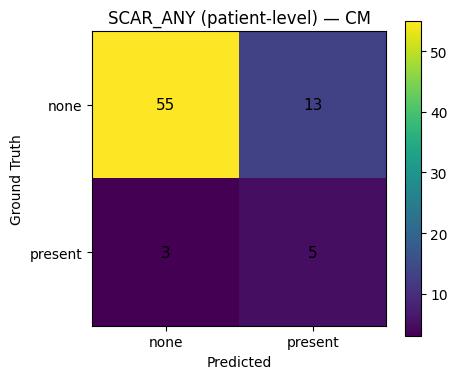

✅ Saved: D:\base\results\cm_scar_left_patient.png


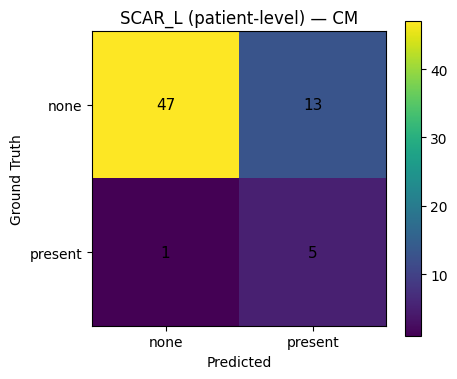

✅ Saved: D:\base\results\cm_scar_right_patient.png


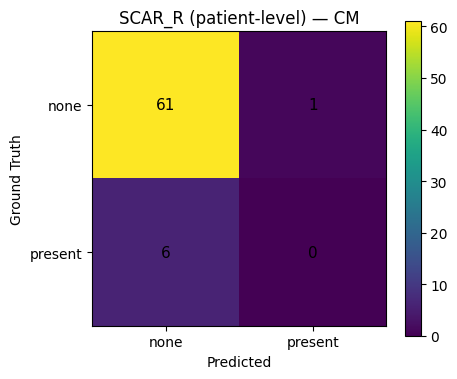

In [62]:
# CELL 49 — Visualize SCAR confusion matrices (ANY / Left / Right) + save PNGs to D:\base\results

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")
OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def plot_cm(cm, title, class_names=("none", "present"), save_path=None):
    if cm is None:
        print(f"⚠️ {title}: cm is None (nothing to plot).")
        return

    cm = np.asarray(cm, dtype=int)

    plt.figure(figsize=(4.8, 4.0))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names)
    plt.yticks(ticks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")

    # annotate counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=11)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("✅ Saved:", save_path)

    plt.show()

# Expect these from CELL 42:
# cm_any, cm_L, cm_R
plot_cm(cm_any, "SCAR_ANY (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_any_patient.png")
plot_cm(cm_L,   "SCAR_L (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_left_patient.png")
plot_cm(cm_R,   "SCAR_R (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_right_patient.png")


In [63]:
# CELL 50 — Sweep thrR (RIGHT) while keeping thrL fixed, optimize VAL F1_any, then evaluate on TEST
# Uses: val_pat_df, test_pat_df already created
# Assumes you want to keep LEFT threshold fixed at 0.51 (from best-left F1)

import numpy as np

thrL_fixed = 0.51
thrR_grid = np.linspace(0.30, 0.95, 66)  # step ~0.01

def f1_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn

def eval_any(pat_df, thrL, thrR):
    any_gt, any_pr = [], []
    for _, row in pat_df.iterrows():
        gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
        vL = (gtL >= 0); vR = (gtR >= 0)
        if not (vL or vR):
            continue

        gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
        pr_any = int((row["scarL_prob"] >= thrL) if vL else 0) or int((row["scarR_prob"] >= thrR) if vR else 0)

        any_gt.append(int(gt_any))
        any_pr.append(int(pr_any))

    f1, pr, rc, tp, fp, fn = f1_binary(any_gt, any_pr)
    return {
        "F1_any": float(f1), "P_any": float(pr), "R_any": float(rc),
        "TP": tp, "FP": fp, "FN": fn, "TN": int(len(any_gt) - tp - fp - fn),
        "n": int(len(any_gt))
    }

def cm2_from_counts(TN, FP, FN, TP):
    return np.array([[TN, FP],[FN, TP]], dtype=int)

# --- sweep on VAL ---
best = None
for thrR in thrR_grid:
    res = eval_any(val_pat_df, thrL_fixed, float(thrR))
    row = {"thrL": thrL_fixed, "thrR": float(thrR), **res}
    # maximize F1, tie-breaker: higher precision
    if (best is None) or (row["F1_any"] > best["F1_any"]) or (row["F1_any"] == best["F1_any"] and row["P_any"] > best["P_any"]):
        best = row

print("✅ Best on VAL (thrL fixed):")
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in best.items()})
print("VAL CM_ANY:\n", cm2_from_counts(best["TN"], best["FP"], best["FN"], best["TP"]))

# --- apply on TEST ---
test_res = eval_any(test_pat_df, best["thrL"], best["thrR"])
print("\nTEST @ chosen thresholds:")
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in {"thrL": best["thrL"], "thrR": best["thrR"], **test_res}.items()})
print("TEST CM_ANY:\n", cm2_from_counts(test_res["TN"], test_res["FP"], test_res["FN"], test_res["TP"]))


✅ Best on VAL (thrL fixed):
{'thrL': 0.51, 'thrR': 0.83, 'F1_any': 0.25, 'P_any': 0.2, 'R_any': 0.3333, 'TP': 2, 'FP': 8, 'FN': 4, 'TN': 62, 'n': 76}
VAL CM_ANY:
 [[62  8]
 [ 4  2]]

TEST @ chosen thresholds:
{'thrL': 0.51, 'thrR': 0.83, 'F1_any': 0.3478, 'P_any': 0.2667, 'R_any': 0.5, 'TP': 4, 'FP': 11, 'FN': 4, 'TN': 57, 'n': 76}
TEST CM_ANY:
 [[57 11]
 [ 4  4]]
